In [131]:
import os
import sys
os.chdir('D:/CEOS') 
sys.path.append(os.path.abspath('D:/CEOS/Modules'))
[sys.path.append(x[0]) for x in os.walk('.')]
import pickle
import pandas as pd
import toolsv5 as tools
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import datetime 
import statsmodels.api as sm
from scipy import stats
import Algos


In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import warnings
warnings.filterwarnings('ignore')

In [4]:
pd.set_option('display.max_rows', None)

# Stage 3 Validation 

3.1 Strict HLS 30 1d same site only 

In [73]:

df = pd.read_pickle('D:/CEOS/InputData/groundedeohls/df_groundedeohls_30m_SL2P_HLS_FRM_1d_LAI.pkl')
df['NLCD_group'] = df['NLCD'].map({'evergreenForest': 'needleleafForest',
                           'deciduousForest': 'broadleafForest',
                           'mixedForest': 'broadleafForest',
                           'woodyWetlands': 'broadleafForest',
                           'grasslandHerbaceous': 'nonForest',
                           'emergentHerbaceousWetlands': 'nonForest',
                           'dwarfScrub': 'nonForest',
                           'sedgeHerbaceous': 'nonForest',

                           'shrubScrub': 'nonForest',
                           'pastureHay': 'nonForest',
                           'cultivatedCrops': 'nonForest'})
variable = 'LAI'

#remove parameters with NA values 
df_FRM = df.dropna(subset=[variable+'_FRM','clumping_index','WAI_up_FRM','FROST','GDD','aridity','medianestimate'+variable+'_ci','medianestimate'+variable])

params = {'df_FRM':df_FRM[df_FRM['Uniformity']<3],
                        'r':'medianresidual'+variable,
                        'r_ci':variable+'_ci',
                        'x':[variable+'_FRM','clumping_index','WAI_up_FRM','FROST','GDD','aridity','medianestimate'+variable+'_ci','medianestimate'+variable],         
                        'x_ci':[variable+'_ci','clumping_index_ci','WAI_up_ci','FROST_ci','GDD_ci','aridity_ci','medianestimate'+variable+'_ci_ci','medianestimate'+variable+'_ci'],
                        'x_ci_minimum':np.array([0.1,0.1,0.1,(df['FROST'].max()-df['FROST'].min())/2,(df['GDD'].max()-df['GDD'].min())/2,(df['aridity'].max()-df['aridity'].min())/2,0.05,0.1]),
                        'w':np.array([1 ,1 ,1 ,1,1,1,1,1]),
                        'inc':[['NLCD_group','Site']],
                        'exc':None,
                         'removeUFRMflag':False}
HLS_SiteUni_LAI = tools.calval(df=df_FRM,  variable=variable ,params=params)
HLS_SiteUni_LAI['name'] = 'HLS-SiteUni'




In [104]:

df = pd.read_pickle('D:/CEOS/InputData/groundedeohls/df_groundedeohls_60m_SL2P_HLS_FRM_7d_LAI.pkl')
df['NLCD_group'] = df['NLCD'].map({'evergreenForest': 'needleleafForest',
                           'deciduousForest': 'broadleafForest',
                           'mixedForest': 'broadleafForest',
                           'woodyWetlands': 'broadleafForest',
                           'grasslandHerbaceous': 'nonForest',
                           'emergentHerbaceousWetlands': 'nonForest',
                           'dwarfScrub': 'nonForest',
                           'sedgeHerbaceous': 'nonForest',

                           'shrubScrub': 'nonForest',
                           'pastureHay': 'nonForest',
                           'cultivatedCrops': 'nonForest'})
variable = 'LAI'

#remove parameters with NA values 
df_FRM = df.dropna(subset=[variable+'_FRM','clumping_index','WAI_up_FRM','FROST','GDD','aridity','medianestimate'+variable+'_ci','medianestimate'+variable])

params = {'df_FRM':df_FRM[df_FRM['Uniformity']<3],
                        'r':'medianresidual'+variable,
                        'r_ci':variable+'_ci',
                        'x':[variable+'_FRM','clumping_index','WAI_up_FRM','FROST','GDD','aridity','medianestimate'+variable+'_ci','medianestimate'+variable],         
                        'x_ci':[variable+'_ci','clumping_index_ci','WAI_up_ci','FROST_ci','GDD_ci','aridity_ci','medianestimate'+variable+'_ci_ci','medianestimate'+variable+'_ci'],
                        'x_ci_minimum':np.array([0.1,0.1,0.1,(df['FROST'].max()-df['FROST'].min())/2,(df['GDD'].max()-df['GDD'].min())/2,(df['aridity'].max()-df['aridity'].min())/2,0.05,0.1]),
                        'w':np.array([1 ,1 ,1 ,1,1,1,1,1]),
                        'inc':[['NLCD_group','Site']],
                        'exc':None,
                         'removeUFRMflag':False}
HLS_SiteUniWide_LAI = tools.calval(df=df_FRM,  variable=variable ,params=params)
HLS_SiteUniWide_LAI['name'] = 'HLS-SiteUniWide'


In [34]:

df = pd.read_pickle('D:/CEOS/InputData/groundedeohls/df_groundedeohls_30m_SL2P_HLS_FRM_1d_LAI.pkl')
df['NLCD_group'] = df['NLCD'].map({'evergreenForest': 'needleleafForest',
                           'deciduousForest': 'broadleafForest',
                           'mixedForest': 'broadleafForest',
                           'woodyWetlands': 'broadleafForest',
                           'grasslandHerbaceous': 'nonForest',
                           'emergentHerbaceousWetlands': 'nonForest',
                           'dwarfScrub': 'nonForest',
                           'sedgeHerbaceous': 'nonForest',

                           'shrubScrub': 'nonForest',
                           'pastureHay': 'nonForest',
                           'cultivatedCrops': 'nonForest'})
variable = 'LAI'

#remove parameters with NA values 
df_FRM = df.dropna(subset=[variable+'_FRM','clumping_index','WAI_up_FRM','FROST','GDD','aridity','medianestimate'+variable+'_ci','medianestimate'+variable])

params = {'df_FRM':df_FRM[df_FRM['Uniformity']<4],
                        'r':'medianresidual'+variable,
                        'r_ci':variable+'_ci',
                        'x':[variable+'_FRM','clumping_index','WAI_up_FRM','FROST','GDD','aridity','medianestimate'+variable+'_ci','medianestimate'+variable],         
                        'x_ci':[variable+'_ci','clumping_index_ci','WAI_up_ci','FROST_ci','GDD_ci','aridity_ci','medianestimate'+variable+'_ci_ci','medianestimate'+variable+'_ci'],
                        'x_ci_minimum':np.array([0.1,0.1,0.1,(df['FROST'].max()-df['FROST'].min())/2,(df['GDD'].max()-df['GDD'].min())/2,(df['aridity'].max()-df['aridity'].min())/2,0.05,0.1]),
                        'w':np.array([1 ,1 ,1 ,1,1,1,1,1]),
                        'inc':[['NLCD_group','Site']],
                        'exc':None,
                         'removeUFRMflag':False}

HLS_SiteAll_LAI = tools.calval(df=df_FRM,  variable=variable ,params=params)
HLS_SiteAll_LAI['name'] = 'HLS-SiteAll'



In [178]:

df = pd.read_pickle('D:/CEOS/InputData/groundedeohls/df_groundedeohls_60m_SL2P_HLS_FRM_7d_LAI.pkl')
df['NLCD_group'] = df['NLCD'].map({'evergreenForest': 'needleleafForest',
                           'deciduousForest': 'broadleafForest',
                           'mixedForest': 'broadleafForest',
                           'woodyWetlands': 'broadleafForest',
                           'grasslandHerbaceous': 'nonForest',
                           'emergentHerbaceousWetlands': 'nonForest',
                           'dwarfScrub': 'nonForest',
                           'sedgeHerbaceous': 'nonForest',

                           'shrubScrub': 'nonForest',
                           'pastureHay': 'nonForest',
                           'cultivatedCrops': 'nonForest'})
variable = 'LAI'

#remove parameters with NA values 
df_FRM = df.dropna(subset=[variable+'_FRM','clumping_index','WAI_up_FRM','FROST','GDD','aridity','medianestimate'+variable+'_ci','medianestimate'+variable])

params = {'df_FRM':df_FRM[df_FRM['Uniformity']<4],
                        'r':'medianresidual'+variable,
                        'r_ci':variable+'_ci',
                        'x':[variable+'_FRM','clumping_index','WAI_up_FRM','FROST','GDD','aridity','medianestimate'+variable+'_ci','medianestimate'+variable],         
                        'x_ci':[variable+'_ci','clumping_index_ci','WAI_up_ci','FROST_ci','GDD_ci','aridity_ci','medianestimate'+variable+'_ci_ci','medianestimate'+variable+'_ci'],
                        'x_ci_minimum':np.array([0.1,0.1,0.1,(df['FROST'].max()-df['FROST'].min())/2,(df['GDD'].max()-df['GDD'].min())/2,(df['aridity'].max()-df['aridity'].min())/2,0.05,0.1]),
                        'w':np.array([1 ,1 ,1 ,1,1,1,1,1]),
                        'inc':[['NLCD_group','Site']],
                        'exc':None,
                         'removeUFRMflag':False}

HLS_SiteAllWide_LAI = tools.calval(df=df_FRM,  variable=variable ,params=params)
HLS_SiteAllWide_LAI['name'] = 'HLS-SiteAllWide'

In [ ]:

df = pd.read_pickle('D:/CEOS/InputData/groundedeohls/df_groundedeohls_60m_SL2P_S2_FRM_7d_LAI.pkl')
df['NLCD_group'] = df['NLCD'].map({'evergreenForest': 'needleleafForest',
                           'deciduousForest': 'broadleafForest',
                           'mixedForest': 'broadleafForest',
                           'woodyWetlands': 'broadleafForest',
                           'grasslandHerbaceous': 'nonForest',
                           'emergentHerbaceousWetlands': 'nonForest',
                           'dwarfScrub': 'nonForest',
                           'sedgeHerbaceous': 'nonForest',

                           'shrubScrub': 'nonForest',
                           'pastureHay': 'nonForest',
                           'cultivatedCrops': 'nonForest'})
variable = 'LAI'

#remove parameters with NA values 
df_FRM = df.dropna(subset=[variable+'_FRM','clumping_index','WAI_up_FRM','FROST','GDD','aridity','medianestimate'+variable+'_ci','medianestimate'+variable])

params = {'df_FRM':df_FRM[df_FRM['Uniformity']<4],
                        'r':'medianresidual'+variable,
                        'r_ci':variable+'_ci',
                        'x':[variable+'_FRM','clumping_index','WAI_up_FRM','FROST','GDD','aridity','medianestimate'+variable+'_ci','medianestimate'+variable],         
                        'x_ci':[variable+'_ci','clumping_index_ci','WAI_up_ci','FROST_ci','GDD_ci','aridity_ci','medianestimate'+variable+'_ci_ci','medianestimate'+variable+'_ci'],
                        'x_ci_minimum':np.array([0.1,0.1,0.1,(df['FROST'].max()-df['FROST'].min())/2,(df['GDD'].max()-df['GDD'].min())/2,(df['aridity'].max()-df['aridity'].min())/2,0.05,0.1]),
                        'w':np.array([1 ,1 ,1 ,1,1,1,1,1]),
                        'inc':[['NLCD_group','Site']],
                        'exc':None,
                         'removeUFRMflag':False}

S2_SiteAllWide_LAI = tools.calval(df=df_FRM,  variable=variable ,params=params)
S2_SiteAllWide_LAI['name'] = 'S2-SiteAllWide'

In [185]:

df = pd.read_pickle('D:/CEOS/InputData/groundedeohls/df_groundedeohls_30m_SL2P_HLS_FRM_1d_LAI.pkl')
df['NLCD_group'] = df['NLCD'].map({'evergreenForest': 'needleleafForest',
                           'deciduousForest': 'broadleafForest',
                           'mixedForest': 'broadleafForest',
                           'woodyWetlands': 'broadleafForest',
                           'grasslandHerbaceous': 'nonForest',
                           'emergentHerbaceousWetlands': 'nonForest',
                           'dwarfScrub': 'nonForest',
                           'sedgeHerbaceous': 'nonForest',

                           'shrubScrub': 'nonForest',
                           'pastureHay': 'nonForest',
                           'cultivatedCrops': 'nonForest'})
variable = 'LAI'

#remove parameters with NA values 
df_FRM = df.dropna(subset=[variable+'_FRM','clumping_index','WAI_up_FRM','FROST','GDD','aridity','medianestimate'+variable+'_ci','medianestimate'+variable])

params = {'df_FRM':df_FRM[df_FRM['Uniformity']<4],
                        'r':'medianresidual'+variable,
                        'r_ci':variable+'_ci',
                        'x':[variable+'_FRM','clumping_index','WAI_up_FRM','FROST','GDD','aridity','medianestimate'+variable+'_ci','medianestimate'+variable],         
                        'x_ci':[variable+'_ci','clumping_index_ci','WAI_up_ci','FROST_ci','GDD_ci','aridity_ci','medianestimate'+variable+'_ci_ci','medianestimate'+variable+'_ci'],
                        'x_ci_minimum':np.array([0.1,0.1,0.1,(df['FROST'].max()-df['FROST'].min())/2,(df['GDD'].max()-df['GDD'].min())/2,(df['aridity'].max()-df['aridity'].min())/2,0.05,0.1]),
                        'w':np.array([1 ,1 ,1 ,1,1,1,1,1]),
                        'inc':[['NLCD_group']],
                        'exc':None,
                         'removeUFRMflag':False}

HLS_All_LAI = tools.calval(df=df_FRM,  variable=variable ,params=params)
HLS_All_LAI['name'] = 'HLS-AllWide'


In [186]:

df = pd.read_pickle('D:/CEOS/InputData/groundedeohls/df_groundedeohlss30_60m_SL2P_S2_FRM_7d_LAI.pkl')
df['NLCD_group'] = df['NLCD'].map({'evergreenForest': 'needleleafForest',
                           'deciduousForest': 'broadleafForest',
                           'mixedForest': 'broadleafForest',
                           'woodyWetlands': 'broadleafForest',
                           'grasslandHerbaceous': 'nonForest',
                           'emergentHerbaceousWetlands': 'nonForest',
                           'dwarfScrub': 'nonForest',
                           'sedgeHerbaceous': 'nonForest',

                           'shrubScrub': 'nonForest',
                           'pastureHay': 'nonForest',
                           'cultivatedCrops': 'nonForest'})
variable = 'LAI'

#remove parameters with NA values 
df_FRM = df.dropna(subset=[variable+'_FRM','clumping_index','WAI_up_FRM','FROST','GDD','aridity','medianestimate'+variable+'_ci','medianestimate'+variable])

params = {'df_FRM':df_FRM[df_FRM['Uniformity']<4],
                        'r':'medianresidual'+variable,
                        'r_ci':variable+'_ci',
                        'x':[variable+'_FRM','clumping_index','WAI_up_FRM','FROST','GDD','aridity','medianestimate'+variable+'_ci','medianestimate'+variable],         
                        'x_ci':[variable+'_ci','clumping_index_ci','WAI_up_ci','FROST_ci','GDD_ci','aridity_ci','medianestimate'+variable+'_ci_ci','medianestimate'+variable+'_ci'],
                        'x_ci_minimum':np.array([0.1,0.1,0.1,(df['FROST'].max()-df['FROST'].min())/2,(df['GDD'].max()-df['GDD'].min())/2,(df['aridity'].max()-df['aridity'].min())/2,0.05,0.1]),
                        'w':np.array([1 ,1 ,1 ,1,1,1,1,1]),
                        'inc':[['NLCD_group']],
                        'exc':None,
                         'removeUFRMflag':False}

S2_AllWide_LAI = tools.calval(df=df_FRM, variable=variable ,params=params)
S2_AllWide_LAI['name'] = 'S2-AllWide'



In [190]:

df = pd.read_pickle('D:/CEOS/InputData/groundedeohls/df_groundedeohls_60m_SL2P_HLS_FRM_7d_LAI.pkl')
df['NLCD_group'] = df['NLCD'].map({'evergreenForest': 'needleleafForest',
                           'deciduousForest': 'broadleafForest',
                           'mixedForest': 'broadleafForest',
                           'woodyWetlands': 'broadleafForest',
                           'grasslandHerbaceous': 'nonForest',
                           'emergentHerbaceousWetlands': 'nonForest',
                           'dwarfScrub': 'nonForest',
                           'sedgeHerbaceous': 'nonForest',

                           'shrubScrub': 'nonForest',
                           'pastureHay': 'nonForest',
                           'cultivatedCrops': 'nonForest'})
variable = 'LAI'

#remove parameters with NA values 
df_FRM = df.dropna(subset=[variable+'_FRM','clumping_index','WAI_up_FRM','FROST','GDD','aridity','medianestimate'+variable+'_ci','medianestimate'+variable])

params = {'df_FRM':df_FRM[df_FRM['Uniformity']<4],
                        'r':'medianresidual'+variable,
                        'r_ci':variable+'_ci',
                        'x':[variable+'_FRM','clumping_index','WAI_up_FRM','FROST','GDD','aridity','medianestimate'+variable+'_ci','medianestimate'+variable],         
                        'x_ci':[variable+'_ci','clumping_index_ci','WAI_up_ci','FROST_ci','GDD_ci','aridity_ci','medianestimate'+variable+'_ci_ci','medianestimate'+variable+'_ci'],
                        'x_ci_minimum':np.array([0.1,0.1,0.1,(df['FROST'].max()-df['FROST'].min())/2,(df['GDD'].max()-df['GDD'].min())/2,(df['aridity'].max()-df['aridity'].min())/2,0.05,0.1]),
                        'w':np.array([1 ,1 ,1 ,0.01,0.01,0.01,1,1]),
                        'inc':[['NLCD_group']],
                        'exc':None,
                         'removeUFRMflag':False}

HLS_AllWideNoClim_LAI = tools.calval(df=df_FRM,  variable=variable ,params=params)
HLS_AllWideNoClim_LAI['name'] = 'HLS-AllWideNoClim'


In [ ]:
df1 = pd.read_pickle('D:/CEOS/InputData/groundedeohls/df_groundedeohls_60m_SL2P_HLS_FRM_7d_LAI.pkl')
df2= pd.read_pickle('D:/CEOS/InputData/groundedeohls/df_groundedeohls_60m_SL2P_HLS_FRM_7d_FAPAR.pkl')
# 1. Define your merge key(s)
merge_on = ['Plot','Date']

# 2. Find columns in df_right that are NOT in df_left (plus the merge key)
cols_to_use = merge_on + list(df2.columns.difference(df1.columns))
df = pd.merge(df1,df2[cols_to_use],on=merge_on,how='left')
df['FAPARLAI_ratio'] = df['medianestimateFAPAR']/df['medianestimateLAI']
df['FAPARLAI_ratio_ci']=df['FAPARLAI_ratio']*np.sqrt(np.power(df['medianestimateFAPAR_ci']/df['medianestimateFAPAR'],2)+np.power(df['medianestimateLAI_ci']/df['medianestimateLAI'],2))
df['NLCD_group'] = df['NLCD'].map({'evergreenForest': 'needleleafForest',
                           'deciduousForest': 'broadleafForest',
                           'mixedForest': 'broadleafForest',
                           'woodyWetlands': 'broadleafForest',
                           'grasslandHerbaceous': 'nonForest',
                           'emergentHerbaceousWetlands': 'nonForest',
                           'dwarfScrub': 'nonForest',
                           'sedgeHerbaceous': 'nonForest',

                           'shrubScrub': 'nonForest',
                           'pastureHay': 'nonForest',
                           'cultivatedCrops': 'nonForest'})

variable = 'LAI'

#remove parameters with NA values 
df_FRM = df.dropna(subset=[variable+'_FRM','clumping_index','WAI_up_FRM','FROST','GDD','aridity','medianestimate'+variable+'_ci','medianestimate'+variable])

params = {'df_FRM':df_FRM[df_FRM['Uniformity']<4],
                        'r':'medianresidual'+variable,
                        'r_ci':variable+'_ci',
                        'x':['FAPARLAI_ratio','FROST','GDD','aridity','medianestimate'+variable+'_ci','medianestimate'+variable],         
                        'x_ci':['FAPARLAI_ratio_ci','FROST_ci','GDD_ci','aridity_ci','medianestimate'+variable+'_ci_ci','medianestimate'+variable+'_ci'],
                        'x_ci_minimum':np.array([0.1,(df['FROST'].max()-df['FROST'].min())/2,(df['GDD'].max()-df['GDD'].min())/2,(df['aridity'].max()-df['aridity'].min())/2,0.05,0.1]),
                        'w':np.array([1 ,1,1,1,1,1]),
                        'inc':[['NLCD_group']],
                         'exc':[['Site']],
                         'removeUFRMflag':False}

HLS_Stage4Wide_LAI = tools.calval(df=df_FRM,  variable=variable ,params=params)
HLS_Stage4Wide_LAI['name'] = 'HLS-Stage4Wide'



In [194]:
# with open('D:/CEOS/InputData/groundedeohls/HLS_SiteUni_LAI.pkl', 'wb') as file:
#     pickle.dump(HLS_SiteUni_LAI, file)

# with open('D:/CEOS/InputData/groundedeohls/HLS_SiteUniWide_LAI.pkl', 'wb') as file:
#     pickle.dump(HLS_SiteUniWide_LAI, file)

# with open('D:/CEOS/InputData/groundedeohls/HLS_SiteAll_LAI.pkl', 'wb') as file:
#     pickle.dump(HLS_SiteAll_LAI, file)

# with open('D:/CEOS/InputData/groundedeohls/HLS_SiteAllWide_LAI.pkl', 'wb') as file:
#     pickle.dump(HLS_SiteAllWide_LAI, file)

with open('D:/CEOS/InputData/groundedeohls/S2_SiteAllWide_LAI.pkl', 'wb') as file:
    pickle.dump(S2_SiteAllWide_LAI, file)
    
# with open('D:/CEOS/InputData/groundedeohls/HLS_All_LAI.pkl', 'wb') as file:
#     pickle.dump(HLS_All_LAI, file)

# with open('D:/CEOS/InputData/groundedeohls/HLS_AllWide_LAI.pkl', 'wb') as file:
#     pickle.dump(HLS_AllWide_LAI, file)


with open('D:/CEOS/InputData/groundedeohls/HLS_AllWideNoClim_LAI.pkl', 'wb') as file:
    pickle.dump(HLS_AllWideNoClim_LAI, file)
    
# with open('D:/CEOS/InputData/groundedeohls/S2_AllWide_LAI.pkl', 'wb') as file:
#     pickle.dump(S2_AllWide_LAI, file)
    
with open('D:/CEOS/InputData/groundedeohls/HLS_Stage4Wide_LAI.pkl', 'wb') as file:
    pickle.dump(HLS_Stage4Wide_LAI, file)

In [81]:

df = pd.read_pickle('D:/CEOS/InputData/groundedeohls/df_groundedeohls_30m_SL2P_HLS_FRM_1d_FAPAR.pkl')
df['NLCD_group'] = df['NLCD'].map({'evergreenForest': 'needleleafForest',
                           'deciduousForest': 'broadleafForest',
                           'mixedForest': 'broadleafForest',
                           'woodyWetlands': 'broadleafForest',
                           'grasslandHerbaceous': 'nonForest',
                           'emergentHerbaceousWetlands': 'nonForest',
                           'dwarfScrub': 'nonForest',
                           'sedgeHerbaceous': 'nonForest',

                           'shrubScrub': 'nonForest',
                           'pastureHay': 'nonForest',
                           'cultivatedCrops': 'nonForest'})
variable = 'FAPAR'

#remove parameters with NA values 
df_FRM = df.dropna(subset=[variable+'_FRM','clumping_index','WAI_up_FRM','FROST','GDD','aridity','medianestimate'+variable+'_ci','medianestimate'+variable])

params = {'df_FRM':df_FRM[df_FRM['Uniformity']<3],
                        'r':'medianresidual'+variable,
                        'r_ci':variable+'_ci',
                        'x':[variable+'_FRM','clumping_index','WAI_up_FRM','FROST','GDD','aridity','medianestimate'+variable+'_ci','medianestimate'+variable],         
                        'x_ci':[variable+'_ci','clumping_index_ci','WAI_up_ci','FROST_ci','GDD_ci','aridity_ci','medianestimate'+variable+'_ci_ci','medianestimate'+variable+'_ci'],
                        'x_ci_minimum':np.array([0.1,0.1,0.1,(df['FROST'].max()-df['FROST'].min())/2,(df['GDD'].max()-df['GDD'].min())/2,(df['aridity'].max()-df['aridity'].min())/2,0.05,0.1]),
                        'w':np.array([1 ,1 ,1 ,1,1,1,1,1]),
                        'inc':[['NLCD_group','Site']],
                        'exc':None,
                         'removeUFRMflag':False}

HLS_SiteUni_FAPAR = tools.calval(df=df_FRM,  variable=variable ,params=params)
HLS_SiteUni_FAPAR['name'] = 'HLS-SiteUni'




In [106]:

df = pd.read_pickle('D:/CEOS/InputData/groundedeohls/df_groundedeohls_60m_SL2P_HLS_FRM_7d_FAPAR.pkl')
df['NLCD_group'] = df['NLCD'].map({'evergreenForest': 'needleleafForest',
                           'deciduousForest': 'broadleafForest',
                           'mixedForest': 'broadleafForest',
                           'woodyWetlands': 'broadleafForest',
                           'grasslandHerbaceous': 'nonForest',
                           'emergentHerbaceousWetlands': 'nonForest',
                           'dwarfScrub': 'nonForest',
                           'sedgeHerbaceous': 'nonForest',

                           'shrubScrub': 'nonForest',
                           'pastureHay': 'nonForest',
                           'cultivatedCrops': 'nonForest'})
variable = 'FAPAR'

#remove parameters with NA values 
df_FRM = df.dropna(subset=[variable+'_FRM','clumping_index','WAI_up_FRM','FROST','GDD','aridity','medianestimate'+variable+'_ci','medianestimate'+variable])

params = {'df_FRM':df_FRM[df_FRM['Uniformity']<3],
                        'r':'medianresidual'+variable,
                        'r_ci':variable+'_ci',
                        'x':[variable+'_FRM','clumping_index','WAI_up_FRM','FROST','GDD','aridity','medianestimate'+variable+'_ci','medianestimate'+variable],         
                        'x_ci':[variable+'_ci','clumping_index_ci','WAI_up_ci','FROST_ci','GDD_ci','aridity_ci','medianestimate'+variable+'_ci_ci','medianestimate'+variable+'_ci'],
                        'x_ci_minimum':np.array([0.1,0.1,0.1,(df['FROST'].max()-df['FROST'].min())/2,(df['GDD'].max()-df['GDD'].min())/2,(df['aridity'].max()-df['aridity'].min())/2,0.05,0.1]),
                        'w':np.array([1 ,1 ,1 ,1,1,1,1,1]),
                        'inc':[['NLCD_group','Site']],
                        'exc':None,
                         'removeUFRMflag':False}

HLS_SiteUniWide_FAPAR = tools.calval(df=df_FRM,  variable=variable ,params=params)
HLS_SiteUniWide_FAPAR['name'] = 'HLS-SiteUniWide'



In [82]:

df = pd.read_pickle('D:/CEOS/InputData/groundedeohls/df_groundedeohls_30m_SL2P_HLS_FRM_1d_FAPAR.pkl')
df['NLCD_group'] = df['NLCD'].map({'evergreenForest': 'needleleafForest',
                           'deciduousForest': 'broadleafForest',
                           'mixedForest': 'broadleafForest',
                           'woodyWetlands': 'broadleafForest',
                           'grasslandHerbaceous': 'nonForest',
                           'emergentHerbaceousWetlands': 'nonForest',
                           'dwarfScrub': 'nonForest',
                           'sedgeHerbaceous': 'nonForest',

                           'shrubScrub': 'nonForest',
                           'pastureHay': 'nonForest',
                           'cultivatedCrops': 'nonForest'})
variable = 'FAPAR'

#remove parameters with NA values 
df_FRM = df.dropna(subset=[variable+'_FRM','clumping_index','WAI_up_FRM','FROST','GDD','aridity','medianestimate'+variable+'_ci','medianestimate'+variable])

params = {'df_FRM':df_FRM[df_FRM['Uniformity']<4],
                        'r':'medianresidual'+variable,
                        'r_ci':variable+'_ci',
                        'x':[variable+'_FRM','clumping_index','WAI_up_FRM','FROST','GDD','aridity','medianestimate'+variable+'_ci','medianestimate'+variable],         
                        'x_ci':[variable+'_ci','clumping_index_ci','WAI_up_ci','FROST_ci','GDD_ci','aridity_ci','medianestimate'+variable+'_ci_ci','medianestimate'+variable+'_ci'],
                        'x_ci_minimum':np.array([0.1,0.1,0.1,(df['FROST'].max()-df['FROST'].min())/2,(df['GDD'].max()-df['GDD'].min())/2,(df['aridity'].max()-df['aridity'].min())/2,0.05,0.1]),
                        'w':np.array([1 ,1 ,1 ,1,1,1,1,1]),
                        'inc':[['NLCD_group','Site']],
                        'exc':None,
                         'removeUFRMflag':False}

HLS_SiteAll_FAPAR = tools.calval(df=df_FRM,  variable=variable ,params=params)
HLS_SiteAll_FAPAR['name'] = 'HLS-SiteAll'



In [181]:

df = pd.read_pickle('D:/CEOS/InputData/groundedeohls/df_groundedeohls_60m_SL2P_HLS_FRM_7d_FAPAR.pkl')
df['NLCD_group'] = df['NLCD'].map({'evergreenForest': 'needleleafForest',
                           'deciduousForest': 'broadleafForest',
                           'mixedForest': 'broadleafForest',
                           'woodyWetlands': 'broadleafForest',
                           'grasslandHerbaceous': 'nonForest',
                           'emergentHerbaceousWetlands': 'nonForest',
                           'dwarfScrub': 'nonForest',
                           'sedgeHerbaceous': 'nonForest',

                           'shrubScrub': 'nonForest',
                           'pastureHay': 'nonForest',
                           'cultivatedCrops': 'nonForest'})
variable = 'FAPAR'

#remove parameters with NA values 
df_FRM = df.dropna(subset=[variable+'_FRM','clumping_index','WAI_up_FRM','FROST','GDD','aridity','medianestimate'+variable+'_ci','medianestimate'+variable])

params = {'df_FRM':df_FRM[df_FRM['Uniformity']<4],
                        'r':'medianresidual'+variable,
                        'r_ci':variable+'_ci',
                        'x':[variable+'_FRM','clumping_index','WAI_up_FRM','FROST','GDD','aridity','medianestimate'+variable+'_ci','medianestimate'+variable],         
                        'x_ci':[variable+'_ci','clumping_index_ci','WAI_up_ci','FROST_ci','GDD_ci','aridity_ci','medianestimate'+variable+'_ci_ci','medianestimate'+variable+'_ci'],
                        'x_ci_minimum':np.array([0.1,0.1,0.1,(df['FROST'].max()-df['FROST'].min())/2,(df['GDD'].max()-df['GDD'].min())/2,(df['aridity'].max()-df['aridity'].min())/2,0.05,0.1]),
                        'w':np.array([1 ,1 ,1 ,1,1,1,1,1]),
                        'inc':[['NLCD_group','Site']],
                        'exc':None,
                         'removeUFRMflag':False}

HLS_SiteAllWide_FAPAR = tools.calval(df=df_FRM,  variable=variable ,params=params)
HLS_SiteAllWide_FAPAR['name'] = 'HLS-SiteAllWide'


In [ ]:
df = pd.read_pickle('D:/CEOS/InputData/groundedeohls/df_groundedeohls_60m_SL2P_S2_FRM_7d_FAPAR.pkl')
df['NLCD_group'] = df['NLCD'].map({'evergreenForest': 'needleleafForest',
                           'deciduousForest': 'broadleafForest',
                           'mixedForest': 'broadleafForest',
                           'woodyWetlands': 'broadleafForest',
                           'grasslandHerbaceous': 'nonForest',
                           'emergentHerbaceousWetlands': 'nonForest',
                           'dwarfScrub': 'nonForest',
                           'sedgeHerbaceous': 'nonForest',

                           'shrubScrub': 'nonForest',
                           'pastureHay': 'nonForest',
                           'cultivatedCrops': 'nonForest'})
variable = 'FAPAR'

#remove parameters with NA values 
df_FRM = df.dropna(subset=[variable+'_FRM','clumping_index','WAI_up_FRM','FROST','GDD','aridity','medianestimate'+variable+'_ci','medianestimate'+variable])

params = {'df_FRM':df_FRM[df_FRM['Uniformity']<4],
                        'r':'medianresidual'+variable,
                        'r_ci':variable+'_ci',
                        'x':[variable+'_FRM','clumping_index','WAI_up_FRM','FROST','GDD','aridity','medianestimate'+variable+'_ci','medianestimate'+variable],         
                        'x_ci':[variable+'_ci','clumping_index_ci','WAI_up_ci','FROST_ci','GDD_ci','aridity_ci','medianestimate'+variable+'_ci_ci','medianestimate'+variable+'_ci'],
                        'x_ci_minimum':np.array([0.1,0.1,0.1,(df['FROST'].max()-df['FROST'].min())/2,(df['GDD'].max()-df['GDD'].min())/2,(df['aridity'].max()-df['aridity'].min())/2,0.05,0.1]),
                        'w':np.array([1 ,1 ,1 ,1,1,1,1,1]),
                        'inc':[['NLCD_group','Site']],
                        'exc':None,
                         'removeUFRMflag':False}

S2_SiteAllWide_FAPAR = tools.calval(df=df_FRM,  variable=variable ,params=params)
S2_SiteAllWide_FAPAR['name'] = 'S2-SiteAllWide'

In [ ]:

df = pd.read_pickle('D:/CEOS/InputData/groundedeohls/df_groundedeohls_30m_SL2P_HLS_FRM_1d_FAPAR.pkl')
df['NLCD_group'] = df['NLCD'].map({'evergreenForest': 'needleleafForest',
                           'deciduousForest': 'broadleafForest',
                           'mixedForest': 'broadleafForest',
                           'woodyWetlands': 'broadleafForest',
                           'grasslandHerbaceous': 'nonForest',
                           'emergentHerbaceousWetlands': 'nonForest',
                           'dwarfScrub': 'nonForest',
                           'sedgeHerbaceous': 'nonForest',

                           'shrubScrub': 'nonForest',
                           'pastureHay': 'nonForest',
                           'cultivatedCrops': 'nonForest'})
variable = 'FAPAR'

#remove parameters with NA values 
df_FRM = df.dropna(subset=[variable+'_FRM','clumping_index','WAI_up_FRM','FROST','GDD','aridity','medianestimate'+variable+'_ci','medianestimate'+variable])

params = {'df_FRM':df_FRM[df_FRM['Uniformity']<4],
                        'r':'medianresidual'+variable,
                        'r_ci':variable+'_ci',
                        'x':[variable+'_FRM','clumping_index','WAI_up_FRM','FROST','GDD','aridity','medianestimate'+variable+'_ci','medianestimate'+variable],         
                        'x_ci':[variable+'_ci','clumping_index_ci','WAI_up_ci','FROST_ci','GDD_ci','aridity_ci','medianestimate'+variable+'_ci_ci','medianestimate'+variable+'_ci'],
                        'x_ci_minimum':np.array([0.1,0.1,0.1,(df['FROST'].max()-df['FROST'].min())/2,(df['GDD'].max()-df['GDD'].min())/2,(df['aridity'].max()-df['aridity'].min())/2,0.05,0.1]),
                        'w':np.array([1 ,1 ,1 ,1,1,1,1,1]),
                        'inc':[['NLCD_group']],
                        'exc':None,
                         'removeUFRMflag':False}

HLS_All_FAPAR = tools.calval(df=df_FRM,  variable=variable ,params=params)
HLS_All_FAPAR['name'] = 'HLS-All'


In [ ]:

df = pd.read_pickle('D:/CEOS/InputData/groundedeohls/df_groundedeohls_60m_SL2P_HLS_FRM_7d_FAPAR.pkl')
df['NLCD_group'] = df['NLCD'].map({'evergreenForest': 'needleleafForest',
                           'deciduousForest': 'broadleafForest',
                           'mixedForest': 'broadleafForest',
                           'woodyWetlands': 'broadleafForest',
                           'grasslandHerbaceous': 'nonForest',
                           'emergentHerbaceousWetlands': 'nonForest',
                           'dwarfScrub': 'nonForest',
                           'sedgeHerbaceous': 'nonForest',

                           'shrubScrub': 'nonForest',
                           'pastureHay': 'nonForest',
                           'cultivatedCrops': 'nonForest'})
variable = 'FAPAR'

#remove parameters with NA values 
df_FRM = df.dropna(subset=[variable+'_FRM','clumping_index','WAI_up_FRM','FROST','GDD','aridity','medianestimate'+variable+'_ci','medianestimate'+variable])

params = {'df_FRM':df_FRM[df_FRM['Uniformity']<4],
                        'r':'medianresidual'+variable,
                        'r_ci':variable+'_ci',
                        'x':[variable+'_FRM','clumping_index','WAI_up_FRM','FROST','GDD','aridity','medianestimate'+variable+'_ci','medianestimate'+variable],         
                        'x_ci':[variable+'_ci','clumping_index_ci','WAI_up_ci','FROST_ci','GDD_ci','aridity_ci','medianestimate'+variable+'_ci_ci','medianestimate'+variable+'_ci'],
                        'x_ci_minimum':np.array([0.1,0.1,0.1,(df['FROST'].max()-df['FROST'].min())/2,(df['GDD'].max()-df['GDD'].min())/2,(df['aridity'].max()-df['aridity'].min())/2,0.05,0.1]),
                        'w':np.array([1 ,1 ,1 ,1,1,1,1,1]),
                        'inc':[['NLCD_group']],
                        'exc':None,
                         'removeUFRMflag':False}

HLS_AllWide_FAPAR = tools.calval(df=df_FRM,  variable=variable ,params=params)
HLS_AllWide_FAPAR['name'] = 'HLS-AllWide'


In [191]:

df = pd.read_pickle('D:/CEOS/InputData/groundedeohls/df_groundedeohls_60m_SL2P_HLS_FRM_7d_FAPAR.pkl')
df['NLCD_group'] = df['NLCD'].map({'evergreenForest': 'needleleafForest',
                           'deciduousForest': 'broadleafForest',
                           'mixedForest': 'broadleafForest',
                           'woodyWetlands': 'broadleafForest',
                           'grasslandHerbaceous': 'nonForest',
                           'emergentHerbaceousWetlands': 'nonForest',
                           'dwarfScrub': 'nonForest',
                           'sedgeHerbaceous': 'nonForest',

                           'shrubScrub': 'nonForest',
                           'pastureHay': 'nonForest',
                           'cultivatedCrops': 'nonForest'})
variable = 'FAPAR'

#remove parameters with NA values 
df_FRM = df.dropna(subset=[variable+'_FRM','clumping_index','WAI_up_FRM','FROST','GDD','aridity','medianestimate'+variable+'_ci','medianestimate'+variable])

params = {'df_FRM':df_FRM[df_FRM['Uniformity']<4],
                        'r':'medianresidual'+variable,
                        'r_ci':variable+'_ci',
                        'x':[variable+'_FRM','clumping_index','WAI_up_FRM','FROST','GDD','aridity','medianestimate'+variable+'_ci','medianestimate'+variable],         
                        'x_ci':[variable+'_ci','clumping_index_ci','WAI_up_ci','FROST_ci','GDD_ci','aridity_ci','medianestimate'+variable+'_ci_ci','medianestimate'+variable+'_ci'],
                        'x_ci_minimum':np.array([0.1,0.1,0.1,(df['FROST'].max()-df['FROST'].min())/2,(df['GDD'].max()-df['GDD'].min())/2,(df['aridity'].max()-df['aridity'].min())/2,0.05,0.1]),
                        'w':np.array([1 ,1 ,1 ,0.01,0.01,0.01,1,1]),
                        'inc':[['NLCD_group']],
                        'exc':None,
                         'removeUFRMflag':False}

HLS_AllWideNoClim_FAPAR = tools.calval(df=df_FRM,  variable=variable ,params=params)
HLS_AllWideNoClim_FAPAR['name'] = 'HLS-AllWideNoClim'


In [ ]:

df = pd.read_pickle('D:/CEOS/InputData/groundedeohls/df_groundedeohlss30_60m_SL2P_S2_FRM_7d_FAPAR.pkl')
df['NLCD_group'] = df['NLCD'].map({'evergreenForest': 'needleleafForest',
                           'deciduousForest': 'broadleafForest',
                           'mixedForest': 'broadleafForest',
                           'woodyWetlands': 'broadleafForest',
                           'grasslandHerbaceous': 'nonForest',
                           'emergentHerbaceousWetlands': 'nonForest',
                           'dwarfScrub': 'nonForest',
                           'sedgeHerbaceous': 'nonForest',

                           'shrubScrub': 'nonForest',
                           'pastureHay': 'nonForest',
                           'cultivatedCrops': 'nonForest'})
variable = 'FAPAR'

#remove parameters with NA values 
df_FRM = df.dropna(subset=[variable+'_FRM','clumping_index','WAI_up_FRM','FROST','GDD','aridity','medianestimate'+variable+'_ci','medianestimate'+variable])

params = {'df_FRM':df_FRM[df_FRM['Uniformity']<4],
                        'r':'medianresidual'+variable,
                        'r_ci':variable+'_ci',
                        'x':[variable+'_FRM','clumping_index','WAI_up_FRM','FROST','GDD','aridity','medianestimate'+variable+'_ci','medianestimate'+variable],         
                        'x_ci':[variable+'_ci','clumping_index_ci','WAI_up_ci','FROST_ci','GDD_ci','aridity_ci','medianestimate'+variable+'_ci_ci','medianestimate'+variable+'_ci'],
                        'x_ci_minimum':np.array([0.1,(df['FROST'].max()-df['FROST'].min())/2,(df['GDD'].max()-df['GDD'].min())/2,(df['aridity'].max()-df['aridity'].min())/2,0.05,0.1]),
                        'w':np.array([1 ,1 ,1 ,1,1,1,1,1]),
                        'inc':[['NLCD_group']],
                        'exc':None,
                         'removeUFRMflag':False}

S2_AllWide_FAPAR = tools.calval(df=df_FRM,  variable=variable ,params=params)
S2_AllWide_FAPAR['name'] = 'S2-AllWide'


In [ ]:
df1 = pd.read_pickle('D:/CEOS/InputData/groundedeohls/df_groundedeohls_60m_SL2P_HLS_FRM_7d_LAI.pkl')
df2= pd.read_pickle('D:/CEOS/InputData/groundedeohls/df_groundedeohls_60m_SL2P_HLS_FRM_7d_FAPAR.pkl')
# 1. Define your merge key(s)
merge_on = ['Plot','Date']

# 2. Find columns in df_right that are NOT in df_left (plus the merge key)
cols_to_use = merge_on + list(df2.columns.difference(df1.columns))
df = pd.merge(df1,df2[cols_to_use],on=merge_on,how='left')
df['FAPARLAI_ratio'] = df['medianestimateFAPAR']/df['medianestimateLAI']
df['FAPARLAI_ratio_ci']=df['FAPARLAI_ratio']*np.sqrt(np.power(df['medianestimateFAPAR_ci']/df['medianestimateFAPAR'],2)+np.power(df['medianestimateLAI_ci']/df['medianestimateLAI'],2))
df['NLCD_group'] = df['NLCD'].map({'evergreenForest': 'needleleafForest',
                           'deciduousForest': 'broadleafForest',
                           'mixedForest': 'broadleafForest',
                           'woodyWetlands': 'broadleafForest',
                           'grasslandHerbaceous': 'nonForest',
                           'emergentHerbaceousWetlands': 'nonForest',
                           'dwarfScrub': 'nonForest',
                           'sedgeHerbaceous': 'nonForest',

                           'shrubScrub': 'nonForest',
                           'pastureHay': 'nonForest',
                           'cultivatedCrops': 'nonForest'})
variable = 'FAPAR'

#remove parameters with NA values 
df_FRM = df.dropna(subset=[variable+'_FRM','clumping_index','WAI_up_FRM','FROST','GDD','aridity','medianestimate'+variable+'_ci','medianestimate'+variable])


params = {'df_FRM':df_FRM[df_FRM['Uniformity']<4],
                        'r':'medianresidual'+variable,
                        'r_ci':variable+'_ci',
                        'x':['FAPARLAI_ratio','FROST','GDD','aridity','medianestimate'+variable+'_ci','medianestimate'+variable],         
                        'x_ci':['FAPARLAI_ratio_ci','FROST_ci','GDD_ci','aridity_ci','medianestimate'+variable+'_ci_ci','medianestimate'+variable+'_ci'],
                        'x_ci_minimum':np.array([0.1,(df['FROST'].max()-df['FROST'].min())/2,(df['GDD'].max()-df['GDD'].min())/2,(df['aridity'].max()-df['aridity'].min())/2,0.05,0.1]),
                        'w':np.array([1 ,1,1,1,1,1]),
                        'inc':[['NLCD_group']],
                         'exc':[['Site']],
                         'removeUFRMflag':False}

HLS_Stage4Wide_FAPAR = tools.calval(df=df_FRM,  variable=variable ,params=params)
HLS_Stage4Wide_FAPAR['name'] = 'HLS-Stage4Wide'



In [ ]:
# with open('D:/CEOS/InputData/groundedeohls/HLS_SiteUni_FAPAR.pkl', 'wb') as file:
#     pickle.dump(HLS_SiteUni_FAPAR, file)

# with open('D:/CEOS/InputData/groundedeohls/HLS_SiteUniWide_FAPAR.pkl', 'wb') as file:
#     pickle.dump(HLS_SiteUniWide_FAPAR, file)

# with open('D:/CEOS/InputData/groundedeohls/HLS_SiteAll_FAPAR.pkl', 'wb') as file:
#     pickle.dump(HLS_SiteAll_FAPAR, file)


# with open('D:/CEOS/InputData/groundedeohls/HLS_SiteAllWide_FAPAR.pkl', 'wb') as file:
#     pickle.dump(HLS_SiteAllWide_FAPAR, file)

# with open('D:/CEOS/InputData/groundedeohls/HLS_All_FAPAR.pkl', 'wb') as file:
#     pickle.dump(HLS_All_FAPAR, file)

# with open('D:/CEOS/InputData/groundedeohls/HLS_AllWide_FAPAR.pkl', 'wb') as file:
#     pickle.dump(HLS_AllWide_FAPAR, file)



with open('D:/CEOS/InputData/groundedeohls/HLS_AllWideNoClim_LAI.pkl', 'wb') as file:
    pickle.dump(HLS_AllWideNoClim_LAI, file)

# with open('D:/CEOS/InputData/groundedeohls/S2_AllWide_FAPAR.pkl', 'wb') as file:
#     pickle.dump(S2_AllWide_FAPAR, file)

with open('D:/CEOS/InputData/groundedeohls/HLS_Stage4Wide_FAPAR.pkl', 'wb') as file:
    pickle.dump(HLS_Stage4Wide_FAPAR, file)

# The end

# EDA for matchups  'D:/CEOS/InputData/groundedeohls/df_groundedeohls_30m_SL2P_HLS_FRM_7d_LAI.pkl'

In [ ]:
#Comparing HLSS30 with HLS and S2A algorithms

In [ ]:
with open('D:/CEOS/results/validation_dictionary.pkl', 'rb') as f:
    validation = pkl.load(f)
with open('D:/CEOS/results/validation2_dictionary.pkl', 'rb') as f:
    validation2 = pkl.load(f)
with open('D:/CEOS/results/validation3_dictionary.pkl', 'rb') as f:
    validation3 = pkl.load(f)


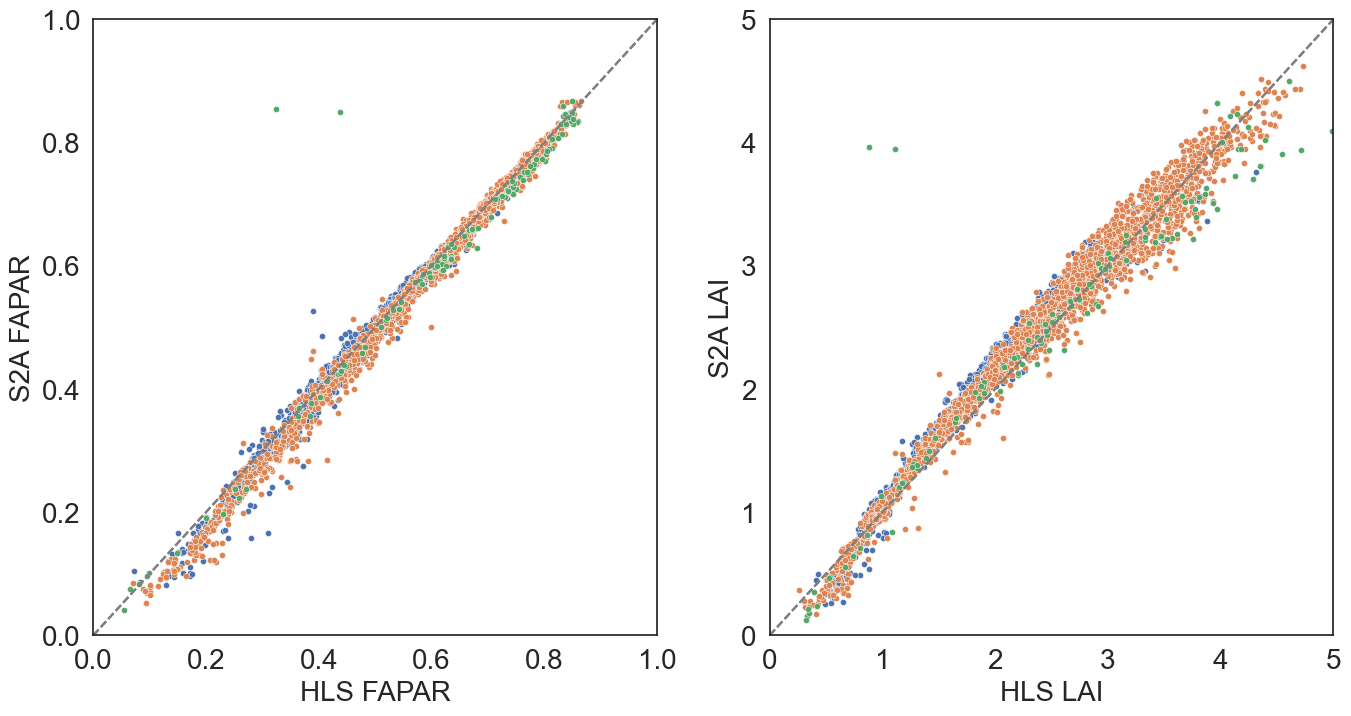

In [312]:
NLCD_groups = {'evergreenForest':['evergreenForest'],'deciduousForest':['deciduousForest','mixedForest','woodyWetlands'],'nonForest':['grasslandHerbaceous','shrubScrub','pastureHay','cultivatedCrops']}
fig,axs = plt.subplots(1,2,figsize=(16,8))
for group_key,group_listgroup in NLCD_groups.items(): 
    df1 = validation['fAPAR']['HLSS30']['HLSL30']['60m']['7d']['all'][group_key]['data']
    df2 = validation['fAPAR']['HLSS30']['S2A']['60m']['7d']['all'][group_key]['data']
    df = df1.merge(df2, on=['Plot','date'],suffixes=("_left", "_right"))
    sns.scatterplot(df ,x='x_left',y='x_right',ax=axs[0],s=20)
    axs[0].set_xlim(0,1)
    axs[0].set_ylim(0,1)
    axs[0].set_xlabel('HLS FAPAR')
    axs[0].set_ylabel('S2A FAPAR')
    axs[0].plot([0,1], [0,1], color='grey', ls='--')

    df1 = validation['LAI']['HLSS30']['HLSL30']['60m']['7d']['all'][group_key]['data']
    df2 = validation['LAI']['HLSS30']['S2A']['60m']['7d']['all'][group_key]['data']
    df = df1.merge(df2, on=['Plot','date'],suffixes=("_left", "_right"))
    sns.scatterplot(df ,x='x_left',y='x_right',ax=axs[1],s=20)
    axs[1].set_xlim(0,5)
    axs[1].set_ylim(0,5)
    axs[1].set_xlabel('HLS LAI')
    axs[1].set_ylabel('S2A LAI')
    axs[1].plot([0,5], [0,5], color='grey', ls='--')


In [338]:
df1['A_robust']=validation['fAPAR']['HLSS30']['HLSL30']['60m']['7d']['all']['evergreenForest']['A_robust']['q']
df1.loc[df1['A_robust']<-0.2]['NLCD_FRM'].unique()

array(['evergreenForest'], dtype=object)

In [101]:
validation['fAPAR']['HLS']['HLSL30']['60m']['7d']['all']['evergreenForest']['U_polyfit_user'].predict(np.array([0.1]))

{'y_hat': array([0.13435766]),
 'lower_ci': array([0.03097873]),
 'upper_ci': array([0.23773659]),
 'se_pred': array([0.05268504])}

In [77]:
list(validation['fAPAR']['HLS']['HLSL30']['60m']['7d']['all']['evergreenForest']['data'])

['system:index',
 'B1',
 'B10',
 'B11',
 'B12',
 'B2',
 'B3',
 'B4',
 'B5',
 'B6',
 'B7',
 'B8',
 'B8A',
 'B9',
 'Fmask',
 'Map',
 'NLCD',
 'Plot',
 'SAA',
 'SZA',
 'Site',
 'VAA',
 'VZA',
 'date',
 'latitude',
 'longitude',
 '.geo',
 'source_file',
 'sensor',
 'noflags',
 'Date',
 'year',
 'day_of_year',
 'RAA',
 'cosSZA',
 'cosVZA',
 'cosRAA',
 'estimatefAPAR',
 'fAPAR_networkID',
 'errorfAPAR',
 'fAPAR_QC_input',
 'fAPAR_QC_output',
 'estimateLAI',
 'LAI_networkID',
 'errorLAI',
 'LAI_QC_input',
 'LAI_QC_output',
 'NDVI',
 'Network',
 'Site_FRM',
 'Latitude',
 'Longitude',
 'NLCD_FRM',
 'PAIe_up',
 'PAI_up',
 'PAIe_Miller_up',
 'PAI_Miller_up',
 'FCOVER_up',
 'FIPAR_up',
 'PAIe_down',
 'PAI_down',
 'PAIe_Miller_down',
 'PAI_Miller_down',
 'FCOVER_down',
 'FCOVER_down2',
 'Method',
 'Processor',
 'Up_flag',
 'Down_flag',
 'Combined_flag',
 'WAI_up',
 'Alpha',
 'LAIe_up',
 'LAI_up',
 'LAIe_Miller_up',
 'LAI_Miller_up',
 'fAPAR_up',
 'GFCOVER_up',
 'LAIe',
 'LAI',
 'LAIe_Miller',
 'LAI

In [5]:
NLCD_groups = {'evergreenForest':['evergreenForest'],'deciduousForest':['deciduousForest','mixedForest','woodyWetlands'],'nonForest':['grasslandHerbaceous','shrubScrub','pastureHay','cultivatedCrops']}
tools.compare_results(dict1=validation['fAPAR']['HLS']['HLSL30']['60m']['7d'],dict2=validation['fAPAR']['HLS']['HLSL30']['60m']['1d'],variable='fAPAR',dict1_key='uniform',dict2_key='all',groups=NLCD_groups)

NameError: name 'validation' is not defined

In [105]:
import tools

1306
(1306, 174)
1634
(1634, 174)
70
(70, 174)


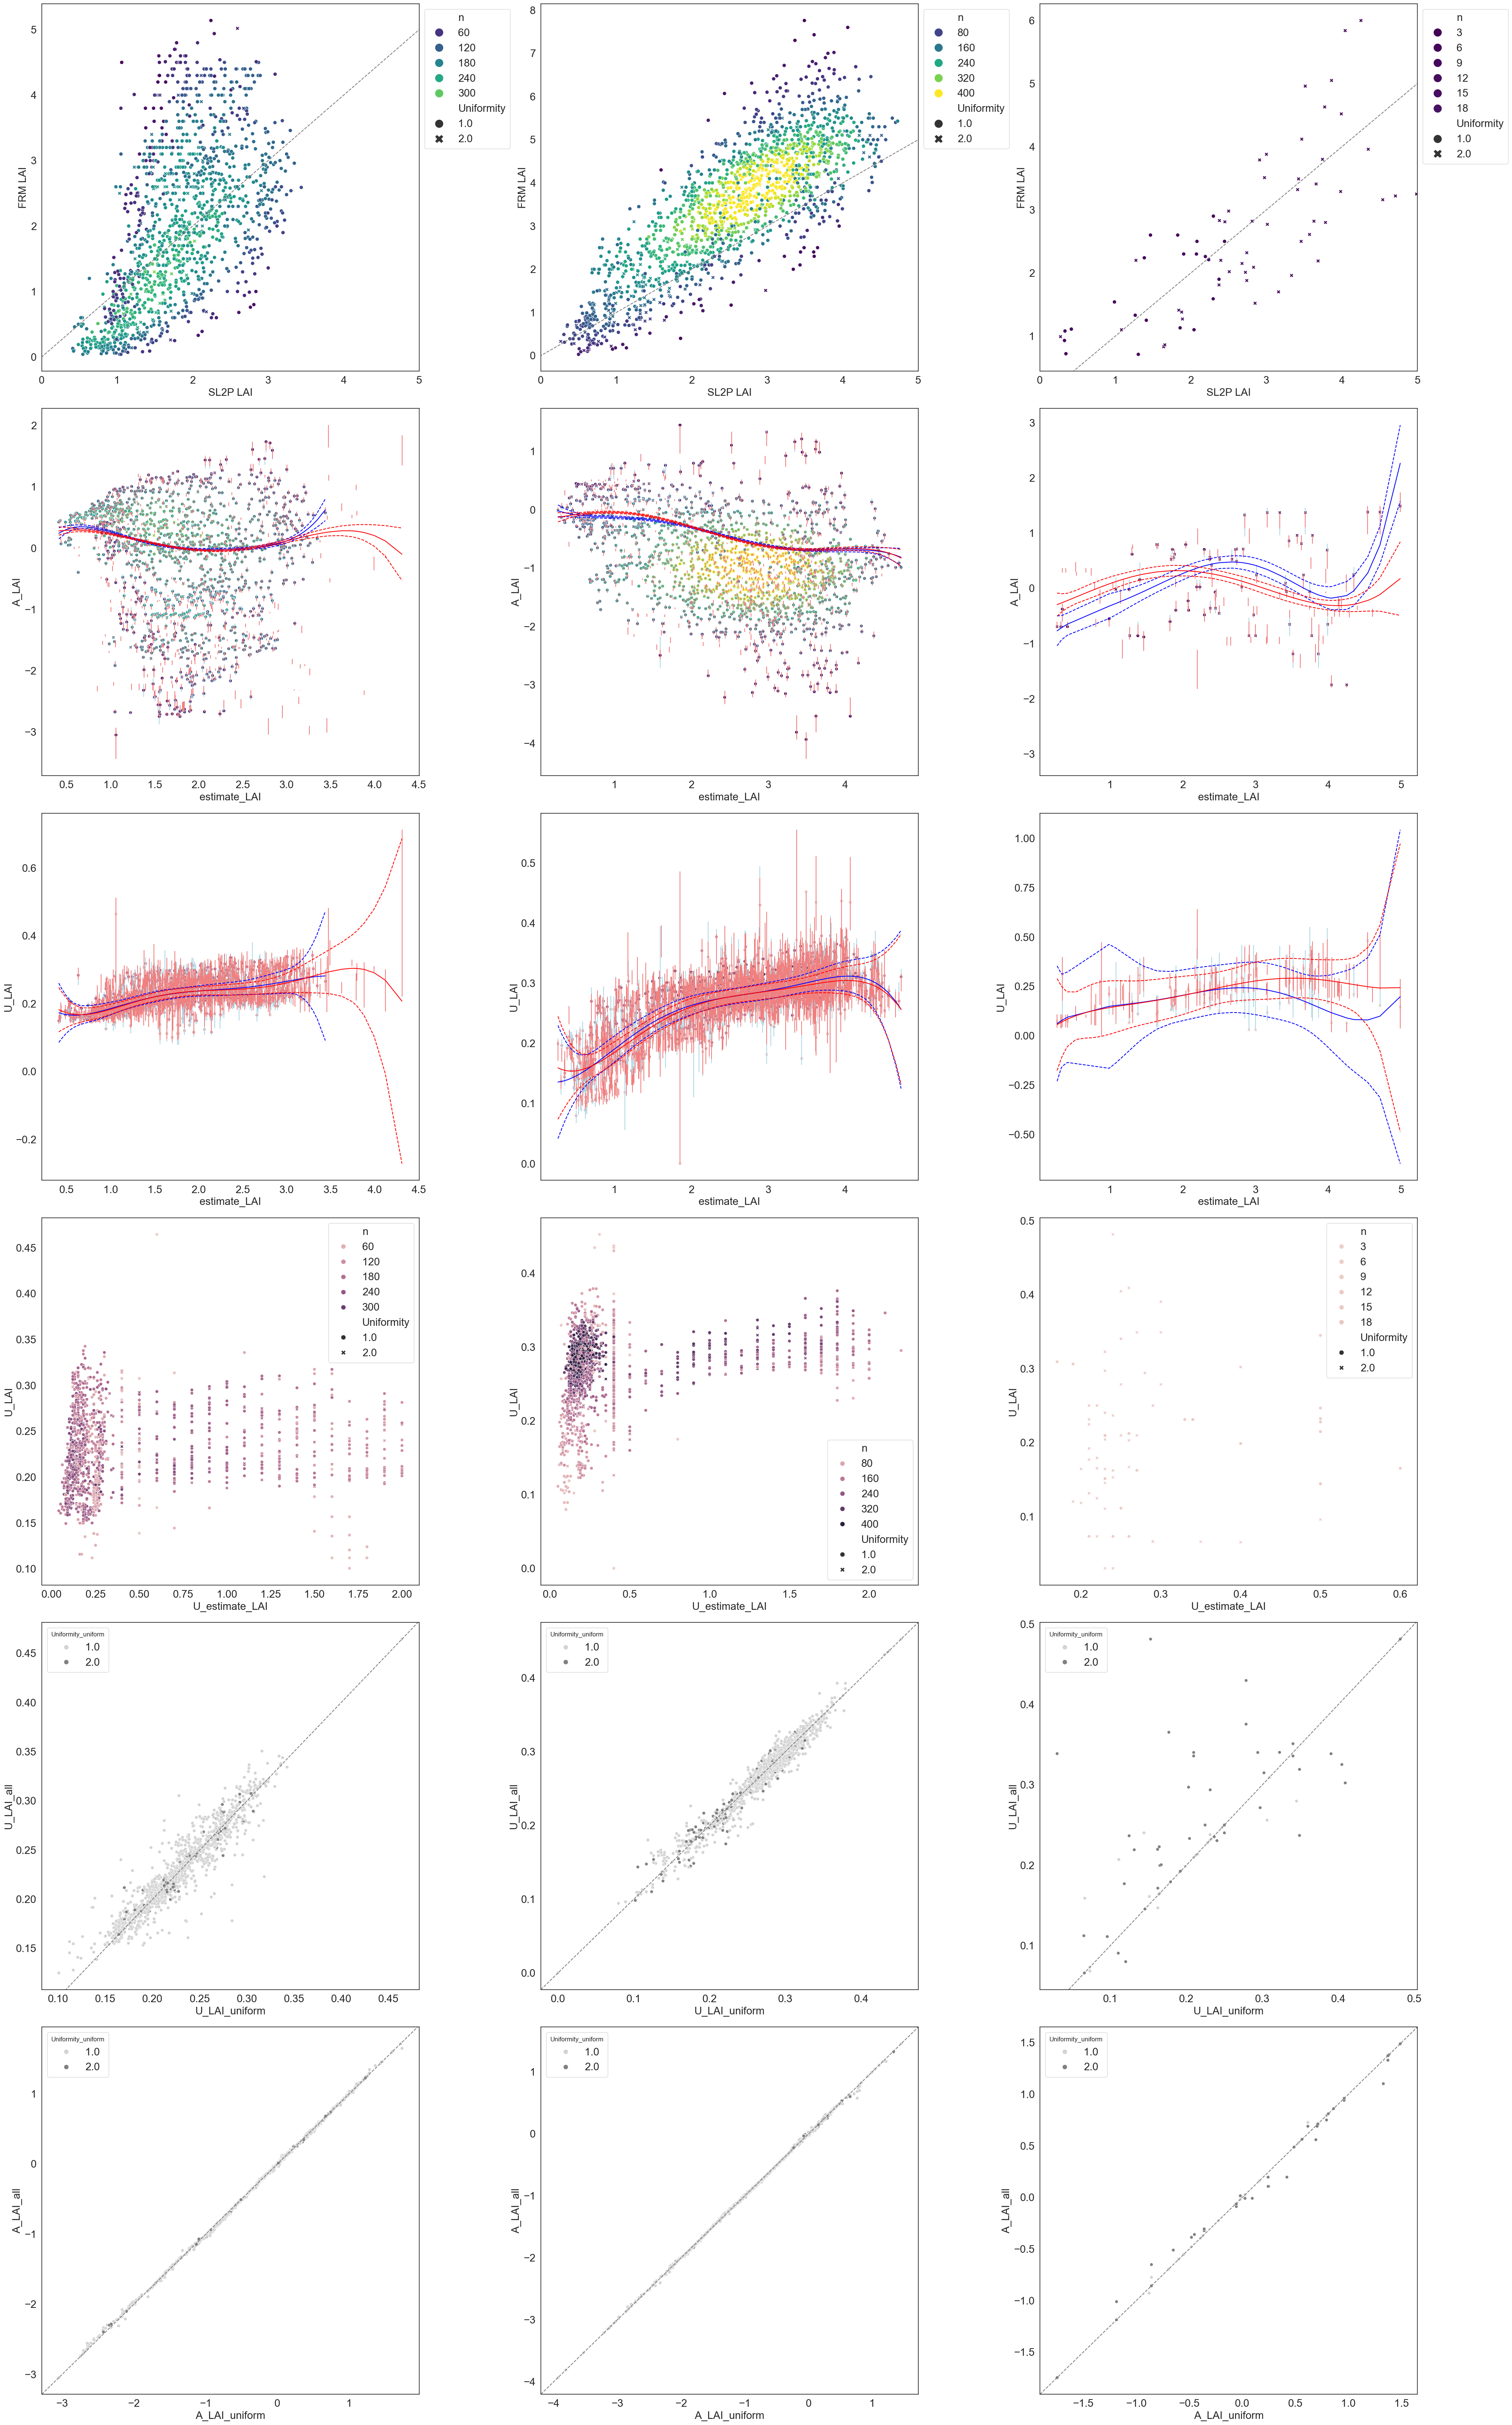

In [323]:
NLCD_groups = {'evergreenForest':['evergreenForest'],'deciduousForest':['deciduousForest','mixedForest','woodyWetlands'],'nonForest':['grasslandHerbaceous','shrubScrub','pastureHay','cultivatedCrops']}
tools.compare_results(dict1=validation['LAI']['HLS']['HLSL30']['60m']['7d'],dict2=validation['LAI']['HLS']['HLSL30']['60m']['7d'],variable='LAI',dict1_key='uniform',dict2_key='all',groups=NLCD_groups)

1632
(1632, 164)
1937
(1937, 164)
128
(128, 164)


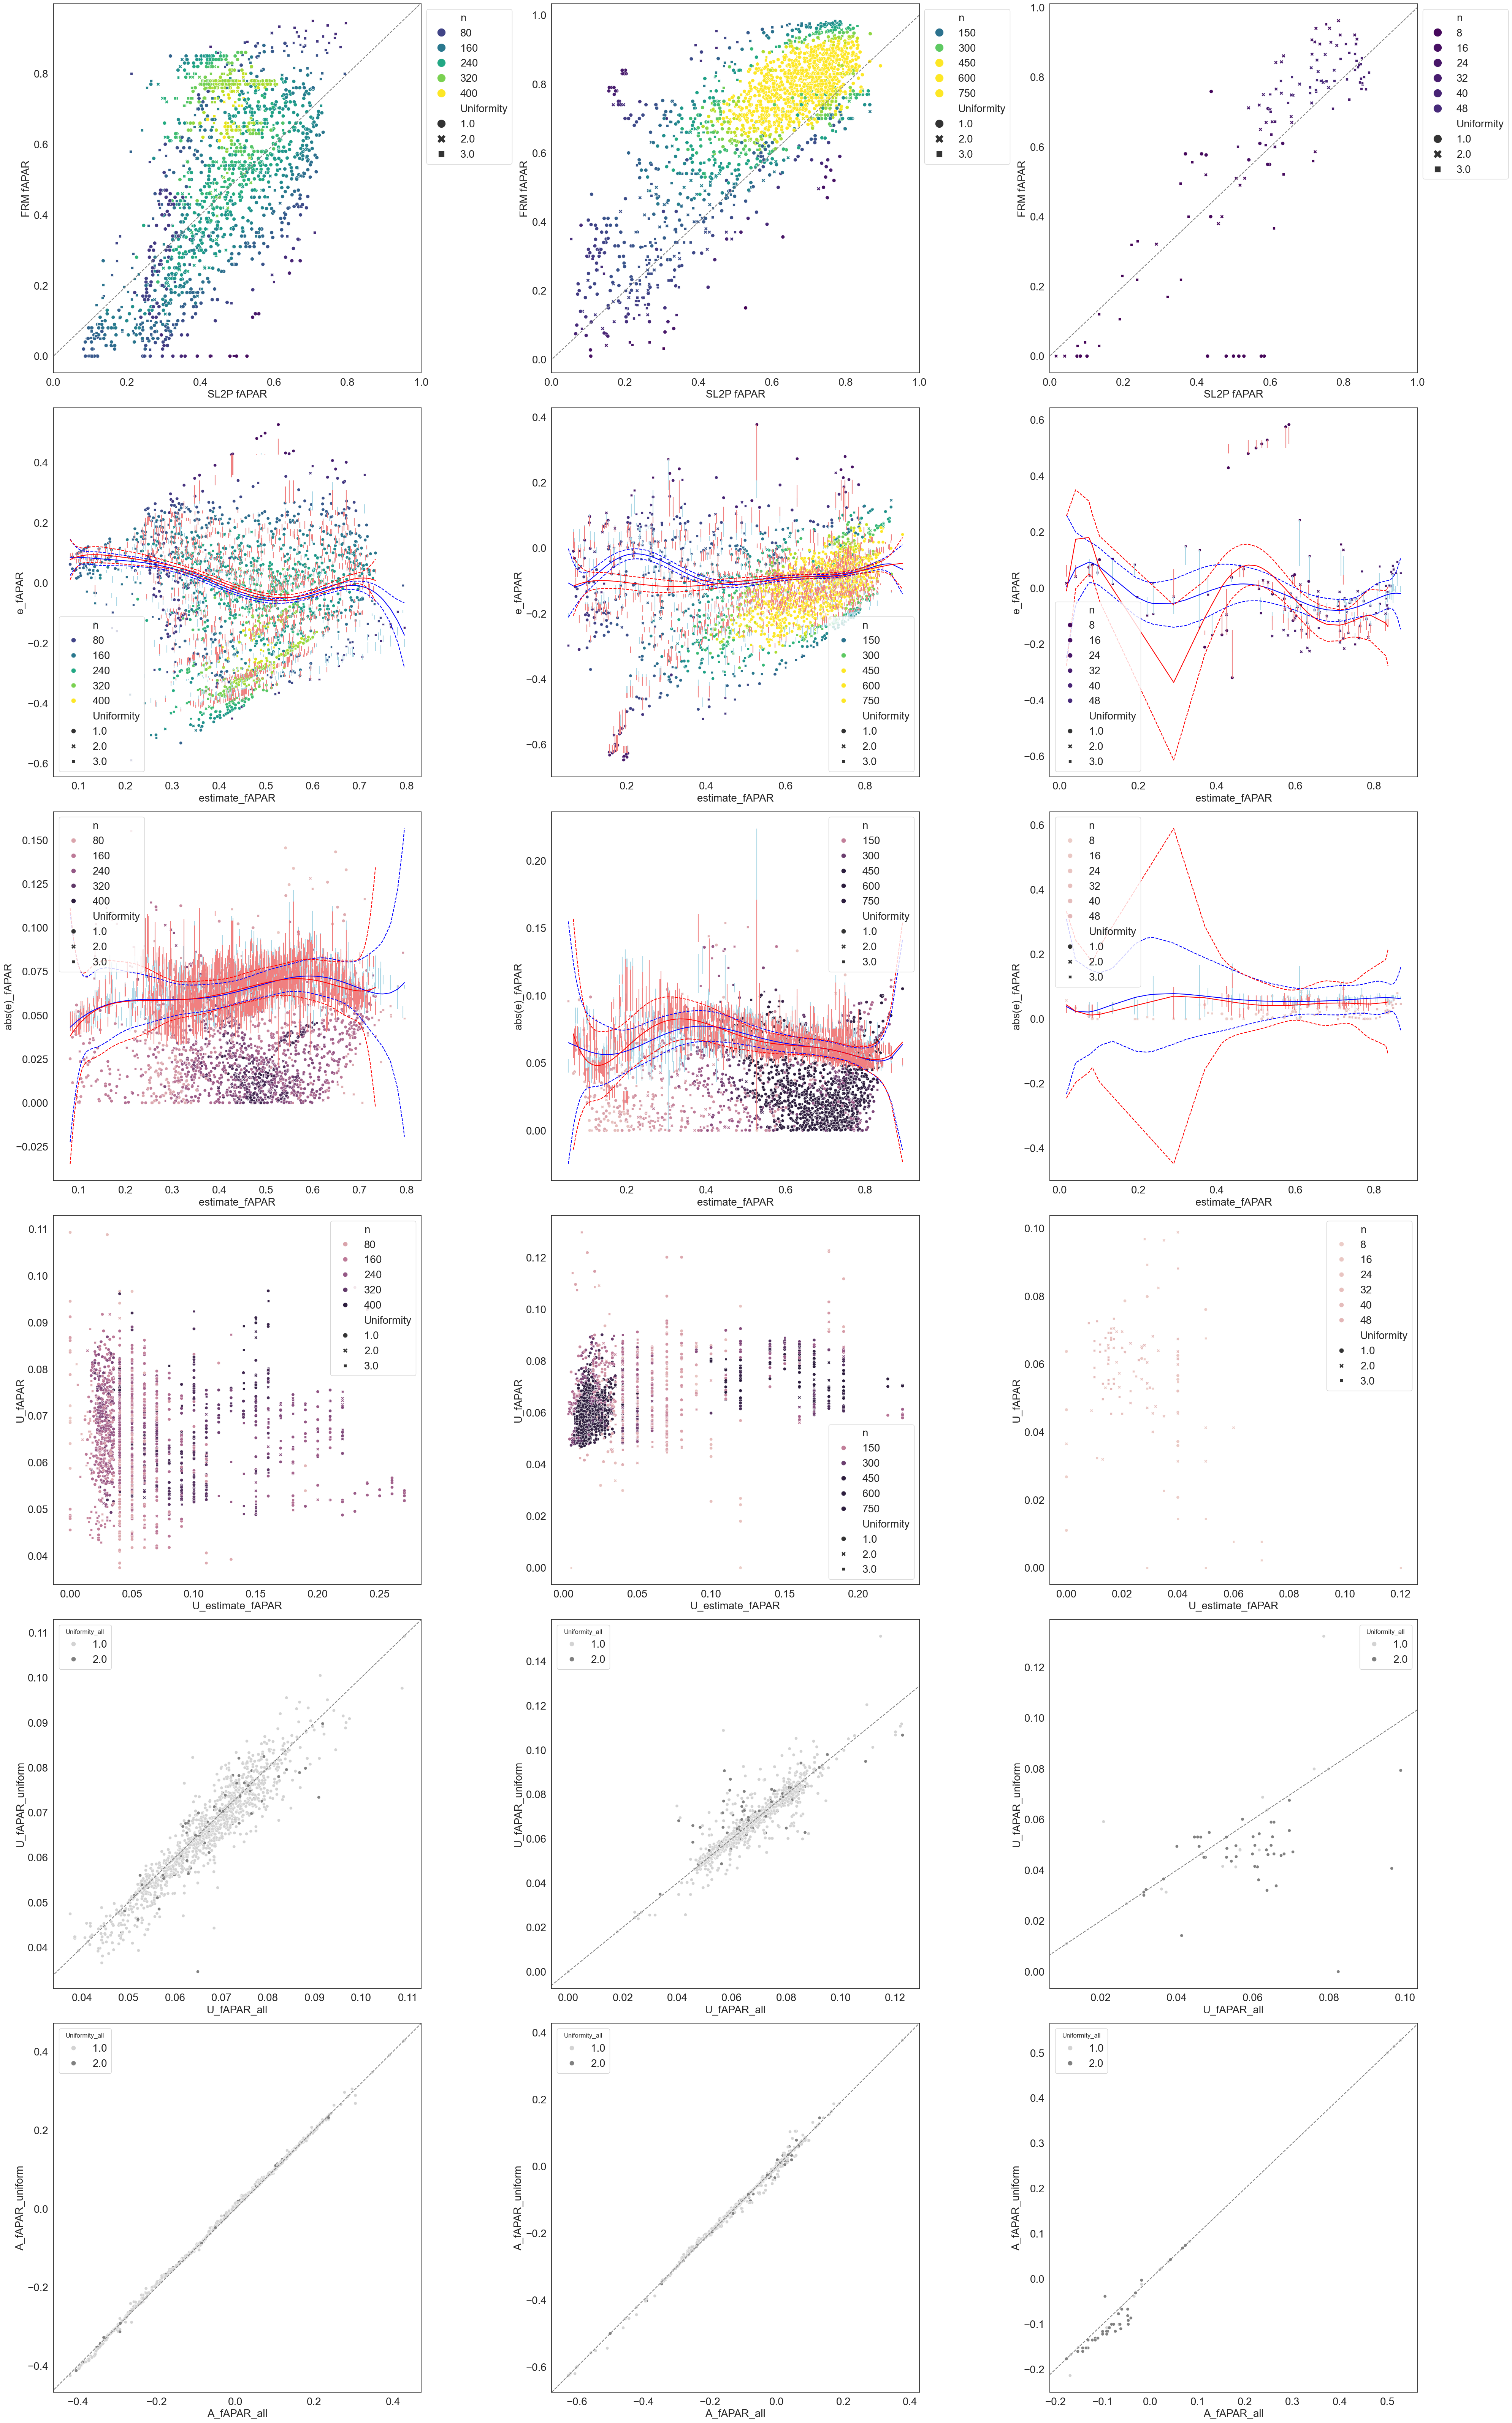

In [279]:
NLCD_groups = {'evergreenForest':['evergreenForest'],'deciduousForest':['deciduousForest','mixedForest','woodyWetlands'],'nonForest':['grasslandHerbaceous','shrubScrub','pastureHay','cultivatedCrops']}
tools.compare_results(dict1=validation['fAPAR']['HLSS30']['S2A']['60m']['7d'],dict2=validation['fAPAR']['HLSS30']['S2A']['60m']['7d'],variable='fAPAR',dict1_key='all',dict2_key='uniform',groups=NLCD_groups)

In [9]:
# HLS
NLCD_groups, = {'evergreenForest':['evergreenForest'],'deciduousForest':['deciduousForest','mixedForest','woodyWetlands'],'nonForest':['grasslandHerbaceous','shrubScrub','pastureHay','cultivatedCrops']}
validation_results = {}
for NLCD_key,NLCD_list in NLCD_groups,.items():
    validation = {}
    df = pd.read_pickle('D:/CEOS/InputData/groundedeohls/df_groundedeohls_SL2P_FRM_1d_LAI.pkl')
    validation['df_groundedeohls_SL2P_FRM_1d_LAI'] = {}
    df = df.loc[df['NLCD'].isin(NLCD_list)&(df['relabsmedianresidualfAPAR']<10)&(df['relabsmedianresidualLAI']<10) & (df['Uniformity']<4)]
    df['errorerrorLAI'] = np.minimum(0.4,0.2 * df['errorLAI'])
    n,A,U,A_robust,A_ci_upper,A_ci_lower,U_robust,U_ci_upper,U_ci_lower,A_polyfit_robust,U_polyfit_robust, lower,upper = \
        tools.estimateFRMAPU(x=df[['estimateLAI','errorLAI']].fillna(0),\
                             e=df['absmedianresidualLAI'].fillna(0),\
                             xnew=df[['estimateLAI','errorLAI']].fillna(0),\
                             xbandwidths=df[['errorLAI','errorerrorLAI']].fillna(0.5),\
                             order=3,\
                             lower=0.02,\
                             upper=0.98)
    U_robust_adj  =np.sqrt(np.maximum(0,np.power(U_robust,2)-np.power(df['medianLAI_ci'],2)))
    validation['df_groundedeohls_SL2P_FRM_1d_LAI']['samples']={'U_robust_adj':U_robust_adj,'estimate':df['estimateLAI'],'reference':df['LAI'],'estimateCI':df['errorLAI'],'referenceCI':df['medianLAI_ci'],'n':n,'A':A,'U':U,'A_robust':A_robust,'A_ci_upper':A_ci_upper,'A_ci_lower':A_ci_lower,'U_robust':U_robust,'U_ci_upper':U_ci_upper,'U_ci_lower':U_ci_lower}
    
    # df = pd.read_pickle('D:/CEOS/InputData/groundedeohls/df_groundedeohls_SL2P_FRM_7d_LAI.pkl')
    # validation['df_groundedeohls_SL2P_FRM_7d_LAI'] = {}
    # df = df.loc[df['NLCD'].isin(NLCD_list)&(df['relabsmedianresidualfAPAR']<10)&(df['relabsmedianresidualLAI']<10) & (df['Uniformity']<4)]
    # df['errorerrorLAI'] = np.minimum(0.4,0.2 * df['errorLAI'])
    # n,A,U,A_robust,A_ci_upper,A_ci_lower,U_robust,U_ci_upper,U_ci_lower= tools.estimateFRMAPU(df[['estimateLAI','errorLAI']].fillna(0),df['absmedianresidualLAI'].fillna(0),df[['estimateLAI','errorLAI']].fillna(0),df[['errorLAI','errorerrorLAI']].fillna(0.5))
    # U_robust_adj  =np.sqrt(np.maximum(0,np.power(U_robust,2)-np.power(df['medianLAI_ci'],2)))
    # validation['df_groundedeohls_SL2P_FRM_7d_LAI']['samples']={'U_robust_adj':U_robust_adj,'estimate':df['estimateLAI'],'reference':df['LAI'],'estimateCI':df['errorLAI'],'referenceCI':df['medianLAI_ci'],'n':n,'A':A,'U':U,'A_robust':A_robust,'A_ci_upper':A_ci_upper,'A_ci_lower':A_ci_lower,'U_robust':U_robust,'U_ci_upper':U_ci_upper,'U_ci_lower':U_ci_lower}
    
    # df = pd.read_pickle('D:/CEOS/InputData/groundedeohls/df_groundedeohls_SL2P_FRM_1d_LAI.pkl')
    # validation['df_groundedeohls_SL2P_FRM_1d_LAI_uniform'] = {}
    # df = df.loc[df['NLCD'].isin(NLCD_list)&(df['relabsmedianresidualfAPAR']<10)&(df['relabsmedianresidualLAI']<10) & (df['Uniformity']<3)]
    # df['errorerrorLAI'] = np.minimum(0.4,0.2 * df['errorLAI'])
    # n,A,U,A_robust,A_ci_upper,A_ci_lower,U_robust,U_ci_upper,U_ci_lower= tools.estimateFRMAPU(df[['estimateLAI','errorLAI']].fillna(0),df['medianresidualLAI'].fillna(0),df[['estimateLAI','errorLAI']].fillna(0),df[['errorLAI','errorerrorLAI']].fillna(0.5))
    # U_robust_adj  =np.sqrt(np.maximum(0,np.power(U_robust,2)-np.power(df['medianLAI_ci'],2)))
    # validation['df_groundedeohls_SL2P_FRM_1d_LAI_uniform']['samples']={'U_robust_adj':U_robust_adj,'estimate':df['estimateLAI'],'reference':df['LAI'],'estimateCI':df['errorLAI'],'referenceCI':df['LAI_ci'],'n':n,'A':A,'U':U,'A_robust':A_robust,'A_ci_upper':A_ci_upper,'A_ci_lower':A_ci_lower,'U_robust':U_robust,'U_ci_upper':U_ci_upper,'U_ci_lower':U_ci_lower}
    
    # df = pd.read_pickle('D:/CEOS/InputData/groundedeohls/df_groundedeohls_SL2P_FRM_7d_LAI.pkl')
    # validation['df_groundedeohls_SL2P_FRM_7d_LAI_uniform'] = {}
    # df = df.loc[df['NLCD'].isin(NLCD_list)&(df['relabsmedianresidualfAPAR']<10)&(df['relabsmedianresidualLAI']<10) & (df['Uniformity']<3)]
    # df['errorerrorLAI'] = np.minimum(0.4,0.2 * df['errorLAI'])
    # n,A,U,A_robust,A_ci_upper,A_ci_lower,U_robust,U_ci_upper,U_ci_lower= tools.estimateFRMAPU(df[['estimateLAI','errorLAI']].fillna(0),df['absmedianresidualLAI'].fillna(0),df[['estimateLAI','errorLAI']].fillna(0),df[['errorLAI','errorerrorLAI']].fillna(0.5))
    # U_robust_adj  =np.sqrt(np.maximum(0,np.power(U_robust,2)-np.power(df['medianLAI_ci'],2)))
    # validation['df_groundedeohls_SL2P_FRM_7d_LAI_uniform']['samples']={'estimate':df['estimateLAI'],'reference':df['LAI'],'estimateCI':df['errorLAI'],'referenceCI':df['LAI_ci'],'n':n,'A':A,'U':U,'A_robust':A_robust,'A_ci_upper':A_ci_upper,'A_ci_lower':A_ci_lower,'U_robust':U_robust,'U_ci_upper':U_ci_upper,'U_ci_lower':U_ci_lower}
    
    # df = pd.read_pickle('D:/CEOS/InputData/groundedeohls/df_groundedeohls_SL2P_FRM_1d_fAPAR.pkl')
    # validation['df_groundedeohls_SL2P_FRM_1d_fAPAR'] = {}
    # df = df.loc[df['NLCD'].isin(NLCD_list)&(df['relabsmedianresidualfAPAR']<10)&(df['relabsmedianresidualfAPAR']<10) & (df['Uniformity']<4)]
    # df['errorerrorfAPAR'] = np.minimum(0.04,0.2 * df['errorfAPAR'])
    # n,A,U,A_robust,A_ci_upper,A_ci_lower,U_robust,U_ci_upper,U_ci_lower= tools.estimateFRMAPU(df[['estimatefAPAR','errorfAPAR']].fillna(0),df['absmedianresidualfAPAR'].fillna(0),df[['estimatefAPAR','errorfAPAR']].fillna(0),df[['errorfAPAR','errorerrorfAPAR']].fillna(0.5))
    # U_robust_adj  =np.sqrt(np.maximum(0,np.power(U_robust,2)-np.power(df['medianfAPAR_ci'],2)))
    # validation['df_groundedeohls_SL2P_FRM_1d_fAPAR']['samples']={'U_robust_adj':U_robust_adj,'estimate':df['estimatefAPAR'],'reference':df['FAPAR'],'estimateCI':df['errorfAPAR'],'referenceCI':df['medianfAPAR_ci'],'n':n,'A':A,'U':U,'A_robust':A_robust,'A_ci_upper':A_ci_upper,'A_ci_lower':A_ci_lower,'U_robust':U_robust,'U_ci_upper':U_ci_upper,'U_ci_lower':U_ci_lower}
    
    # df = pd.read_pickle('D:/CEOS/InputData/groundedeohls/df_groundedeohls_SL2P_FRM_7d_fAPAR.pkl')
    # validation['df_groundedeohls_SL2P_FRM_7d_fAPAR'] = {}
    # df = df.loc[df['NLCD'].isin(NLCD_list)&(df['relabsmedianresidualfAPAR']<10)&(df['relabsmedianresidualfAPAR']<10) & (df['Uniformity']<4)]
    # df['errorerrorfAPAR'] = np.minimum(0.04,0.2 * df['errorfAPAR'])
    # n,A,U,A_robust,A_ci_upper,A_ci_lower,U_robust,U_ci_upper,U_ci_lower= tools.estimateFRMAPU(df[['estimatefAPAR','errorfAPAR']].fillna(0),df['absmedianresidualfAPAR'].fillna(0),df[['estimatefAPAR','errorfAPAR']].fillna(0),df[['errorfAPAR','errorerrorfAPAR']].fillna(0.5))
    # U_robust_adj  =np.sqrt(np.maximum(0,np.power(U_robust,2)-np.power(df['medianfAPAR_ci'],2)))
    # validation['df_groundedeohls_SL2P_FRM_7d_fAPAR']['samples']={'U_robust_adj':U_robust_adj,'estimate':df['estimatefAPAR'],'reference':df['FAPAR'],'estimateCI':df['errorfAPAR'],'referenceCI':df['medianfAPAR_ci'],'n':n,'A':A,'U':U,'A_robust':A_robust,'A_ci_upper':A_ci_upper,'A_ci_lower':A_ci_lower,'U_robust':U_robust,'U_ci_upper':U_ci_upper,'U_ci_lower':U_ci_lower}
    
    # df = pd.read_pickle('D:/CEOS/InputData/groundedeohls/df_groundedeohls_SL2P_FRM_1d_fAPAR.pkl')
    # validation['df_groundedeohls_SL2P_FRM_1d_fAPAR_uniform'] = {}
    # df = df.loc[df['NLCD'].isin(NLCD_list)&(df['relabsmedianresidualfAPAR']<10)&(df['relabsmedianresidualfAPAR']<10) & (df['Uniformity']<3)]
    # df['errorerrorfAPAR'] = np.minimum(0.04,0.2 * df['errorfAPAR'])
    # n,A,U,A_robust,A_ci_upper,A_ci_lower,U_robust,U_ci_upper,U_ci_lower= tools.estimateFRMAPU(df[['estimatefAPAR','errorfAPAR']].fillna(0),df['medianresidualfAPAR'].fillna(0),df[['estimatefAPAR','errorfAPAR']].fillna(0),df[['errorfAPAR','errorerrorfAPAR']].fillna(0.5))
    # U_robust_adj  =np.sqrt(np.maximum(0,np.power(U_robust,2)-np.power(df['medianfAPAR_ci'],2)))
    # validation['df_groundedeohls_SL2P_FRM_1d_fAPAR_uniform']['samples']={'U_robust_adj':U_robust_adj,'estimate':df['estimatefAPAR'],'reference':df['FAPAR'],'estimateCI':df['errorfAPAR'],'referenceCI':df['medianfAPAR_ci'],'n':n,'A':A,'U':U,'A_robust':A_robust,'A_ci_upper':A_ci_upper,'A_ci_lower':A_ci_lower,'U_robust':U_robust,'U_ci_upper':U_ci_upper,'U_ci_lower':U_ci_lower}
    
    # df = pd.read_pickle('D:/CEOS/InputData/groundedeohls/df_groundedeohls_SL2P_FRM_7d_fAPAR.pkl')
    # validation['df_groundedeohls_SL2P_FRM_7d_fAPAR_uniform'] = {}
    # df = df.loc[df['NLCD'].isin(NLCD_list)&(df['relabsmedianresidualfAPAR']<10)&(df['relabsmedianresidualfAPAR']<10) & (df['Uniformity']<3)]
    # df['errorerrorfAPAR'] = np.minimum(0.04,0.2 * df['errorfAPAR'])
    # n,A,U,A_robust,A_ci_upper,A_ci_lower,U_robust,U_ci_upper,U_ci_lower= tools.estimateFRMAPU(df[['estimatefAPAR','errorfAPAR']].fillna(0),df['absmedianresidualfAPAR'].fillna(0),df[['estimatefAPAR','errorfAPAR']].fillna(0),df[['errorfAPAR','errorerrorfAPAR']].fillna(0.5))
    # U_robust_adj  =np.sqrt(np.maximum(0,np.power(U_robust,2)-np.power(df['medianfAPAR_ci'],2)))
    # validation['df_groundedeohls_SL2P_FRM_7d_fAPAR_uniform']['samples']={'U_robust_adj':U_robust_adj,'estimate':df['estimatefAPAR'],'reference':df['FAPAR'],'estimateCI':df['errorfAPAR'],'referenceCI':df['medianfAPAR_ci'],'n':n,'A':A,'U':U,'A_robust':A_robust,'A_ci_upper':A_ci_upper,'A_ci_lower':A_ci_lower,'U_robust':U_robust,'U_ci_upper':U_ci_upper,'U_ci_lower':U_ci_lower}


    # #HLS S30
    # df = pd.read_pickle('D:/CEOS/InputData/groundedeohls/df_groundedeohlss30_SL2P_FRM_1d_LAI.pkl')
    # validation['df_groundedeohlss30_SL2P_FRM_1d_LAI'] = {}
    # df = df.loc[df['NLCD'].isin(NLCD_list)&(df['relabsmedianresidualfAPAR']<10)&(df['relabsmedianresidualLAI']<10) & (df['Uniformity']<4)]
    # df['errorerrorLAI'] = np.minimum(0.4,0.2 * df['errorLAI'])
    # n,A,U,A_robust,A_ci_upper,A_ci_lower,U_robust,U_ci_upper,U_ci_lower= tools.estimateFRMAPU(df[['estimateLAI','errorLAI']].fillna(0),df['absmedianresidualLAI'].fillna(0),df[['estimateLAI','errorLAI']].fillna(0),df[['errorLAI','errorerrorLAI']].fillna(0.5))
    # U_robust_adj  =np.sqrt(np.maximum(0,np.power(U_robust,2)-np.power(df['medianLAI_ci'],2)))
    # validation['df_groundedeohlss30_SL2P_FRM_1d_LAI']['samples']={'U_robust_adj':U_robust_adj,'estimate':df['estimateLAI'],'reference':df['LAI'],'estimateCI':df['errorLAI'],'referenceCI':df['medianLAI_ci'],'n':n,'A':A,'U':U,'A_robust':A_robust,'A_ci_upper':A_ci_upper,'A_ci_lower':A_ci_lower,'U_robust':U_robust,'U_ci_upper':U_ci_upper,'U_ci_lower':U_ci_lower}
    
    # df = pd.read_pickle('D:/CEOS/InputData/groundedeohls/df_groundedeohlss30_SL2P_FRM_7d_LAI.pkl')
    # validation['df_groundedeohlss30_SL2P_FRM_7d_LAI'] = {}
    # df = df.loc[df['NLCD'].isin(NLCD_list)&(df['relabsmedianresidualfAPAR']<10)&(df['relabsmedianresidualLAI']<10) & (df['Uniformity']<4)]
    # df['errorerrorLAI'] = np.minimum(0.4,0.2 * df['errorLAI'])
    # n,A,U,A_robust,A_ci_upper,A_ci_lower,U_robust,U_ci_upper,U_ci_lower= tools.estimateFRMAPU(df[['estimateLAI','errorLAI']].fillna(0),df['absmedianresidualLAI'].fillna(0),df[['estimateLAI','errorLAI']].fillna(0),df[['errorLAI','errorerrorLAI']].fillna(0.5))
    # U_robust_adj  =np.sqrt(np.maximum(0,np.power(U_robust,2)-np.power(df['medianLAI_ci'],2)))
    # validation['df_groundedeohlss30_SL2P_FRM_7d_LAI']['samples']={'U_robust_adj':U_robust_adj,'estimate':df['estimateLAI'],'reference':df['LAI'],'estimateCI':df['errorLAI'],'referenceCI':df['medianLAI_ci'],'n':n,'A':A,'U':U,'A_robust':A_robust,'A_ci_upper':A_ci_upper,'A_ci_lower':A_ci_lower,'U_robust':U_robust,'U_ci_upper':U_ci_upper,'U_ci_lower':U_ci_lower}
    
    # df = pd.read_pickle('D:/CEOS/InputData/groundedeohls/df_groundedeohlss30_SL2P_FRM_1d_LAI.pkl')
    # validation['df_groundedeohlss30_SL2P_FRM_1d_LAI_uniform'] = {}
    # df = df.loc[df['NLCD'].isin(NLCD_list)&(df['relabsmedianresidualfAPAR']<10)&(df['relabsmedianresidualLAI']<10) & (df['Uniformity']<3)]
    # df['errorerrorLAI'] = np.minimum(0.4,0.2 * df['errorLAI'])
    # n,A,U,A_robust,A_ci_upper,A_ci_lower,U_robust,U_ci_upper,U_ci_lower= tools.estimateFRMAPU(df[['estimateLAI','errorLAI']].fillna(0),df['medianresidualLAI'].fillna(0),df[['estimateLAI','errorLAI']].fillna(0),df[['errorLAI','errorerrorLAI']].fillna(0.5))
    # U_robust_adj  =np.sqrt(np.maximum(0,np.power(U_robust,2)-np.power(df['medianLAI_ci'],2)))
    # validation['df_groundedeohlss30_SL2P_FRM_1d_LAI_uniform']['samples']={'U_robust_adj':U_robust_adj,'estimate':df['estimateLAI'],'reference':df['LAI'],'estimateCI':df['errorLAI'],'referenceCI':df['LAI_ci'],'n':n,'A':A,'U':U,'A_robust':A_robust,'A_ci_upper':A_ci_upper,'A_ci_lower':A_ci_lower,'U_robust':U_robust,'U_ci_upper':U_ci_upper,'U_ci_lower':U_ci_lower}
    
    # df = pd.read_pickle('D:/CEOS/InputData/groundedeohls/df_groundedeohlss30_SL2P_FRM_7d_LAI.pkl')
    # validation['df_groundedeohlss30_SL2P_FRM_7d_LAI_uniform'] = {}
    # df = df.loc[df['NLCD'].isin(NLCD_list)&(df['relabsmedianresidualfAPAR']<10)&(df['relabsmedianresidualLAI']<10) & (df['Uniformity']<3)]
    # df['errorerrorLAI'] = np.minimum(0.4,0.2 * df['errorLAI'])
    # n,A,U,A_robust,A_ci_upper,A_ci_lower,U_robust,U_ci_upper,U_ci_lower= tools.estimateFRMAPU(df[['estimateLAI','errorLAI']].fillna(0),df['absmedianresidualLAI'].fillna(0),df[['estimateLAI','errorLAI']].fillna(0),df[['errorLAI','errorerrorLAI']].fillna(0.5))
    # U_robust_adj  =np.sqrt(np.maximum(0,np.power(U_robust,2)-np.power(df['medianLAI_ci'],2)))
    # validation['df_groundedeohlss30_SL2P_FRM_7d_LAI_uniform']['samples']={'estimate':df['estimateLAI'],'reference':df['LAI'],'estimateCI':df['errorLAI'],'referenceCI':df['LAI_ci'],'n':n,'A':A,'U':U,'A_robust':A_robust,'A_ci_upper':A_ci_upper,'A_ci_lower':A_ci_lower,'U_robust':U_robust,'U_ci_upper':U_ci_upper,'U_ci_lower':U_ci_lower}
    
    # df = pd.read_pickle('D:/CEOS/InputData/groundedeohls/df_groundedeohlss30_SL2P_FRM_1d_fAPAR.pkl')
    # validation['df_groundedeohlss30_SL2P_FRM_1d_fAPAR'] = {}
    # df = df.loc[df['NLCD'].isin(NLCD_list)&(df['relabsmedianresidualfAPAR']<10)&(df['relabsmedianresidualfAPAR']<10) & (df['Uniformity']<4)]
    # df['errorerrorfAPAR'] = np.minimum(0.04,0.2 * df['errorfAPAR'])
    # n,A,U,A_robust,A_ci_upper,A_ci_lower,U_robust,U_ci_upper,U_ci_lower= tools.estimateFRMAPU(df[['estimatefAPAR','errorfAPAR']].fillna(0),df['absmedianresidualfAPAR'].fillna(0),df[['estimatefAPAR','errorfAPAR']].fillna(0),df[['errorfAPAR','errorerrorfAPAR']].fillna(0.5))
    # U_robust_adj  =np.sqrt(np.maximum(0,np.power(U_robust,2)-np.power(df['medianfAPAR_ci'],2)))
    # validation['df_groundedeohlss30_SL2P_FRM_1d_fAPAR']['samples']={'U_robust_adj':U_robust_adj,'estimate':df['estimatefAPAR'],'reference':df['FAPAR'],'estimateCI':df['errorfAPAR'],'referenceCI':df['medianfAPAR_ci'],'n':n,'A':A,'U':U,'A_robust':A_robust,'A_ci_upper':A_ci_upper,'A_ci_lower':A_ci_lower,'U_robust':U_robust,'U_ci_upper':U_ci_upper,'U_ci_lower':U_ci_lower}
    
    # df = pd.read_pickle('D:/CEOS/InputData/groundedeohls/df_groundedeohls_SL2P_FRM_7d_fAPAR.pkl')
    # validation['df_groundedeohlss30_SL2P_FRM_7d_fAPAR'] = {}
    # df = df.loc[df['NLCD'].isin(NLCD_list)&(df['relabsmedianresidualfAPAR']<10)&(df['relabsmedianresidualfAPAR']<10) & (df['Uniformity']<4)]
    # df['errorerrorfAPAR'] = np.minimum(0.04,0.2 * df['errorfAPAR'])
    # n,A,U,A_robust,A_ci_upper,A_ci_lower,U_robust,U_ci_upper,U_ci_lower= tools.estimateFRMAPU(df[['estimatefAPAR','errorfAPAR']].fillna(0),df['absmedianresidualfAPAR'].fillna(0),df[['estimatefAPAR','errorfAPAR']].fillna(0),df[['errorfAPAR','errorerrorfAPAR']].fillna(0.5),order=3,trim_percent=2)
    # U_robust_adj  =np.sqrt(np.maximum(0,np.power(U_robust,2)-np.power(df['medianfAPAR_ci'],2)))
    # validation['df_groundedeohls_SL2P_FRM_7d_fAPAR']['samples']={'U_robust_adj':U_robust_adj,'estimate':df['estimatefAPAR'],'reference':df['FAPAR'],'estimateCI':df['errorfAPAR'],'referenceCI':df['medianfAPAR_ci'],'n':n,'A':A,'U':U,'A_robust':A_robust,'A_ci_upper':A_ci_upper,'A_ci_lower':A_ci_lower,'U_robust':U_robust,'U_ci_upper':U_ci_upper,'U_ci_lower':U_ci_lower}
    
    # df = pd.read_pickle('D:/CEOS/InputData/groundedeohls/df_groundedeohlss30_SL2P_FRM_1d_fAPAR.pkl')
    # validation['df_groundedeohlss30_SL2P_FRM_1d_fAPAR_uniform'] = {}
    # df = df.loc[df['NLCD'].isin(NLCD_list)&(df['relabsmedianresidualfAPAR']<10)&(df['relabsmedianresidualfAPAR']<10) & (df['Uniformity']<3)]
    # df['errorerrorfAPAR'] = np.minimum(0.04,0.2 * df['errorfAPAR'])
    # n,A,U,A_robust,A_ci_upper,A_ci_lower,U_robust,U_ci_upper,U_ci_lower= tools.estimateFRMAPU(df[['estimatefAPAR','errorfAPAR']].fillna(0),df['medianresidualfAPAR'].fillna(0),df[['estimatefAPAR','errorfAPAR']].fillna(0),df[['errorfAPAR','errorerrorfAPAR']].fillna(0.5),order=3,trim_percent=2)
    # U_robust_adj  =np.sqrt(np.maximum(0,np.power(U_robust,2)-np.power(df['medianfAPAR_ci'],2)))
    # validation['df_groundedeohlss30_SL2P_FRM_1d_fAPAR_uniform']['samples']={'U_robust_adj':U_robust_adj,'estimate':df['estimatefAPAR'],'reference':df['FAPAR'],'estimateCI':df['errorfAPAR'],'referenceCI':df['medianfAPAR_ci'],'n':n,'A':A,'U':U,'A_robust':A_robust,'A_ci_upper':A_ci_upper,'A_ci_lower':A_ci_lower,'U_robust':U_robust,'U_ci_upper':U_ci_upper,'U_ci_lower':U_ci_lower}
    
    # df = pd.read_pickle('D:/CEOS/InputData/groundedeohls/df_groundedeohlss30_SL2P_FRM_7d_fAPAR.pkl')
    # validation['df_groundedeohlss30_SL2P_FRM_7d_fAPAR_uniform'] = {}
    # df = df.loc[df['NLCD'].isin(NLCD_list)&(df['relabsmedianresidualfAPAR']<10)&(df['relabsmedianresidualfAPAR']<10) & (df['Uniformity']<3)]
    # df['errorerrorfAPAR'] = np.minimum(0.04,0.2 * df['errorfAPAR'])
    # n,A,U,A_robust,A_ci_upper,A_ci_lower,U_robust,U_ci_upper,U_ci_lower,polyFit_robust= tools.estimateFRMAPU(df[['estimatefAPAR','errorfAPAR']].fillna(0),df['absmedianresidualfAPAR'].fillna(0),df[['estimatefAPAR','errorfAPAR']].fillna(0),df[['errorfAPAR','errorerrorfAPAR']].fillna(0.5),order=3,trim_percent=2)
    # U_robust_adj  =np.sqrt(np.maximum(0,np.power(U_robust,2)-np.power(df['medianfAPAR_ci'],2)))
    # validation['df_groundedeohlss30_SL2P_FRM_7d_fAPAR_uniform']['samples']={'U_robust_adj':U_robust_adj,'estimate':df['estimatefAPAR'],'reference':df['FAPAR'],'estimateCI':df['errorfAPAR'],'referenceCI':df['medianfAPAR_ci'],'n':n,'A':A,'U':U,'A_robust':A_robust,'A_ci_upper':A_ci_upper,'A_ci_lower':A_ci_lower,'U_robust':U_robust,'U_ci_upper':U_ci_upper,'U_ci_lower':U_ci_lower}
    
    validation_results[NLCD_key]=validation


ValueError: If using all scalar values, you must pass an index

<Axes: xlabel='estimatefAPAR', ylabel='FAPAR'>

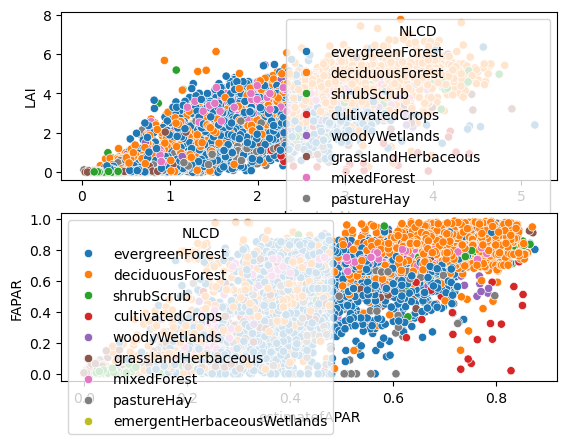

In [830]:
fig,axs=plt.subplots(2,1)
df = df_groundedeohls_SL2P_FRM_7d_LAI
sns.scatterplot(df,x='estimateLAI',y='LAI',hue='NLCD',ax=axs[0])
df = df_groundedeohls_SL2P_FRM_7d_fAPAR
sns.scatterplot(df,x='estimatefAPAR',y='FAPAR',hue='NLCD',ax=axs[1])

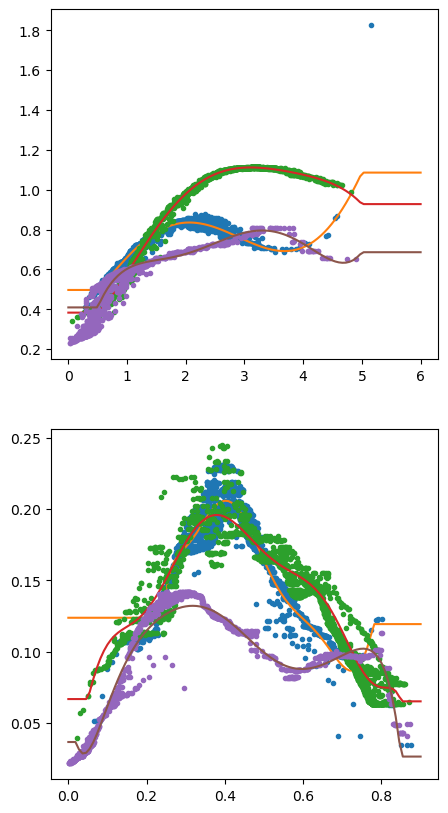

In [1173]:

fig,axs =  plt.subplots(2,1,figsize=(5,10))
#fit bias correction to measured 1d data for synthetic data generation
df = pd.DataFrame(validation_results['evergreenForest']['df_groundedeohls_SL2P_FRM_7d_LAI']['samples'])
x = df['estimate']
y = df['A_robust']
fit = tools.fit_A(df,5,0.5,5)
validation_results['evergreenForest']['df_groundedeohls_SL2P_FRM_7d_LAI']['fit_A'] = fit
axs[0].plot(x,y,'.')
axs[0].plot(np.linspace(0,6,100), tools.pred(np.linspace(0,6,100),fit))

#fit bias correction to measured 1d data for synthetic data generation
df = pd.DataFrame(validation_results['deciduousForest']['df_groundedeohls_SL2P_FRM_7d_LAI']['samples'])
x = df['estimate']
y = df['A_robust']
fit = tools.fit_A(df,5,0.5,5)
validation_results['deciduousForest']['df_groundedeohls_SL2P_FRM_7d_LAI']['fit_A'] = fit
axs[0].plot(x,y,'.')
axs[0].plot(np.linspace(0,6,100), tools.pred(np.linspace(0,6,100),fit))

#fit bias correction to measured 1d data for synthetic data generation
df = pd.DataFrame(validation_results['nonForest']['df_groundedeohls_SL2P_FRM_7d_LAI']['samples'])
x = df['estimate']
y = df['A_robust']
fit = tools.fit_A(df,5,0.5,5)
validation_results['nonForest']['df_groundedeohls_SL2P_FRM_7d_LAI']['fit_A'] = fit
axs[0].plot(x,y,'.')
axs[0].plot(np.linspace(0,6,100), tools.pred(np.linspace(0,6,100),fit))

#fit bias correction to measured 1d data for synthetic data generation
df = pd.DataFrame(validation_results['evergreenForest']['df_groundedeohls_SL2P_FRM_7d_fAPAR']['samples'])
x = df['estimate']
y = df['A_robust']
fit = tools.fit_A(df,9,0.24,0.78)
validation_results['evergreenForest']['df_groundedeohls_SL2P_FRM_7d_fAPAR']['fit_A'] = fit
axs[1].plot(x,y,'.')
axs[1].plot(np.linspace(0,.9,100), tools.pred(np.linspace(0,.9,100),fit))

#fit bias correction to measured 1d data for synthetic data generation
df = pd.DataFrame(validation_results['deciduousForest']['df_groundedeohls_SL2P_FRM_7d_fAPAR']['samples'])
x = df['estimate']
y = df['A_robust']
fit = tools.fit_A(df,9,0.05,0.85)
validation_results['deciduousForest']['df_groundedeohls_SL2P_FRM_7d_fAPAR']['fit_A'] = fit
axs[1].plot(x,y,'.')
axs[1].plot(np.linspace(0,.9,100), tools.pred(np.linspace(0,.9,100),fit))

#fit bias correction to measured 1d data for synthetic data generation
df = pd.DataFrame(validation_results['nonForest']['df_groundedeohls_SL2P_FRM_7d_fAPAR']['samples'])
x = df['estimate']
y = df['A_robust']
fit = tools.fit_A(df,9,0.02,0.85)
validation_results['nonForest']['df_groundedeohls_SL2P_FRM_7d_fAPAR']['fit_A'] = fit
axs[1].plot(x,y,'.')
axs[1].plot(np.linspace(0,.9,100), tools.pred(np.linspace(0,.9,100),fit))


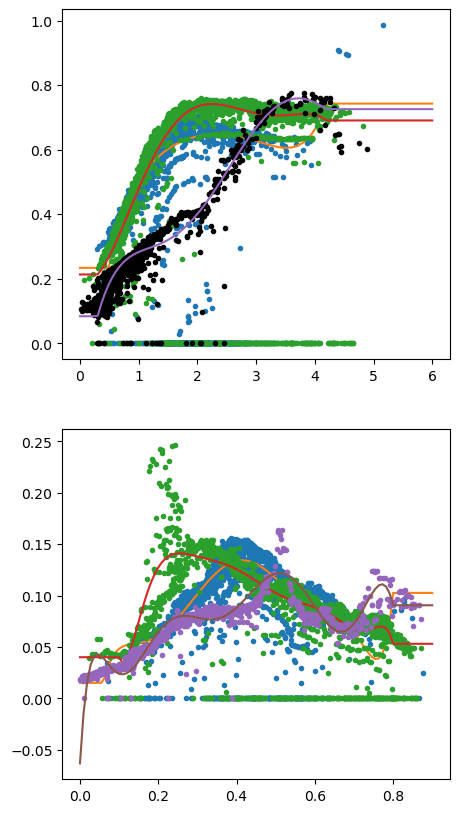

In [1222]:

fig,axs =  plt.subplots(2,1,figsize=(5,10))
#fit bias correction to measured 1d data for synthetic data generation
df = pd.DataFrame(validation_results['evergreenForest']['df_groundedeohls_SL2P_FRM_7d_LAI']['samples'])
x = df['estimate']
y = df['U_robust_adj'] 
fit = tools.fit_U(df,5,0.5,4.2)
validation_results['evergreenForest']['df_groundedeohls_SL2P_FRM_7d_LAI']['fit_U'] = fit
axs[0].plot(x,y,'.')
axs[0].plot(np.linspace(0,6,100), tools.pred(np.linspace(0,6,100),fit))

#fit bias correction to measured 1d data for synthetic data generation
df = pd.DataFrame(validation_results['deciduousForest']['df_groundedeohls_SL2P_FRM_7d_LAI']['samples'])
x = df['estimate']
y = df['U_robust_adj'] 
fit = tools.fit_U(df,5,0.3,4.2)
validation_results['deciduousForest']['df_groundedeohls_SL2P_FRM_7d_LAI']['fit_U'] = fit
axs[0].plot(x,y,'.')
axs[0].plot(np.linspace(0,6,100), tools.pred(np.linspace(0,6,100),fit))

#fit bias correction to measured 1d data for synthetic data generation
df = pd.DataFrame(validation_results['nonForest']['df_groundedeohls_SL2P_FRM_7d_LAI']['samples'])
x = df['estimate']
y = df['U_robust_adj'] 
fit = tools.fit_U(df,5,0.3,4.2)
validation_results['nonForest']['df_groundedeohls_SL2P_FRM_7d_LAI']['fit_U'] = fit
axs[0].plot(x,y,'k.')
axs[0].plot(np.linspace(0,6,100), tools.pred(np.linspace(0,6,100),fit))

#fit bias correction to measured 1d data for synthetic data generation
df = pd.DataFrame(validation_results['evergreenForest']['df_groundedeohls_SL2P_FRM_7d_fAPAR']['samples'])
x = df['estimate']
y = df['U_robust_adj'] 
fit = tools.fit_U(df,9,0.06,0.8)
validation_results['evergreenForest']['df_groundedeohls_SL2P_FRM_7d_fAPAR']['fit_U'] = fit
axs[1].plot(x,y,'.')
axs[1].plot(np.linspace(0,.9,100), tools.pred(np.linspace(0,.9,100),fit))

#fit bias correction to measured 1d data for synthetic data generation
df = pd.DataFrame(validation_results['deciduousForest']['df_groundedeohls_SL2P_FRM_7d_fAPAR']['samples'])
x = df['estimate']
y = df['U_robust_adj'] 
fit = tools.fit_U(df,9,0.1,0.8)
validation_results['deciduousForest']['df_groundedeohls_SL2P_FRM_7d_fAPAR']['fit_U'] = fit
axs[1].plot(x,y,'.')
axs[1].plot(np.linspace(0,.9,100), tools.pred(np.linspace(0,.9,100),fit))

#fit bias correction to measured 1d data for synthetic data generation
df = pd.DataFrame(validation_results['nonForest']['df_groundedeohls_SL2P_FRM_7d_fAPAR']['samples'])
x = df['estimate']
y = df['U_robust_adj'] 
fit = tools.fit_U(df,9,0.0,0.8)
validation_results['nonForest']['df_groundedeohls_SL2P_FRM_7d_fAPAR']['fit_U'] = fit
axs[1].plot(x,y,'.')
axs[1].plot(np.linspace(0,.9,100), tools.pred(np.linspace(0,.9,100),fit))


<Axes: xlabel='estimatefAPAR', ylabel='estimatefAPAR_nobias'>

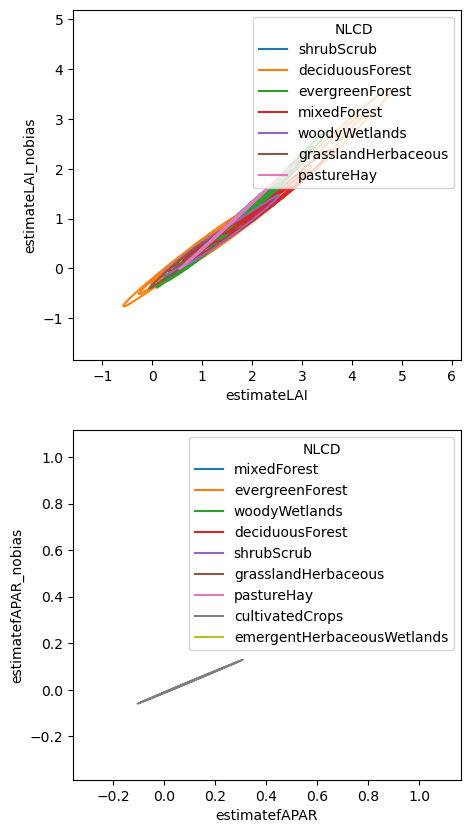

In [1186]:
#generate synthetic data by applying bias correction
df_groundedeohls_SL2P['estimateLAI_nobias']= df_groundedeohls_SL2P['estimateLAI']
df_groundedeohls_SL2P['estimatefAPAR_nobias']= df_groundedeohls_SL2P['estimatefAPAR']

for NLCD_key,NLCD_list in NLCD_groups,.items():

    df_groundedeohls_SL2P.loc[df_groundedeohls_SL2P['NLCD'].isin(NLCD_list),'estimateLAI_nobias'] -= tools.pred(df_groundedeohls_SL2P.loc[df_groundedeohls_SL2P['NLCD'].isin(NLCD_list),'estimateLAI'],
                                                                                                                    validation_results[NLCD_key]['df_groundedeohls_SL2P_FRM_7d_LAI']['fit_A'])
    df_groundedeohls_SL2P.loc[df_groundedeohls_SL2P['NLCD'].isin(NLCD_list),'estimatefAPAR_nobias'] -= tools.pred(df_groundedeohls_SL2P.loc[df_groundedeohls_SL2P['NLCD'].isin(NLCD_list),'estimatefAPAR'],
                                                                                                                    validation_results[NLCD_key]['df_groundedeohls_SL2P_FRM_7d_fAPAR']['fit_A'])
#verify bias correction
fig,axs = plt.subplots(2,1,figsize=(5,10))
sns.kdeplot(df_groundedeohls_SL2P.sample(1000),x='estimateLAI',y='estimateLAI_nobias',hue='NLCD',ax=axs[0])
sns.kdeplot(df_groundedeohls_SL2P.sample(1000),x='estimatefAPAR',y='estimatefAPAR_nobias',hue='NLCD',ax=axs[1])    

<Axes: xlabel='estimatefAPAR', ylabel='estimatefAPAR_nobias'>

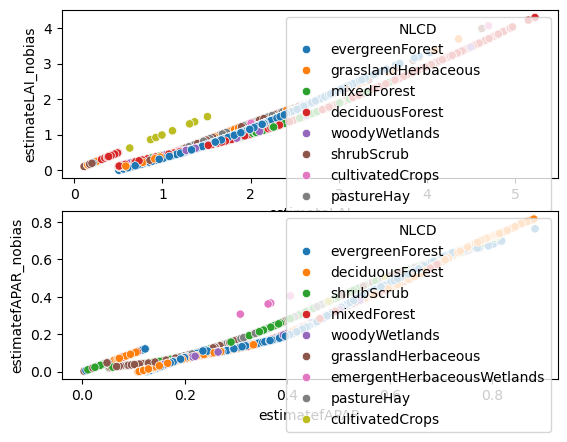

In [1188]:
#generate synthetic data by applying bias correction but for a limited range
df_groundedeohls_SL2P['estimateLAI_nobias']= df_groundedeohls_SL2P['estimateLAI']
df_groundedeohls_SL2P['estimatefAPAR_nobias']= df_groundedeohls_SL2P['estimatefAPAR']

for NLCD_key,NLCD_list in NLCD_groups,.items():

    df_groundedeohls_SL2P.loc[(df_groundedeohls_SL2P['NLCD'].isin(NLCD_list))&(df_groundedeohls_SL2P['estimateLAI']>0.5),'estimateLAI_nobias'] -= tools.pred(df_groundedeohls_SL2P.loc[(df_groundedeohls_SL2P['NLCD'].isin(NLCD_list))&(df_groundedeohls_SL2P['estimateLAI']>0.5),'estimateLAI'],
                                                                                                                    validation_results[NLCD_key]['df_groundedeohls_SL2P_FRM_7d_LAI']['fit_A'])
    df_groundedeohls_SL2P.loc[(df_groundedeohls_SL2P['NLCD'].isin(NLCD_list))&(df_groundedeohls_SL2P['estimatefAPAR']>0.05),'estimatefAPAR_nobias'] -= tools.pred(df_groundedeohls_SL2P.loc[(df_groundedeohls_SL2P['NLCD'].isin(NLCD_list))&(df_groundedeohls_SL2P['estimatefAPAR']>0.05),'estimatefAPAR'],
                                                                                                                    validation_results[NLCD_key]['df_groundedeohls_SL2P_FRM_7d_fAPAR']['fit_A'])
#verify bias correction
df_groundedeohls_SL2P['estimateLAI_nobias'] = df_groundedeohls_SL2P['estimateLAI_nobias'].where(df_groundedeohls_SL2P['estimateLAI_nobias'] >= 0, df_groundedeohls_SL2P['estimateLAI'])
df_groundedeohls_SL2P['estimatefAPAR_nobias'] = df_groundedeohls_SL2P['estimatefAPAR_nobias'].where(df_groundedeohls_SL2P['estimatefAPAR_nobias'] >= 0, df_groundedeohls_SL2P['estimatefAPAR'])
fig,axs=plt.subplots(2,1)
sns.scatterplot(df_groundedeohls_SL2P.sample(10000),x='estimateLAI',y='estimateLAI_nobias',hue='NLCD',ax=axs[0])
sns.scatterplot(df_groundedeohls_SL2P.sample(10000),x='estimatefAPAR',y='estimatefAPAR_nobias',hue='NLCD',ax=axs[1])    

<Axes: xlabel='estimatefAPAR_nobias', ylabel='estimatefAPAR_nobias_noisy'>

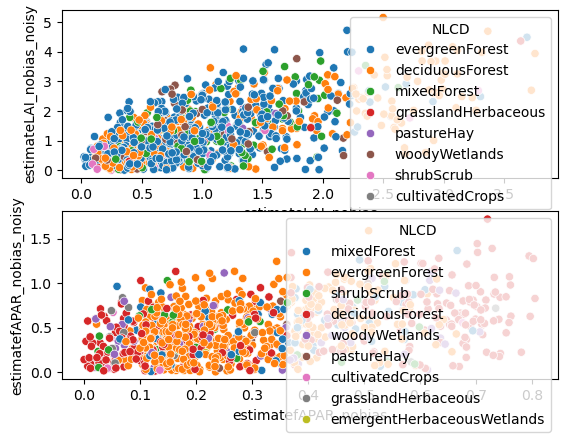

In [1232]:

df_groundedeohls_SL2P['LAI_scale']= 0*df_groundedeohls_SL2P['estimatefAPAR_nobias']
df_groundedeohls_SL2P['fAPAR_scale']= 0*df_groundedeohls_SL2P['estimatefAPAR_nobias']

rng = np.random.default_rng()
for NLCD_key,NLCD_list in NLCD_groups,.items():

    df_groundedeohls_SL2P.loc[df_groundedeohls_SL2P['NLCD'].isin(NLCD_list),'LAI_scale']= rng.normal(loc=0,scale=1.35*np.maximum(0.25,tools.pred(df_groundedeohls_SL2P.loc[df_groundedeohls_SL2P['NLCD'].isin(NLCD_list),'estimateLAI'],
                                                                                                                    validation_results[NLCD_key]['df_groundedeohls_SL2P_FRM_7d_LAI']['fit_U'])))
    df_groundedeohls_SL2P.loc[df_groundedeohls_SL2P['NLCD'].isin(NLCD_list),'fAPAR_scale']= rng.normal(loc=0,scale=1.35*np.maximum(0.25,tools.pred(df_groundedeohls_SL2P.loc[df_groundedeohls_SL2P['NLCD'].isin(NLCD_list),'estimatefAPAR'],
                                                                                                                    validation_results[NLCD_key]['df_groundedeohls_SL2P_FRM_7d_fAPAR']['fit_U'])))

df_groundedeohls_SL2P['estimateLAI_nobias_noisy']= df_groundedeohls_SL2P['estimateLAI_nobias'] + df_groundedeohls_SL2P['LAI_scale'] 
df_groundedeohls_SL2P['estimatefAPAR_nobias_noisy']= df_groundedeohls_SL2P['estimatefAPAR_nobias'] + df_groundedeohls_SL2P['fAPAR_scale'] 
    
#verify bias correction
df_groundedeohls_SL2P['estimateLAI_nobias_noisy'] = df_groundedeohls_SL2P['estimateLAI_nobias_noisy'].where(df_groundedeohls_SL2P['estimateLAI_nobias_noisy'] >= 0, df_groundedeohls_SL2P['estimateLAI_nobias']- df_groundedeohls_SL2P['LAI_scale'] )
df_groundedeohls_SL2P['estimatefAPAR_nobias_noisy'] = df_groundedeohls_SL2P['estimatefAPAR_nobias_noisy'].where(df_groundedeohls_SL2P['estimatefAPAR_nobias_noisy'] >= 0, df_groundedeohls_SL2P['estimatefAPAR_nobias'] - df_groundedeohls_SL2P['fAPAR_scale'] 
    )
fig,axs=plt.subplots(2,1)

sns.scatterplot(df_groundedeohls_SL2P.sample(1000),x='estimateLAI_nobias',y='estimateLAI_nobias_noisy',hue='NLCD',ax=axs[0])
sns.scatterplot(df_groundedeohls_SL2P.sample(1000),x='estimatefAPAR_nobias',y='estimatefAPAR_nobias_noisy',hue='NLCD',ax=axs[1])    

<Axes: xlabel='estimateLAI', ylabel='absmedianresidualLAI'>

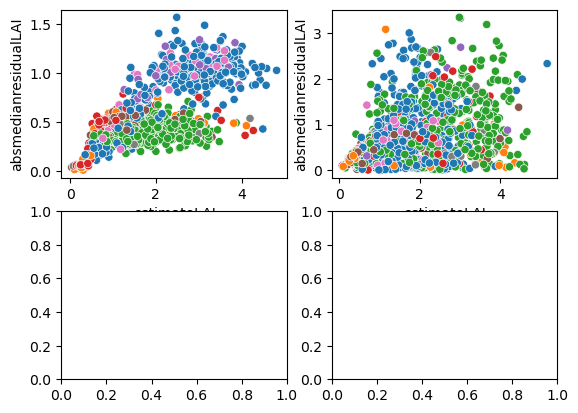

In [1171]:
fig,axs = plt.subplots(2,2)
df = df_groundedeohls_SL2P_FRM_7d_LAI_syn.sample(1000)
sns.scatterplot(df,x='estimateLAI',y='absmedianresidualLAI',hue='NLCD',ax=axs[0,0],legend=False)
df = df_groundedeohls_SL2P_FRM_7d_LAI.sample(1000)

sns.scatterplot(df,x='estimateLAI',y='absmedianresidualLAI',hue='NLCD',ax=axs[0,1],legend=False)


In [1233]:
#redo A and U estimation with the synthetic data
# # # # match within k day interval
time_interval= "7day"
df = pd.merge_asof(df_groundedeohls_SL2P.sort_values('Date'),FRM.sort_values('Date'),on='Date', 
    by='Plot', 
    direction='nearest',
     suffixes = ('','_FRM'),
    tolerance = pd.Timedelta(time_interval)).dropna(subset=['date_FRM'])

#only keep samples with same land cover
df = df[df['NLCD'] == df['NLCD_FRM']]


      
# # # estimate residual for LAI and fAPAR
df['residualLAI'] = df['estimateLAI'] - df['estimateLAI_nobias_noisy']
df['residualfAPAR'] = df['estimatefAPAR'] - df['estimatefAPAR_nobias_noisy']
df['absresidualLAI'] = np.abs(df['residualLAI'])
df['relabsresidualLAI'] = df['absresidualLAI']/ df.groupby(['Plot','date'],as_index=False)['absresidualLAI'].transform('median')
df['residualfAPAR'] = df['estimatefAPAR'] - df['FAPAR']
df['absresidualfAPAR'] = np.abs(df['residualfAPAR'])
df['relabsresidualfAPAR'] = df['absresidualfAPAR']/df.groupby(['Plot','date'],as_index=False)['absresidualfAPAR'].transform('median')

#get theabsolute  median abs residual for each unique plot,date
df['medianresidualLAI'] = (df.groupby(['Plot', 'Date'],as_index=False)['absresidualLAI'].transform('median'))
df['medianresidualfAPAR'] = (df.groupby(['Plot', 'Date'],as_index=False)['absresidualfAPAR'].transform('median'))

df['absmedianresidualLAI'] = np.abs(df['medianresidualLAI'] )
df['absmedianresidualfAPAR'] = np.abs(df['medianresidualfAPAR'])
df['absmedianerrorLAI'] = np.abs(df.groupby(['Plot', 'Date'],as_index=False)['errorLAI'].transform('median'))
df['absmedianerrorfAPAR'] = np.abs(df.groupby(['Plot', 'Date'],as_index=False)['errorfAPAR'].transform('median'))


#get the  median lai and fapar for each unique plot,date
df['medianLAI'] = np.abs(df.groupby(['Plot', 'Date'],as_index=False)['estimateLAI'].transform('median'))
df['medianfAPAR'] = np.abs(df.groupby(['Plot', 'Date'],as_index=False)['estimatefAPAR'].transform('median'))

#get the  median lai and fapar for each unique plot,date
df['medianLAI_ci'] = np.abs(df.groupby(['Plot', 'Date'],as_index=False)['LAI_ci'].transform('median'))
df['medianfAPAR_ci'] = np.abs(df.groupby(['Plot', 'Date'],as_index=False)['FAPAR_ci'].transform('median'))


#get the relative absolute median residuals
df['relabsmedianresidualLAI'] = df['absmedianresidualLAI']/df['medianLAI'] 
df['relabsmedianresidualfAPAR'] = df['absmedianresidualfAPAR']/df['medianfAPAR'] 

df_groundedeohls_SL2P_FRM_7d_fAPAR_syn = df[df.groupby(['Plot', 'date_FRM'],as_index=False)['absmedianresidualfAPAR'].transform('min') == df['absmedianresidualfAPAR']].drop_duplicates("absmedianresidualLAI")
df_groundedeohls_SL2P_FRM_7d_LAI_syn = df[df.groupby(['Plot', 'date_FRM'],as_index=False)['absmedianresidualLAI'].transform('min') == df['absmedianresidualLAI']].drop_duplicates("absmedianresidualLAI")
df_groundedeohls_SL2P_FRM_7d_fAPAR_syn.to_pickle('D:/CEOS/InputData/groundedeohls/df_groundedeohls_SL2P_FRM_7d_fAPAR_syn.pkl')
df_groundedeohls_SL2P_FRM_7d_LAI_syn.to_pickle('D:/CEOS/InputData/groundedeohls/df_groundedeohls_SL2P_FRM_7d_LAI_syn.pkl')


In [1197]:
NLCD_groups, = {'evergreenForest':['evergreenForest'],'deciduousForest':['deciduousForest','mixedForest','woodyWetlands'],'nonForest':['grasslandHerbaceous','shrubScrub','pastureHay','cultivatedCrops']}
validation_results_syn = {}
for NLCD_key,NLCD_list in NLCD_groups,.items():
    validation = {}
    df = df_groundedeohls_SL2P_FRM_1d_LAI_syn
    validation['df_groundedeohls_SL2P_FRM_1d_LAI'] = {}
    df = df.loc[df['NLCD'].isin(NLCD_list)&(df['relabsmedianresidualfAPAR']<10)&(df['relabsmedianresidualLAI']<10) & (df['Uniformity']<4)]
    df['errorerrorLAI'] = np.minimum(0.4,0.2 * df['errorLAI'])
    n,A,U,A_robust,A_ci_upper,A_ci_lower,U_robust,U_ci_upper,U_ci_lower= tools.estimateFRMAPU(df[['estimateLAI','errorLAI']].fillna(0),df['absmedianresidualLAI'].fillna(0),df[['estimateLAI','errorLAI']].fillna(0),df[['errorLAI','errorerrorLAI']].fillna(0.5))
    U_robust_adj  =np.sqrt(np.maximum(0,np.power(U_robust,2)))
    validation['df_groundedeohls_SL2P_FRM_1d_LAI']['samples']={'U_robust_adj':U_robust_adj,'estimate':df['estimateLAI'],'reference':df['LAI'],'estimateCI':df['errorLAI'],'referenceCI':df['medianLAI_ci'],'n':n,'A':A,'U':U,'A_robust':A_robust,'A_ci_upper':A_ci_upper,'A_ci_lower':A_ci_lower,'U_robust':U_robust,'U_ci_upper':U_ci_upper,'U_ci_lower':U_ci_lower}
    
    df = df_groundedeohls_SL2P_FRM_7d_LAI_syn
    validation['df_groundedeohls_SL2P_FRM_7d_LAI'] = {}
    df = df.loc[df['NLCD'].isin(NLCD_list)&(df['relabsmedianresidualfAPAR']<10)&(df['relabsmedianresidualLAI']<10) & (df['Uniformity']<4)]
    df['errorerrorLAI'] = np.minimum(0.4,0.2 * df['errorLAI'])
    n,A,U,A_robust,A_ci_upper,A_ci_lower,U_robust,U_ci_upper,U_ci_lower= tools.estimateFRMAPU(df[['estimateLAI','errorLAI']].fillna(0),df['absmedianresidualLAI'].fillna(0),df[['estimateLAI','errorLAI']].fillna(0),df[['errorLAI','errorerrorLAI']].fillna(0.5))
    U_robust_adj  =np.sqrt(np.maximum(0,np.power(U_robust,2)-np.power(df['medianLAI_ci'],2)))
    validation['df_groundedeohls_SL2P_FRM_7d_LAI']['samples']={'U_robust_adj':U_robust_adj,'estimate':df['estimateLAI'],'reference':df['LAI'],'estimateCI':df['errorLAI'],'referenceCI':df['medianLAI_ci'],'n':n,'A':A,'U':U,'A_robust':A_robust,'A_ci_upper':A_ci_upper,'A_ci_lower':A_ci_lower,'U_robust':U_robust,'U_ci_upper':U_ci_upper,'U_ci_lower':U_ci_lower}
    
    df = df_groundedeohls_SL2P_FRM_1d_LAI_syn
    validation['df_groundedeohls_SL2P_FRM_1d_LAI_uniform'] = {}
    df = df.loc[df['NLCD'].isin(NLCD_list)&(df['relabsmedianresidualfAPAR']<10)&(df['relabsmedianresidualLAI']<10) & (df['Uniformity']<3)]
    df['errorerrorLAI'] = np.minimum(0.4,0.2 * df['errorLAI'])
    n,A,U,A_robust,A_ci_upper,A_ci_lower,U_robust,U_ci_upper,U_ci_lower= tools.estimateFRMAPU(df[['estimateLAI','errorLAI']].fillna(0),df['absmedianresidualLAI'].fillna(0),df[['estimateLAI','errorLAI']].fillna(0),df[['errorLAI','errorerrorLAI']].fillna(0.5))
    U_robust_adj  =np.sqrt(np.maximum(0,np.power(U_robust,2)))
    validation['df_groundedeohls_SL2P_FRM_1d_LAI_uniform']['samples']={'U_robust_adj':U_robust_adj,'estimate':df['estimateLAI'],'reference':df['LAI'],'estimateCI':df['errorLAI'],'referenceCI':df['LAI_ci'],'n':n,'A':A,'U':U,'A_robust':A_robust,'A_ci_upper':A_ci_upper,'A_ci_lower':A_ci_lower,'U_robust':U_robust,'U_ci_upper':U_ci_upper,'U_ci_lower':U_ci_lower}
    
    df = df_groundedeohls_SL2P_FRM_7d_LAI_syn
    validation['df_groundedeohls_SL2P_FRM_7d_LAI_uniform'] = {}
    df = df.loc[df['NLCD'].isin(NLCD_list)&(df['relabsmedianresidualfAPAR']<10)&(df['relabsmedianresidualLAI']<10) & (df['Uniformity']<3)]
    df['errorerrorLAI'] = np.minimum(0.4,0.2 * df['errorLAI'])
    n,A,U,A_robust,A_ci_upper,A_ci_lower,U_robust,U_ci_upper,U_ci_lower= tools.estimateFRMAPU(df[['estimateLAI','errorLAI']].fillna(0),df['absmedianresidualLAI'].fillna(0),df[['estimateLAI','errorLAI']].fillna(0),df[['errorLAI','errorerrorLAI']].fillna(0.5))
    U_robust_adj  =np.sqrt(np.maximum(0,np.power(U_robust,2)))
    validation['df_groundedeohls_SL2P_FRM_7d_LAI_uniform']['samples']={'estimate':df['estimateLAI'],'reference':df['LAI'],'estimateCI':df['errorLAI'],'referenceCI':df['LAI_ci'],'n':n,'A':A,'U':U,'A_robust':A_robust,'A_ci_upper':A_ci_upper,'A_ci_lower':A_ci_lower,'U_robust':U_robust,'U_ci_upper':U_ci_upper,'U_ci_lower':U_ci_lower}
    
    df = df_groundedeohls_SL2P_FRM_1d_fAPAR_syn
    validation['df_groundedeohls_SL2P_FRM_1d_fAPAR'] = {}
    df = df.loc[df['NLCD'].isin(NLCD_list)&(df['relabsmedianresidualfAPAR']<10)&(df['relabsmedianresidualfAPAR']<10) & (df['Uniformity']<4)]
    df['errorerrorfAPAR'] = np.minimum(0.04,0.2 * df['errorfAPAR'])
    n,A,U,A_robust,A_ci_upper,A_ci_lower,U_robust,U_ci_upper,U_ci_lower= tools.estimateFRMAPU(df[['estimatefAPAR','errorfAPAR']].fillna(0),df['absmedianresidualfAPAR'].fillna(0),df[['estimatefAPAR','errorfAPAR']].fillna(0),df[['errorfAPAR','errorerrorfAPAR']].fillna(0.5))
    U_robust_adj  =np.sqrt(np.maximum(0,np.power(U_robust,2)))
    validation['df_groundedeohls_SL2P_FRM_1d_fAPAR']['samples']={'U_robust_adj':U_robust_adj,'estimate':df['estimatefAPAR'],'reference':df['FAPAR'],'estimateCI':df['errorfAPAR'],'referenceCI':df['medianfAPAR_ci'],'n':n,'A':A,'U':U,'A_robust':A_robust,'A_ci_upper':A_ci_upper,'A_ci_lower':A_ci_lower,'U_robust':U_robust,'U_ci_upper':U_ci_upper,'U_ci_lower':U_ci_lower}
    
    df = df_groundedeohls_SL2P_FRM_7d_fAPAR_syn
    validation['df_groundedeohls_SL2P_FRM_7d_fAPAR'] = {}
    df = df.loc[df['NLCD'].isin(NLCD_list)&(df['relabsmedianresidualfAPAR']<10)&(df['relabsmedianresidualfAPAR']<10) & (df['Uniformity']<4)]
    df['errorerrorfAPAR'] = np.minimum(0.04,0.2 * df['errorfAPAR'])
    n,A,U,A_robust,A_ci_upper,A_ci_lower,U_robust,U_ci_upper,U_ci_lower= tools.estimateFRMAPU(df[['estimatefAPAR','errorfAPAR']].fillna(0),df['absmedianresidualfAPAR'].fillna(0),df[['estimatefAPAR','errorfAPAR']].fillna(0),df[['errorfAPAR','errorerrorfAPAR']].fillna(0.5))
    U_robust_adj  =np.sqrt(np.maximum(0,np.power(U_robust,2)-np.power(df['medianfAPAR_ci'],2)))
    validation['df_groundedeohls_SL2P_FRM_7d_fAPAR']['samples']={'U_robust_adj':U_robust_adj,'estimate':df['estimatefAPAR'],'reference':df['FAPAR'],'estimateCI':df['errorfAPAR'],'referenceCI':df['medianfAPAR_ci'],'n':n,'A':A,'U':U,'A_robust':A_robust,'A_ci_upper':A_ci_upper,'A_ci_lower':A_ci_lower,'U_robust':U_robust,'U_ci_upper':U_ci_upper,'U_ci_lower':U_ci_lower}
    
    df = df_groundedeohls_SL2P_FRM_1d_fAPAR_syn
    validation['df_groundedeohls_SL2P_FRM_1d_fAPAR_uniform'] = {}
    df = df.loc[df['NLCD'].isin(NLCD_list)&(df['relabsmedianresidualfAPAR']<10)&(df['relabsmedianresidualfAPAR']<10) & (df['Uniformity']<3)]
    df['errorerrorfAPAR'] = np.minimum(0.04,0.2 * df['errorfAPAR'])
    n,A,U,A_robust,A_ci_upper,A_ci_lower,U_robust,U_ci_upper,U_ci_lower= tools.estimateFRMAPU(df[['estimatefAPAR','errorfAPAR']].fillna(0),df['medianresidualfAPAR'].fillna(0),df[['estimatefAPAR','errorfAPAR']].fillna(0),df[['errorfAPAR','errorerrorfAPAR']].fillna(0.5))
    U_robust_adj  =np.sqrt(np.maximum(0,np.power(U_robust,2)))
    validation['df_groundedeohls_SL2P_FRM_1d_fAPAR_uniform']['samples']={'U_robust_adj':U_robust_adj,'estimate':df['estimatefAPAR'],'reference':df['FAPAR'],'estimateCI':df['errorfAPAR'],'referenceCI':df['medianfAPAR_ci'],'n':n,'A':A,'U':U,'A_robust':A_robust,'A_ci_upper':A_ci_upper,'A_ci_lower':A_ci_lower,'U_robust':U_robust,'U_ci_upper':U_ci_upper,'U_ci_lower':U_ci_lower}
    
    df = df_groundedeohls_SL2P_FRM_7d_fAPAR_syn
    validation['df_groundedeohls_SL2P_FRM_7d_fAPAR_uniform'] = {}
    df = df.loc[df['NLCD'].isin(NLCD_list)&(df['relabsmedianresidualfAPAR']<10)&(df['relabsmedianresidualfAPAR']<10) & (df['Uniformity']<3)]
    df['errorerrorfAPAR'] = np.minimum(0.04,0.2 * df['errorfAPAR'])
    n,A,U,A_robust,A_ci_upper,A_ci_lower,U_robust,U_ci_upper,U_ci_lower= tools.estimateFRMAPU(df[['estimatefAPAR','errorfAPAR']].fillna(0),df['absmedianresidualfAPAR'].fillna(0),df[['estimatefAPAR','errorfAPAR']].fillna(0),df[['errorfAPAR','errorerrorfAPAR']].fillna(0.5))
    U_robust_adj  =np.sqrt(np.maximum(0,np.power(U_robust,2)))
    validation['df_groundedeohls_SL2P_FRM_7d_fAPAR_uniform']['samples']={'U_robust_adj':U_robust_adj,'estimate':df['estimatefAPAR'],'reference':df['FAPAR'],'estimateCI':df['errorfAPAR'],'referenceCI':df['medianfAPAR_ci'],'n':n,'A':A,'U':U,'A_robust':A_robust,'A_ci_upper':A_ci_upper,'A_ci_lower':A_ci_lower,'U_robust':U_robust,'U_ci_upper':U_ci_upper,'U_ci_lower':U_ci_lower}
    
    validation_results_syn[NLCD_key]=validation


In [1278]:
df = df_groundedeohls_SL2P_FRM_1d_LAI_syn
df = df_groundedeohls.loc[df_groundedeohls['sensor']=='S2']

df['RCCI'] = ((df['B5'] - df['B2'])/(df['B6']-df['B5']))*(df['B6']/df['B2'])

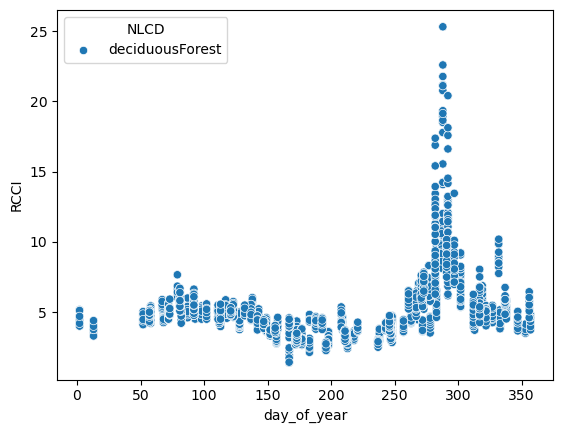

In [1288]:
ax=sns.scatterplot(df.loc[df['Plot']=='HARV_002'],x='day_of_year',y='RCCI',hue='NLCD')


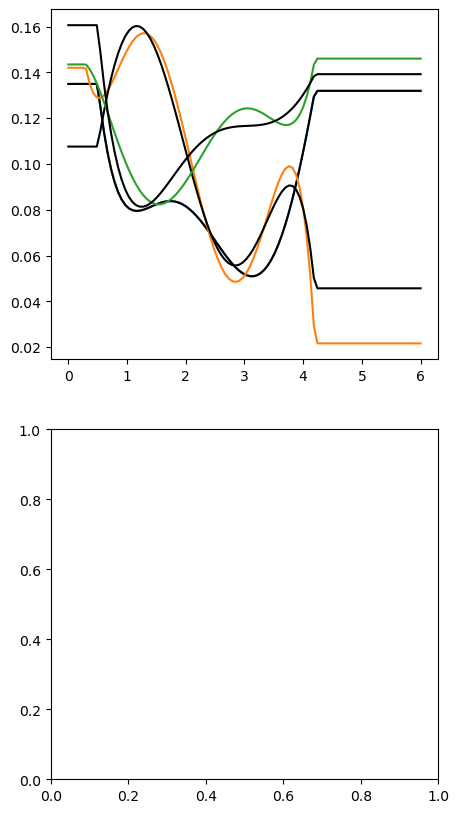

In [1235]:

fig,axs =  plt.subplots(2,1,figsize=(5,10))
#fit bias correction to measured 1d data for synthetic data generation
df = pd.DataFrame(validation_results_syn['evergreenForest']['df_groundedeohls_SL2P_FRM_7d_LAI']['samples'])
x = df['estimate']
y = df['U_robust_adj'] 
fit = tools.fit_U(df,5,0.5,4.2)
validation_results['evergreenForest']['df_groundedeohls_SL2P_FRM_7d_LAI']['fit_U'] = fit
# axs[0].plot(x,y,'.')
axs[0].plot(np.linspace(0,6,100), tools.pred(np.linspace(0,6,100),fit))
df = pd.DataFrame(validation_results_syn['evergreenForest']['df_groundedeohls_SL2P_FRM_7d_LAI']['samples'])
x = df['estimate']
y = df['U_robust_adj'] 
fit = tools.fit_U(df,5,0.5,4.2)
validation_results_syn['evergreenForest']['df_groundedeohls_SL2P_FRM_7d_LAI']['fit_U'] = fit
axs[0].plot(np.linspace(0,6,100), tools.pred(np.linspace(0,6,100),fit),'k')

#fit bias correction to measured 1d data for synthetic data generation
df = pd.DataFrame(validation_results_syn['deciduousForest']['df_groundedeohls_SL2P_FRM_7d_LAI']['samples'])
x = df['estimate']
y = df['U_robust_adj'] 
fit = tools.fit_U(df,5,0.3,4.2)
validation_results['deciduousForest']['df_groundedeohls_SL2P_FRM_7d_LAI']['fit_U'] = fit
# axs[0].plot(x,y,'.')
axs[0].plot(np.linspace(0,6,100), tools.pred(np.linspace(0,6,100),fit))
df = pd.DataFrame(validation_results_syn['deciduousForest']['df_groundedeohls_SL2P_FRM_7d_LAI']['samples'])
x = df['estimate']
y = df['U_robust_adj'] 
fit = tools.fit_U(df,5,0.5,4.2)
validation_results_syn['deciduousForest']['df_groundedeohls_SL2P_FRM_7d_LAI']['fit_U'] = fit
axs[0].plot(np.linspace(0,6,100), tools.pred(np.linspace(0,6,100),fit),'k')

#fit bias correction to measured 1d data for synthetic data generation
df = pd.DataFrame(validation_results_syn['nonForest']['df_groundedeohls_SL2P_FRM_7d_LAI']['samples'])
x = df['estimate']
y = df['U_robust_adj'] 
fit = tools.fit_U(df,5,0.3,4.2)
validation_results['nonForest']['df_groundedeohls_SL2P_FRM_7d_LAI']['fit_U'] = fit
# axs[0].plot(x,y,'k.')
axs[0].plot(np.linspace(0,6,100), tools.pred(np.linspace(0,6,100),fit))
df = pd.DataFrame(validation_results_syn['nonForest']['df_groundedeohls_SL2P_FRM_7d_LAI']['samples'])
x = df['estimate']
y = df['U_robust_adj'] 
fit = tools.fit_U(df,5,0.5,4.2)
validation_results_syn['nonForest']['df_groundedeohls_SL2P_FRM_7d_LAI']['fit_U'] = fit
axs[0].plot(np.linspace(0,6,100), tools.pred(np.linspace(0,6,100),fit),'k')

# #fit bias correction to measured 1d data for synthetic data generation
# df = pd.DataFrame(validation_results['evergreenForest']['df_groundedeohls_SL2P_FRM_7d_fAPAR']['samples'])
# x = df['estimate']
# y = df['U_robust_adj'] 
# fit = tools.fit_U(df,9,0.06,0.8)
# validation_results['evergreenForest']['df_groundedeohls_SL2P_FRM_7d_fAPAR']['fit_U'] = fit
# axs[1].plot(x,y,'.')
# axs[1].plot(np.linspace(0,.9,100), tools.pred_spline(np.linspace(0,.9,100),fit))

# #fit bias correction to measured 1d data for synthetic data generation
# df = pd.DataFrame(validation_results['deciduousForest']['df_groundedeohls_SL2P_FRM_7d_fAPAR']['samples'])
# x = df['estimate']
# y = df['U_robust_adj'] 
# fit = tools.fit_U(df,9,0.1,0.8)
# validation_results['deciduousForest']['df_groundedeohls_SL2P_FRM_7d_fAPAR']['fit_U'] = fit
# axs[1].plot(x,y,'.')
# axs[1].plot(np.linspace(0,.9,100), tools.pred_spline(np.linspace(0,.9,100),fit))

# #fit bias correction to measured 1d data for synthetic data generation
# df = pd.DataFrame(validation_results['nonForest']['df_groundedeohls_SL2P_FRM_7d_fAPAR']['samples'])
# x = df['estimate']
# y = df['U_robust_adj'] 
# fit = tools.fit_U(df,9,0.12,0.8)
# validation_results['nonForest']['df_groundedeohls_SL2P_FRM_7d_fAPAR']['fit_U'] = fit
# axs[1].plot(x,y,'.')
# axs[1].plot(np.linspace(0,.9,100), tools.pred_spline(np.linspace(0,.9,100),fit))

<ErrorbarContainer object of 3 artists>

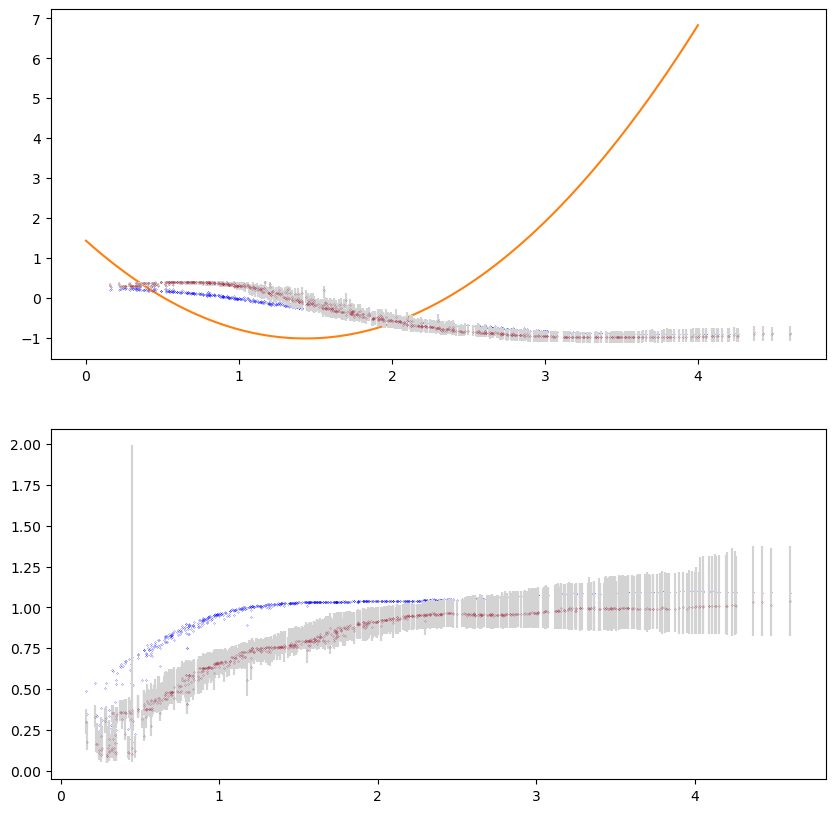

In [762]:
fix,axs = plt.subplots(2,1,figsize=(10,10))
results = validation['df_groundedeohls_SL2P_FRM_1d_LAI']
axs[0].plot(results['estimate'],results['A'],'b.', markersize=0.2)
yerr =[ results['A_robust'] - results['A_ci_lower'], results['A_ci_upper'] - results['A_robust']]
axs[0].errorbar(results['estimate'],results['A_robust'], yerr=yerr, markersize=0.2, fmt='.', ecolor='lightgrey', capsize=0)
         
axs[1].plot(results['estimate'],results['U'],'b.', markersize=0.2)
yerr =[ results['U_robust'] - results['U_ci_lower'], results['U_ci_upper'] - results['U_robust']]
axs[1].errorbar(results['estimate'],results['U_robust']*1.35, yerr=yerr, markersize=0.2, fmt='.', ecolor='lightgrey', capsize=0)

results2 = validation['df_groundedeohls_SL2P_FRM_1d_LAI_uniform']
axs[0].plot(results['estimate'],results['A'],'b.', markersize=0.2)
yerr =[ results['A_robust'] - results['A_ci_lower'], results['A_ci_upper'] - results['A_robust']]
axs[0].errorbar(results['estimate'],results['A_robust'], yerr=yerr, markersize=0.2, fmt='r.', ecolor='lightgrey', capsize=0)

axs[1].plot(results['estimate'],results['U'],'b.', markersize=0.2)
yerr =[ results['U_robust'] - results['U_ci_lower'], results['U_ci_upper'] - results['U_robust']]
axs[1].errorbar(results['estimate'],results['U_robust']*1.35, yerr=yerr, markersize=0.2, fmt='r.', ecolor='lightgrey', capsize=0)


<ErrorbarContainer object of 3 artists>

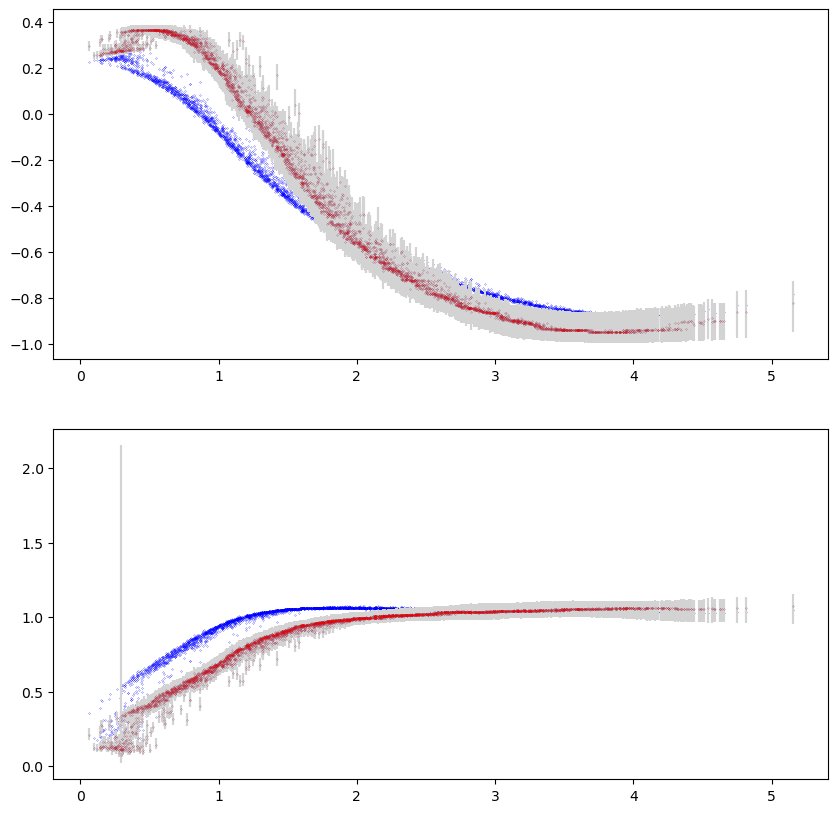

In [741]:
fix,axs = plt.subplots(2,1,figsize=(10,10))
results = validation['df_groundedeohls_SL2P_FRM_7d_LAI']
axs[0].plot(results['estimate'],results['A'],'b.', markersize=0.2)
yerr =[ results['A_robust'] - results['A_ci_lower'], results['A_ci_upper'] - results['A_robust']]
axs[0].errorbar(results['estimate'],results['A_robust'], yerr=yerr, markersize=0.2, fmt='.', ecolor='lightgrey', capsize=0)

axs[1].plot(results['estimate'],results['U'],'b.', markersize=0.2)
yerr =[ results['U_robust'] - results['U_ci_lower'], results['U_ci_upper'] - results['U_robust']]
axs[1].errorbar(results['estimate'],results['U_robust']*1.35, yerr=yerr, markersize=0.2, fmt='.', ecolor='lightgrey', capsize=0)

results2 = validation['df_groundedeohls_SL2P_FRM_7d_LAI_uniform']
axs[0].plot(results['estimate'],results['A'],'b.', markersize=0.2)
yerr =[ results['A_robust'] - results['A_ci_lower'], results['A_ci_upper'] - results['A_robust']]
axs[0].errorbar(results['estimate'],results['A_robust'], yerr=yerr, markersize=0.2, fmt='r.', ecolor='lightgrey', capsize=0)

axs[1].plot(results['estimate'],results['U'],'b.', markersize=0.2)
yerr =[ results['U_robust'] - results['U_ci_lower'], results['U_ci_upper'] - results['U_robust']]
axs[1].errorbar(results['estimate'],results['U_robust']*1.35, yerr=yerr, markersize=0.2, fmt='r.', ecolor='lightgrey', capsize=0)


<ErrorbarContainer object of 3 artists>

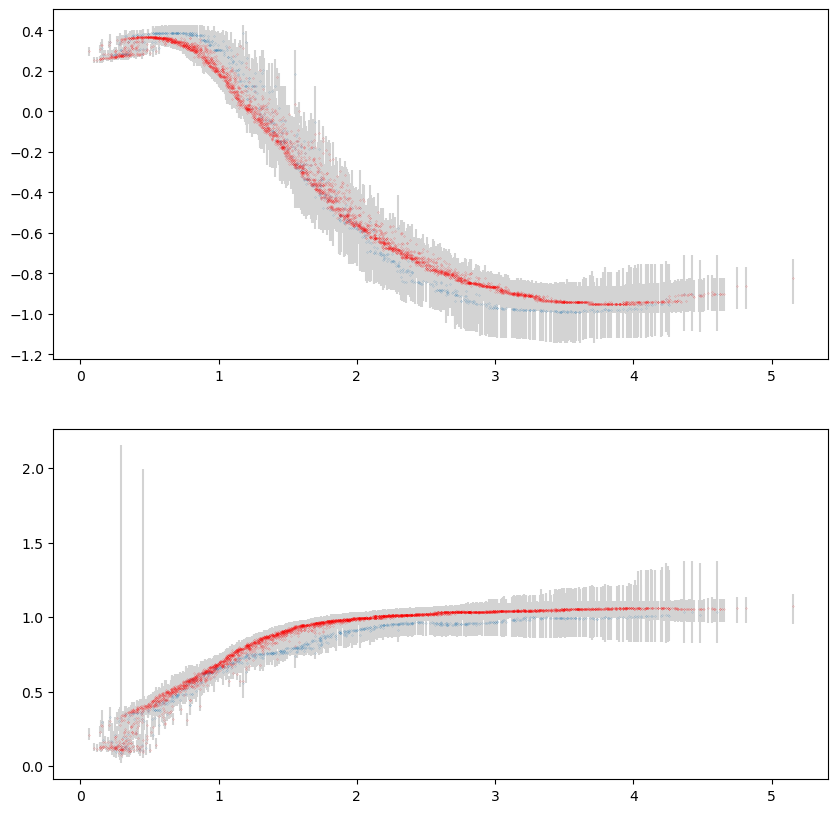

In [744]:
fix,axs = plt.subplots(2,1,figsize=(10,10))
results = validation['df_groundedeohls_SL2P_FRM_1d_LAI']
# axs[0].plot(results['estimate'],results['A'],'.')
yerr =[ results['A_robust'] - results['A_ci_lower'], results['A_ci_upper'] - results['A_robust']]
axs[0].errorbar(results['estimate'],results['A_robust'], yerr=yerr, markersize=0.2, fmt='.', ecolor='lightgrey', capsize=0)

# axs[1].plot(results['estimate'],results['U'],'.')
yerr =[ results['U_robust'] - results['U_ci_lower'], results['U_ci_upper'] - results['U_robust']]
axs[1].errorbar(results['estimate'],results['U_robust']*1.35, yerr=yerr, markersize=0.2, fmt='.', ecolor='lightgrey', capsize=0)

results = validation['df_groundedeohls_SL2P_FRM_7d_LAI']
# axs[0].plot(results['estimate'],results['A'],'.')
yerr =[ results['A_robust'] - results['A_ci_lower'], results['A_ci_upper'] - results['A_robust']]
axs[0].errorbar(results['estimate'],results['A_robust'], yerr=yerr, markersize=0.2, fmt='r.', ecolor='lightgrey', capsize=0)

# axs[1].plot(results['estimate'],results['U'],'.')
yerr =[ results['U_robust'] - results['U_ci_lower'], results['U_ci_upper'] - results['U_robust']]
axs[1].errorbar(results['estimate'],results['U_robust']*1.35, yerr=yerr, markersize=0.2, fmt='r.', ecolor='lightgrey', capsize=0)


In [ ]:
fix,axs = plt.subplots(2,1,figsize=(10,10))
results = validation['df_groundedeohls_SL2P_FRM_1d_fAPAR']
axs[0].plot(results['estimate'],results['A'],'b.', markersize=0.2)
yerr =[ results['A_robust'] - results['A_ci_lower'], results['A_ci_upper'] - results['A_robust']]
axs[0].errorbar(results['estimate'],results['A_robust'], yerr=yerr, markersize=0.2, fmt='.', ecolor='lightgrey', capsize=0)

axs[1].plot(results['estimate'],results['U'],'b.', markersize=0.2)
yerr =[ results['U_robust'] - results['U_ci_lower'], results['U_ci_upper'] - results['U_robust']]
axs[1].errorbar(results['estimate'],results['U_robust']*1.35, yerr=yerr, markersize=0.2, fmt='.', ecolor='lightgrey', capsize=0)

results2 = validation['df_groundedeohls_SL2P_FRM_1d_fAPAR_uniform']
axs[0].plot(results['estimate'],results['A'],'b.', markersize=0.2)
yerr =[ results['A_robust'] - results['A_ci_lower'], results['A_ci_upper'] - results['A_robust']]
axs[0].errorbar(results['estimate'],results['A_robust'], yerr=yerr, markersize=0.2, fmt='r.', ecolor='lightgrey', capsize=0)

axs[1].plot(results['estimate'],results['U'],'b.', markersize=0.2)
yerr =[ results['U_robust'] - results['U_ci_lower'], results['U_ci_upper'] - results['U_robust']]
axs[1].errorbar(results['estimate'],results['U_robust']*1.35, yerr=yerr, markersize=0.2, fmt='r.', ecolor='lightgrey', capsize=0)


In [ ]:
fix,axs = plt.subplots(2,1,figsize=(10,10))
results = validation['df_groundedeohls_SL2P_FRM_7d_fAPAR']
axs[0].plot(results['estimate'],results['A'],'b.', markersize=0.2)
yerr =[ results['A_robust'] - results['A_ci_lower'], results['A_ci_upper'] - results['A_robust']]
axs[0].errorbar(results['estimate'],results['A_robust'], yerr=yerr, markersize=0.2, fmt='.', ecolor='lightgrey', capsize=0)

axs[1].plot(results['estimate'],results['U'],'b.', markersize=0.2)
yerr =[ results['U_robust'] - results['U_ci_lower'], results['U_ci_upper'] - results['U_robust']]
axs[1].errorbar(results['estimate'],results['U_robust']*1.35, yerr=yerr, markersize=0.2, fmt='.', ecolor='lightgrey', capsize=0)

results2 = validation['df_groundedeohls_SL2P_FRM_7d_fAPAR_uniform']
axs[0].plot(results['estimate'],results['A'],'b.', markersize=0.2)
yerr =[ results['A_robust'] - results['A_ci_lower'], results['A_ci_upper'] - results['A_robust']]
axs[0].errorbar(results['estimate'],results['A_robust'], yerr=yerr, markersize=0.2, fmt='r.', ecolor='lightgrey', capsize=0)

axs[1].plot(results['estimate'],results['U'],'b.', markersize=0.2)
yerr =[ results['U_robust'] - results['U_ci_lower'], results['U_ci_upper'] - results['U_robust']]
axs[1].errorbar(results['estimate'],results['U_robust']*1.35, yerr=yerr, markersize=0.2, fmt='r.', ecolor='lightgrey', capsize=0)


In [ ]:
fix,axs = plt.subplots(2,1,figsize=(10,10))
results = validation['df_groundedeohls_SL2P_FRM_1d_fAPAR']
# axs[0].plot(results['estimate'],results['A'],'.')
yerr =[ results['A_robust'] - results['A_ci_lower'], results['A_ci_upper'] - results['A_robust']]
axs[0].errorbar(results['estimate'],results['A_robust'], yerr=yerr, markersize=0.2, fmt='.', ecolor='lightgrey', capsize=0)

# axs[1].plot(results['estimate'],results['U'],'.')
yerr =[ results['U_robust'] - results['U_ci_lower'], results['U_ci_upper'] - results['U_robust']]
axs[1].errorbar(results['estimate'],results['U_robust']*1.35, yerr=yerr, markersize=0.2, fmt='.', ecolor='lightgrey', capsize=0)

results = validation['df_groundedeohls_SL2P_FRM_7d_fAPAR']
# axs[0].plot(results['estimate'],results['A'],'.')
yerr =[ results['A_robust'] - results['A_ci_lower'], results['A_ci_upper'] - results['A_robust']]
axs[0].errorbar(results['estimate'],results['A_robust'], yerr=yerr, markersize=0.2, fmt='r.', ecolor='lightgrey', capsize=0)

# axs[1].plot(results['estimate'],results['U'],'.')
yerr =[ results['U_robust'] - results['U_ci_lower'], results['U_ci_upper'] - results['U_robust']]
axs[1].errorbar(results['estimate'],results['U_robust']*1.35, yerr=yerr, markersize=0.2, fmt='r.', ecolor='lightgrey', capsize=0)


In [306]:
# # # match within k day interval
time_interval= "7day"
df = pd.merge_asof(df_groundedeohls_SL2P.sort_values('Date'),FRM.sort_values('Date'),on='Date', 
    by='Plot', 
    direction='nearest',
     suffixes = ('','_FRM'),
    tolerance = pd.Timedelta(time_interval)).dropna(subset=['date_FRM'])

# # estimate residual for LAI and fAPAR
df['residualLAI'] = df['estimateLAI'] - df['LAI']
df['residualfAPAR'] = df['estimatefAPAR'] - df['FAPAR']
df['absresidualLAI'] = np.abs(df['residualLAI'])
df['relabsresidualLAI'] = df['absresidualLAI']/ df.groupby(['Plot','date'])['absresidualLAI'].transform('median')
df['residualfAPAR'] = df['estimatefAPAR'] - df['FAPAR']
df['absresidualfAPAR'] = np.abs(df['residualfAPAR'])
df['relabsresidualfAPAR'] = df['absresidualfAPAR']/df.groupby(['Plot','date'])['absresidualfAPAR'].transform('median')
df_groundedeohls_SL2P_FRM_7d = df

# fig,axs = plt.subplots(2,1,figsize=(8,16))
# df = df_groundedeohls_SL2P_FRM_1d
# df = df.loc[df['NLCD'].isin(['evergreenForest','deciduousForest','shrubScrub'])&(df_groundedeohls_SL2P_FRM_1d['relabsresidualfAPAR']<10)&(df_groundedeohls_SL2P_FRM_1d['relabsresidualLAI']<10) & (df_groundedeohls_SL2P_FRM_1d['Uniformity']<4)]

# sns.histplot(df,x='relabsresidualLAI',hue='NLCD',kde=True,stat='probability',alpha=0,element="poly",fill=False,ax=axs[0],legend=False,common_norm=False,kde_kws={'bw_adjust':1.0})


# sns.histplot(df,x='relabsresidualfAPAR',hue='NLCD',kde=True,stat='probability',alpha=0,element="poly",fill=False,ax=axs[1],common_norm=False,kde_kws={'bw_adjust': 1.0})
# # 2. Move the legend below the plot
# # loc="upper center": The point of the legend box we are anchoring
# # bbox_to_anchor=(0.5, -0.2): (x, y) coordinates. 0.5 is horizontal center, 
# # -0.2 is below the x-axis.
# sns.move_legend(axs[1], "upper center", bbox_to_anchor=(0.5, -0.3), ncol=3, title=None, frameon=False)

# # 3. Adjust layout to make room for the legend
# plt.tight_layout()
# plt.show()


In [ ]:
#estimate bias for purpose of making synthetic datasets
popt, pcov = curve_fit(exponential_func, xdata, ydata, p0=(2., 1.))


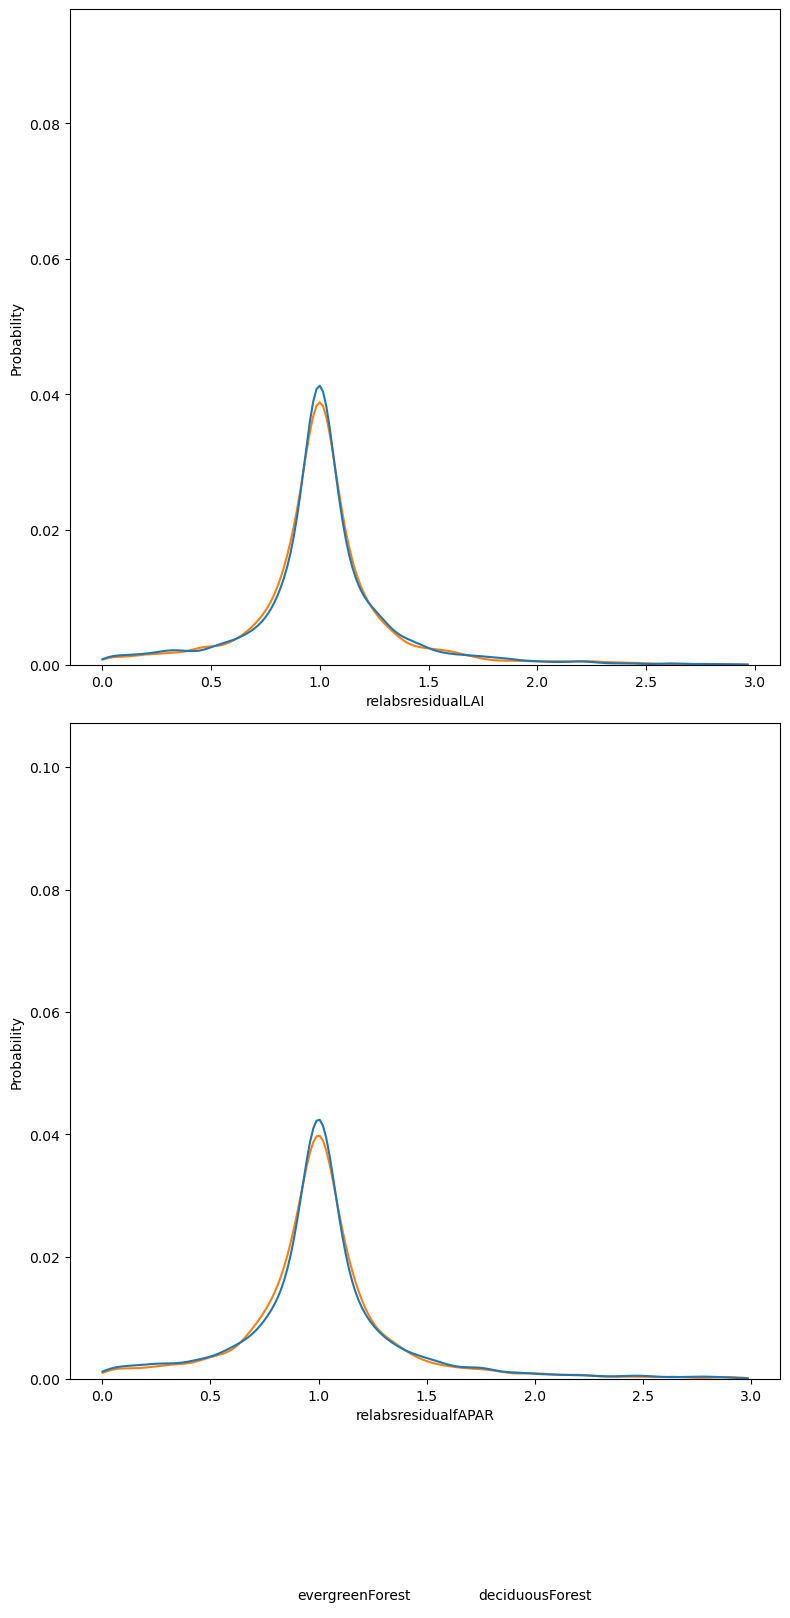

In [298]:
# match within k day interval
# time_interval= "7day"
# df = pd.merge_asof(df_groundedeohls_SL2P.sort_values('Date'),FRM.sort_values('Date'),on='Date', 
#     by='Plot', 
#     direction='nearest',
#      suffixes = ('','_FRM'),
#     tolerance = pd.Timedelta(time_interval)).dropna(subset=['date_FRM'])

# # # estimate residual for LAI and fAPAR
# df['residualLAI'] = df['estimateLAI'] - df['LAI']
# df['residualfAPAR'] = df['estimatefAPAR'] - df['FAPAR']
# df['absresidualLAI'] = np.abs(df['residualLAI'])
# df['relabsresidualLAI'] = df['absresidualLAI']/ df.groupby(['Plot','date'])['absresidualLAI'].transform('median')
# df['residualfAPAR'] = df['estimatefAPAR'] - df['FAPAR']
# df['absresidualfAPAR'] = np.abs(df['residualfAPAR'])
# df['relabsresidualfAPAR'] = df['absresidualfAPAR']/df.groupby(['Plot','date'])['absresidualfAPAR'].transform('median')
# df_groundedeohls_SL2P_FRM_7d = df.loc[df['NLCD'].isin(['evergreenForest','deciduousForest'])]

fig,axs = plt.subplots(2,1,figsize=(8,16))
df = df_groundedeohls_SL2P_FRM_7d.loc[df_groundedeohls_SL2P_FRM_7d['relabsresidualLAI']<3]

sns.histplot(df,x='relabsresidualLAI',hue='NLCD',kde=True,stat='probability',alpha=0,element="poly",fill=False,ax=axs[0],legend=False,common_norm=False,kde_kws={'bw_adjust':1.0})
df = df_groundedeohls_SL2P_FRM_1d.loc[df_groundedeohls_SL2P_FRM_1d['relabsresidualfAPAR']<3]


sns.histplot(df,x='relabsresidualfAPAR',hue='NLCD',kde=True,stat='probability',alpha=0,element="poly",fill=False,ax=axs[1],common_norm=False,kde_kws={'bw_adjust': 1.0})
# 2. Move the legend below the plot
# loc="upper center": The point of the legend box we are anchoring
# bbox_to_anchor=(0.5, -0.2): (x, y) coordinates. 0.5 is horizontal center, 
# -0.2 is below the x-axis.
sns.move_legend(axs[1], "upper center", bbox_to_anchor=(0.5, -0.3), ncol=3, title=None, frameon=False)

# 3. Adjust layout to make room for the legend
plt.tight_layout()
plt.show()

In [800]:
df = df_groundedeohls_SL2P_FRM_7d_LAI

# # Define your quantile (e.g., 0.25 for the first quartile)
# q = 0.50

# # 1. Calculate the q-quantile for each group (plot, date) 
# # and broadcast it back to the original dataframe shape
# thresholds = df.groupby(['Plot', 'LAI'])['residualLAI'].transform(lambda x: np.abs(x).quantile(q))

# # 2. Filter the original dataframe based on this threshold
# filtered_df = df[np.abs(df['residualLAI']) < thresholds]
# print(filtered_df.shape)

# ax=sns.scatterplot(filtered_df.groupby(['Plot','Date'])[['estimatefAPAR','LAI','NLCD']].agg(
#     {'LAI':'mean','estimateLAI':'mean','NLCD':'first'}),x='estimateLAI',y='LAI',hue='NLCD')

(444, 133)


KeyError: "Column(s) ['estimateLAI'] do not exist"

In [ ]:
df = df_groundedeoHLS_SL2P_FRM.loc[df_groundedeoHLS_SL2P_FRM['Uniformity']<3]

# Define your quantile (e.g., 0.25 for the first quartile)
q = 0.50

# 1. Calculate the q-quantile for each group (plot, date) 
# and broadcast it back to the original dataframe shape
thresholds = df.groupby(['Plot', 'LAI'])['residualLAI'].transform(lambda x: np.abs(x).quantile(q))

# 2. Filter the original dataframe based on this threshold
filtered_df = df[np.abs(df['residualLAI']) < thresholds]

(np.float64(16436.0), np.float64(20453.0))

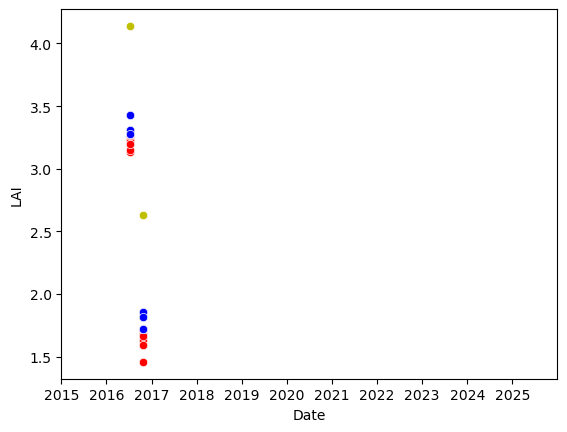

In [187]:
#visualize product estimates for an esu
df = df_groundedeoHLS_SL2P_FRM
plot_names = df['Plot'].unique()
plotnum = 10
start_date = datetime.datetime(2015, 1, 1)
end_date = datetime.datetime(2025, 12, 31)

ax=sns.scatterplot(df.loc[df['Plot']==plot_names[plotnum]],x='Date',y='LAI',color='y')
ax=sns.scatterplot(df.loc[df['Plot']==plot_names[plotnum]],x='Date',y='estimateLAI',color='r')
ax=sns.scatterplot(filtered_df.loc[df['Plot']==plot_names[plotnum]],x='Date',y='estimateLAI',color='b')

ax.set_xlim(start_date,end_date)
# ax.set_ylim(0.8,1.2)

In [157]:
# Group by 'plot' and 'date', then find the index of the minimum 'residuals'
idx = df_groundedeoHLS_SL2P_FRM.groupby(['plot', 'date'])['residualLAI'].idxmin()

# Select the rows using those indices
result = df_groundedeoHLS_SL2P_FRM.loc[idx]

KeyError: 'plot'

KeyboardInterrupt: 

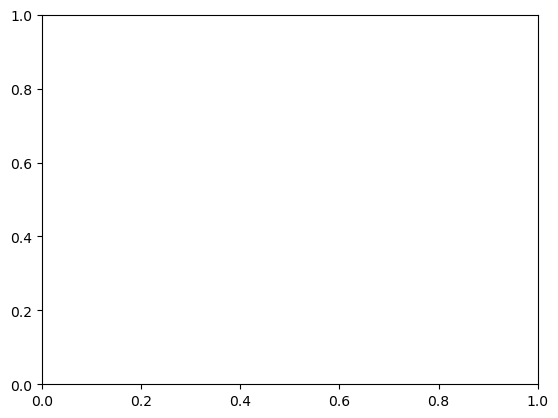

In [154]:
ax=sns.kdeplot(df_groundedeoHLS_SL2P_FRM,x='estimateLAI',y='LAI',hue='sensor')

(np.float64(18262.0), np.float64(18627.0))

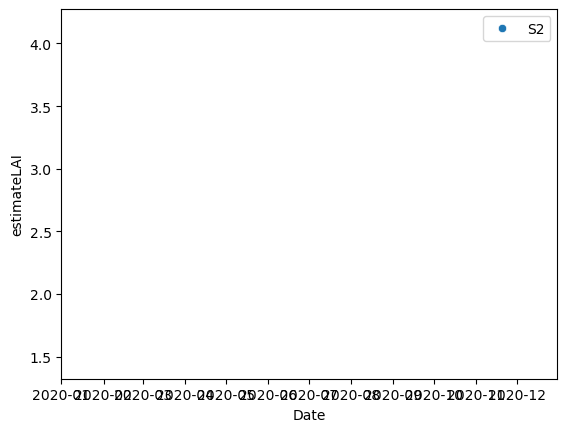

# 2.5 Synthetic Reference Values

In [98]:
df_groundedeohls_SL2P_ref = df_groundedeohls_SL2P.groupby(['Plot','Date'])[['estimateLAI','errorLAI','estimatefAPAR','errorfAPAR','year','day_of_year']].median().reset_index()

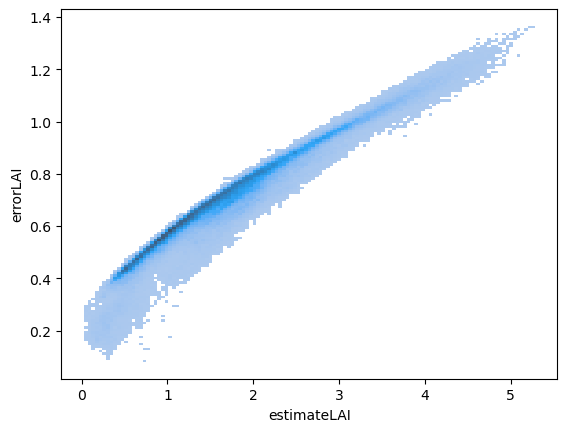

In [104]:
#visualize product estimates for an esu
df = df_groundedeohls_SL2P_ref
plot_names = df['Plot'].unique()
start_date = datetime.datetime(2025, 1, 1)
end_date = datetime.datetime(2025, 12, 31)

# ax=sns.scatteot(dfrpl.loc[df['Plot']==plot_names[10]],x='estimateLAI',y='errorLAI')
ax=sns.histplot(df,x='estimateLAI',y='errorLAI')
# ax=sns.histplot(df,x='estimatefAPAR',y='errorfAPAR')


## 2.3 Product filtering to ensure high confidence clear sky retrievals

C:\Users\rfernand\AppData\Local\Temp\ipykernel_11400\1234049508.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_groundedeohls_SL2P_noflags.loc[:,'NDVI'] = (df_groundedeohls_SL2P_noflags['B8A'] - df_groundedeohls_SL2P_noflags['B4'])/(df_groundedeohls_SL2P_noflags['B8A'] + df_groundedeohls_SL2P_noflags['B4'])


(np.float64(20089.0), np.float64(20453.0))

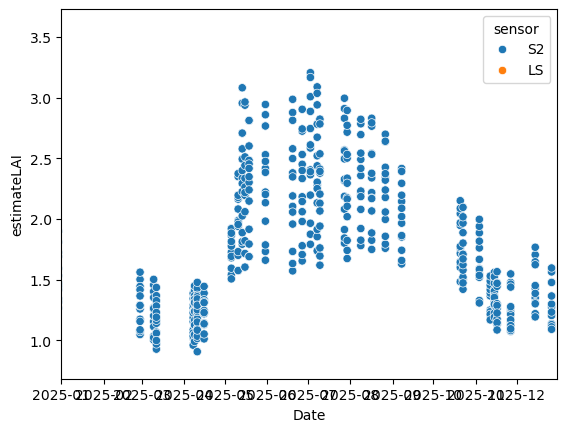

In [94]:
#visualize product estimates for an esu
df = df_groundedeohls_SL2P
plot_names = df['Plot'].unique()
start_date = datetime.datetime(2025, 1, 1)
end_date = datetime.datetime(2025, 12, 31)

ax=sns.scatterplot(df.loc[df['Plot']==plot_names[10]],x='Date',y='estimateLAI',hue='sensor')
ax.set_xlim(start_date,end_date)
# ax.set_ylim(0.8,1.2)

# Make synthetic reference value for each unique date at each ESU

In [ ]:
# extract median 

In [612]:
#Make a unique date and plot column and a unique year and plot column to avoid nested groupby filtering later
# plot_list = pd.DataFrame(df_groundedeohlss30_SL2P_noflags_ndvi['Plot'].unique(),columns=['Plot'])
# plot_list['unique_value_date'] = np.arange(1,len(plot_list)+1) * 1e13 
# plot_list['unique_value_year'] = np.arange(1,len(plot_list)+1) * 10000
# df= df_groundedeohlss30_SL2P_noflags_ndvi.merge(plot_list,on='Plot',how='left')
# df['unique_value_date']=df['unique_value_date']+ df['date']
# df['unique_value_year']=df['unique_value_year']+ df['year']


In [609]:
#Filter each date by dropping the 0.1 and 0.9 quantiles
# df_groundedeohlss30_SL2P_noflags_ndvi_q10 = df.groupby('unique_value_date').apply(lambda group: tools.filter_quantile(group,'estimateLAI',0.1,0.9),include_groups=False).reset_index()

In [ ]:
#fit a gpr estimator for each group of unique plot/year combinatoon
# df_groundedeohlss30_SL2P_noflags_ndvi_q10_gpr = df.groupby('unique_value_year').apply(lambda group: tools.gpr_fit(group

In [634]:
df = tools.apply_quantile_filter_toplots(df_groundedeohlss30_SL2P_noflags_ndvi,'date','estimateLAI',0.1,0.9)


BLAN_048
BLAN_052
GUAN_055
HARV_041
JERC_019
JERC_029
JERC_054
JERC_060
OSBS_030
SCBI_049
UKFS_051
BLAN_034
LAJA_054
LAJA_065
SERC_019
SERC_054
BLAN_009
BLAN_017
GUAN_001
GUAN_002
GUAN_003
GUAN_004
GUAN_005
GUAN_006
GUAN_007
GUAN_008
GUAN_009
GUAN_010
GUAN_011
GUAN_012
GUAN_013
GUAN_015
GUAN_016
GUAN_017
GUAN_018
GUAN_019
GUAN_052
GUAN_054
OSBS_038
SCBI_003
SCBI_007
SCBI_011
SCBI_062
SCBI_063
SERC_002
SERC_004
SERC_009
SERC_013
SERC_022
SERC_061
SERC_062
DE-HoH_CP01
DE-HoH_CP02
DE-HoH_CP03
DE-HoH_CP04
DE-HoH_CP05
FR-Fon_CP01
FR-Fon_CP02
FR-Fon_CP03
FR-Fon_CP04
FR-Fon_SP01
FR-Fon_SP02
FR-Fon_SP03
FR-Fon_SP04
FR-Fon_SP05
FR-Fon_SP06
FR-Fon_SP07
FR-Fon_SP08
FR-Fon_SP09
FR-Fon_SP10
FR-Fon_SP11
FR-Fon_SP12
FR-Fon_SP13
FR-Fon_SP14
FR-Fon_SP15
FR-Fon_SP16
FR-Fon_SP18
FR-Fon_SP19
FR-Fon_SP20
Boyagin_Core
FR-Bil_CP01
FR-Bil_CP02
FR-Bil_CP03
FR-Bil_SP01
FR-Bil_SP02
FR-Bil_SP03
FR-Bil_SP04
FR-Bil_SP05
FR-Bil_SP06
FR-Bil_SP07
FR-Bil_SP08
FR-Bil_SP09
FR-Bil_SP10
FR-Bil_SP11
FR-Bil_SP12
FR-Bil_SP13


In [621]:

df_plot = df.loc[df['Plot']=='HARV_001']
df_plot_filtered  = df_groundedeohlss30_SL2P_noflags_ndvi.loc[df_groundedeohlss30_SL2P_noflags_ndvi['Plot']=='HARV_001']
ax=sns.scatterplot(df_plot,x='date',y='estimateLAI')
sns.scatterplot(filtered_df,x='date',y='estimateLAI')
# ax.set_xlim(1.550e12,1.575e12)

ValueError: Could not interpret value `date` for `x`. An entry with this name does not appear in `data`.

In [267]:
df2=pd.concat([S2inputs.reset_index(),df.reset_index()],axis=1,ignore_index=True)

In [268]:
df2.shape

(700007, 15)

In [76]:
# df_groundedeohlss30 = tools.readCSV('D:\CEOS\InputData\groundedeohlss30')

D:\CEOS\InputData\groundedeohlss30\groundedEOHLSS302015yr0.csv
D:\CEOS\InputData\groundedeohlss30\groundedEOHLSS302015yr1.csv
D:\CEOS\InputData\groundedeohlss30\groundedEOHLSS302016yr0.csv
D:\CEOS\InputData\groundedeohlss30\groundedEOHLSS302016yr1.csv
D:\CEOS\InputData\groundedeohlss30\groundedEOHLSS302017yr0.csv
D:\CEOS\InputData\groundedeohlss30\groundedEOHLSS302017yr1.csv
D:\CEOS\InputData\groundedeohlss30\groundedEOHLSS302018yr0.csv
D:\CEOS\InputData\groundedeohlss30\groundedEOHLSS302018yr1.csv
D:\CEOS\InputData\groundedeohlss30\groundedEOHLSS302019yr0.csv
D:\CEOS\InputData\groundedeohlss30\groundedEOHLSS302019yr1.csv
D:\CEOS\InputData\groundedeohlss30\groundedEOHLSS302020yr0.csv
D:\CEOS\InputData\groundedeohlss30\groundedEOHLSS302020yr1.csv
D:\CEOS\InputData\groundedeohlss30\groundedEOHLSS302021yr0.csv
D:\CEOS\InputData\groundedeohlss30\groundedEOHLSS302021yr1.csv
D:\CEOS\InputData\groundedeohlss30\groundedEOHLSS302022yr0.csv
D:\CEOS\InputData\groundedeohlss30\groundedEOHLSS302022

In [223]:
df_groundedeohlss30 = tools.expand_Fmask(df_groundedeohlss30)

In [224]:
df_groundedeohlss30_noflags = tools.filter_clearsky(df_groundedeohlss30,'noflags',['Plot','date'])

In [232]:
df_groundedeohlss30_noflags = df3

In [106]:
imageCollectionName="HLSL30"           # 'S2_L2A', 'S2_L2A_10m', 'LC08_T1L2', 'LC09_T1L2', 'HLSL30']
S2inputs = df_groundedeohlss30
S2inputs['RAA'] =  np.abs(S2inputs['SAA']-S2inputs['VAA'])
S2inputs[['cosSZA','cosVZA','cosRAA']] = np.cos(np.radians(S2inputs[['SZA','VZA','RAA']]))
S2inputs = S2inputs[['B3','B4','B8A','B11','B12','cosSZA','cosVZA','cosRAA']].rename(columns={'B8A':'B5','B11':'B6','B12':'B7'})

S2outputs= S2inputs.merge(Algos.SL2PINRA(S2inputs,'fAPAR','HLSL30'),left_index=True, right_index=True) \
                    .merge(Algos.SL2PINRA(S2inputs,'fCOVER','HLSL30').drop(['networkID','QC_input','QC_output'],axis=1),left_index=True, right_index=True) \
                    .merge(Algos.SL2PINRA(S2inputs,'LAI','HLSL30').drop(['networkID','QC_input','QC_output'],axis=1),left_index=True, right_index=True)\
                    .merge(Algos.SL2PINRA(S2inputs,'Albedo','HLSL30').drop(['networkID','QC_input','QC_output'],axis=1),left_index=True, right_index=True)\
                    .merge(Algos.SL2PINRA(S2inputs,'CWC','HLSL30').drop(['networkID','QC_input','QC_output'],axis=1),left_index=True, right_index=True)\
                    .merge(Algos.SL2PINRA(S2inputs,'CCC','HLSL30').drop(['networkID','QC_input','QC_output'],axis=1),left_index=True, right_index=True)

Estimating fAPAR from HLSL30 data using SL2P-V0 [Marie Weiss]
Run SL2P...
SL2P start: 2026-02-18 16:24:05.668324
SL2P end: 2026-02-18 16:24:05.702190
Generating sl2p input data flag
Generating sl2p output product flag
Done
Estimating fCOVER from HLSL30 data using SL2P-V0 [Marie Weiss]
Run SL2P...
SL2P start: 2026-02-18 16:24:05.740855
SL2P end: 2026-02-18 16:24:05.771812
Generating sl2p input data flag
Generating sl2p output product flag
Done
Estimating LAI from HLSL30 data using SL2P-V0 [Marie Weiss]
Run SL2P...
SL2P start: 2026-02-18 16:24:05.816281
SL2P end: 2026-02-18 16:24:05.845799
Generating sl2p input data flag
Generating sl2p output product flag
Done
Estimating Albedo from HLSL30 data using SL2P-V0 [Marie Weiss]
Run SL2P...
SL2P start: 2026-02-18 16:24:05.888260
SL2P end: 2026-02-18 16:24:05.917005
Generating sl2p input data flag
Generating sl2p output product flag
Done
Estimating CWC from HLSL30 data using SL2P-V0 [Marie Weiss]
Run SL2P...
SL2P start: 2026-02-18 16:24:05.9603

In [104]:
print(list(S2inputs))

['B3', 'B4', 'B5', 'B6', 'B7', 'cosSZA', 'cosVZA', 'cosRAA']


In [108]:
S2outputs.iloc[0]

B3                 0.010700
B4                 0.014000
B5                 0.133000
B6                 0.079300
B7                 0.046600
cosSZA             0.366339
cosVZA             0.997708
cosRAA            -0.732780
estimatefAPAR      0.332532
networkID          0.000000
errorfAPAR         0.034408
QC_input           0.000000
QC_output          0.000000
estimatefCOVER     0.341348
errorfCOVER        0.056983
estimateLAI        1.466141
errorLAI           0.569527
estimateAlbedo     0.112481
errorAlbedo        0.010829
estimateCWC        0.056843
errorCWC           0.016784
estimateCCC       90.924472
errorCCC          42.488794
Name: 0, dtype: float64

In [87]:
S2inputs['Plot'].unique()

array(['BART_034', 'BART_041'], dtype=object)

In [ ]:
S2inputs = readCSV('D:\CEOS\InputData\hlss30')
# S2inputs = S2inputs.rename(columns={'B1':'B01','B2':'B02','B3':'B03', 'B4':'B04', 'B5':'B05', 'B6':'B06', 'B7':'B07','B8':'B08','B9':'B09'})
# S2inputs['Date']= pd.to_datetime(S2inputs['date'],unit='ms')
# S2inputs[['cosSZA','cosVZA','cosRAA','B01','B02','B03','B04','B05','B06','B07','B08','B8A','B09','B11','B12']]=  0.0001 * S2inputs[['cosSZA','cosVZA','cosRAA','B01','B02','B03','B04','B05','B06','B07','B08','B8A','B09','B11','B12']]


# S2GEOoutputs = S2inputs.merge(SL2P(S2inputs,'fAPAR','S2_L2A',sl2p_inputs_bands),left_index=True, right_index=True) \
#                     .merge(SL2P(S2inputs,'fCOVER','S2_L2A',sl2p_inputs_bands).drop(['networkID','QC_input','QC_output'],axis=1),left_index=True, right_index=True) \
#                     .merge(SL2P(S2inputs,'LAI','S2_L2A',sl2p_inputs_bands).drop(['networkID','QC_input','QC_output'],axis=1),left_index=True, right_index=True)\
#                     .merge(SL2P(S2inputs,'Albedo','S2_L2A',sl2p_inputs_bands).drop(['networkID','QC_input','QC_output'],axis=1),left_index=True, right_index=True)\
#                     .merge(SL2P(S2inputs,'CWC','S2_L2A',sl2p_inputs_bands).drop(['networkID','QC_input','QC_output'],axis=1),left_index=True, right_index=True)\
#                     .merge(SL2P(S2inputs,'CCC','S2_L2A',sl2p_inputs_bands).drop(['networkID','QC_input','QC_output'],axis=1),left_index=True, right_index=True)

In [13]:
df_groundedeohls = pd.concat([df_groundedeohlss30],axis=0,ignore_index=True)
# dfHLS['clear'] = dfHLS['Fmask'].apply(check_clear_condition)
# dfHLS['NDVI']  =(dfHLS['B8A']-dfHLS['B4'])/(dfHLS['B8A']+dfHLS['B4']+0.000001)
# 1. Convert epoch to datetime (assuming 's' for seconds, use 'ms' for milliseconds)
df_groundedeohls['datetime'] = pd.to_datetime(df_groundedeohls['date'], unit='ms')

# 2. Extract Year
df_groundedeohls['year'] = df_groundedeohls['datetime'].dt.year

# 3. Extract Day of Year (1-366)
df_groundedeohls['dayofyear'] = df_groundedeohls['datetime'].dt.dayofyear

df_groundedeohls['day'] = np.round(df_groundedeohls['date']/(86400*1000))

In [222]:
print(list(dfHS2))

['system:index', 'AOT', 'B1', 'B11', 'B12', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B9', 'MSK_CLASSI_CIRRUS', 'MSK_CLASSI_OPAQUE', 'MSK_CLASSI_SNOW_ICE', 'MSK_CLDPRB', 'MSK_SNWPRB', 'Map', 'Plot', 'QA10', 'QA20', 'QA60', 'SCL', 'TCI_B', 'TCI_G', 'TCI_R', 'WVP', 'class', 'date', 'latitude', 'longitude', 'probability', '.geo', 'source_file']


In [74]:

dfHLSS30['sensor'] = 'HLSS30'
print(list(dfHLSS30))

['system:index', 'B1', 'B10', 'B11', 'B12', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B9', 'Fmask', 'Map', 'Plot', 'SAA', 'SZA', 'VAA', 'VZA', 'class', 'date', 'latitude', 'longitude', '.geo', 'source_file', 'sensor']


In [78]:
dfHLSL30 = readCSV('D:\CEOS\InputData\hlsl30').rename(columns={'B10':'T10','B11':'T11','B5':'B8A','B6':'B11','B7':'B12','B9':'B10'})

D:\CEOS\InputData\hlsl30\groundedeohlsl302013yr0.csv
D:\CEOS\InputData\hlsl30\groundedeohlsl302014yr0.csv
D:\CEOS\InputData\hlsl30\groundedeohlsl302015yr0.csv
D:\CEOS\InputData\hlsl30\groundedeohlsl302016yr0.csv
D:\CEOS\InputData\hlsl30\groundedeohlsl302017yr0.csv
D:\CEOS\InputData\hlsl30\groundedeohlsl302018yr0.csv
D:\CEOS\InputData\hlsl30\groundedeohlsl302019yr0.csv
D:\CEOS\InputData\hlsl30\groundedeohlsl302020yr0.csv
D:\CEOS\InputData\hlsl30\groundedeohlsl302021yr0.csv
D:\CEOS\InputData\hlsl30\groundedeohlsl302022yr0.csv
D:\CEOS\InputData\hlsl30\groundedeohlsl302023yr0.csv
D:\CEOS\InputData\hlsl30\groundedeohlsl302024yr0.csv
D:\CEOS\InputData\hlsl30\groundedeohlsl302025yr0.csv


In [80]:
dfHLSL30['sensor'] = 'HLSL30'
print(list(dfHLSL30))

['system:index', 'B1', 'T10', 'T11', 'B2', 'B3', 'B4', 'B8A', 'B11', 'B12', 'B10', 'Fmask', 'Map', 'Plot', 'SAA', 'SZA', 'VAA', 'VZA', 'class', 'date', 'latitude', 'longitude', '.geo', 'source_file', 'sensor']


In [100]:
def check_clear_condition(Fmask):
    # Mask for bits 0 through 5 (binary 111111)
    mask = 0b111111  # This equals 63
    
    # Apply mask and check if any of those bits are set to 1
    # Returns True only if bits 0-5 are all 0
    return (Fmask & mask) == 0

In [185]:
dfHLS = pd.concat([dfHLSS30,dfHLSL30],axis=0,ignore_index=True)
dfHLS['clear'] = dfHLS['Fmask'].apply(check_clear_condition)
dfHLS['NDVI']  =(dfHLS['B8A']-dfHLS['B4'])/(dfHLS['B8A']+dfHLS['B4']+0.000001)
# 1. Convert epoch to datetime (assuming 's' for seconds, use 'ms' for milliseconds)
dfHLS['datetime'] = pd.to_datetime(dfHLS['date'], unit='ms')

# 2. Extract Year
dfHLS['year'] = dfHLS['datetime'].dt.year

# 3. Extract Day of Year (1-366)
dfHLS['dayofyear'] = dfHLS['datetime'].dt.dayofyear

dfHLS['day'] = np.round(dfHLS['date']/(86400*1000))



(1650000000000.0, 1750000000000.0)

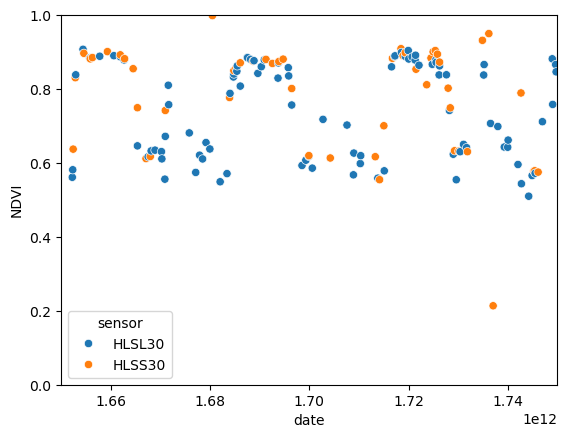

In [120]:
sns.scatterplot(dftest.groupby('date', as_index=False).agg({'NDVI':'mean','sensor':'first'}),x='date',y='NDVI',hue='sensor')
plt.ylim([0,1])
plt.xlim([1.65e12,1.75e12])

In [121]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel
from sklearn.model_selection import GridSearchCV
from sklearn.datasets import make_regression
import warnings

In [201]:
dfHLS['Plot'].unique().shape

(1535,)

In [213]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel

def fitGPR(plot,startDOY,endDOY,minKernal) :
    dftest = dfHLS[(dfHLS['Plot']==plot) & (dfHLS['clear']==True)]
    df = dftest.groupby('day', as_index=False).agg({'NDVI':'mean','dayofyear':'first','year':'first','sensor':'first'})[['dayofyear','year','NDVI']]
    df = df.loc[(df['year']==2025) & (df['dayofyear']>startDOY) & (df['dayofyear']<endDOY)]
    X= df['dayofyear'].to_numpy().reshape(-1, 1)
    y = df['NDVI'].to_numpy().reshape(-1, 1)
    X_train = X
    y_train = y
    
    kernel = 1.0 * RBF(length_scale=minKernal, length_scale_bounds=(minKernal, 1000)) + WhiteKernel(
        noise_level=0.011, noise_level_bounds=(1e-10, 1e-3)
    )
    gpr = GaussianProcessRegressor(kernel=kernel, alpha=0.0)
    gpr.fit(X_train, y_train)
    y_mean, y_std = gpr.predict(X, return_std=True)
    
    plt.plot(X, y, label="Expected signal")
    plt.scatter(x=X_train[:, 0], y=y_train, color="black", alpha=0.4, label="Observations")
    plt.errorbar(X, y_mean, y_std, label="Posterior mean ± std")
    plt.legend()
    plt.xlabel("X")
    plt.ylabel("y")
    _ = plt.title(
        (
            f"{plot}"
            f"Initial: {kernel}\nOptimum: {gpr.kernel_}\nLog-Marginal-Likelihood: "
            f"{gpr.log_marginal_likelihood(gpr.kernel_.theta)}"
        ),
        fontsize=8,
    )
    return


In [220]:
dfHLS.loc[dfHLS['class']=='grasslandHerbaceous']

,system:index,B1,B10,B11,B12,B2,B3,B4,B5,B6,...,source_file,sensor,T10,T11,clear,NDVI,datetime,year,dayofyear,day
515,00000000000000000b2f_00000000000000000b2f_T13T...,0.6918,0.0231,0.1092,0.1032,0.7188,0.7448,0.7540,0.7723,0.7736,...,groundedeohlss302015yr0.csv,HLSS30,NaN,NaN,False,0.001391,2015-12-29 17:57:42,2015,363,16799.0
516,00000000000000000b2f_00000000000000000b2f_T13T...,0.7078,0.0231,0.1047,0.1020,0.7361,0.7578,0.7711,0.8034,0.7903,...,groundedeohlss302015yr0.csv,HLSS30,NaN,NaN,False,0.000000,2015-12-29 17:57:42,2015,363,16799.0
517,00000000000000000b2f_00000000000000000b2f_T13T...,0.7078,0.0231,0.1031,0.1013,0.7612,0.7769,0.7800,0.7916,0.7908,...,groundedeohlss302015yr0.csv,HLSS30,NaN,NaN,False,-0.005608,2015-12-29 17:57:42,2015,363,16799.0
518,00000000000000000b2f_00000000000000000b2f_T13T...,0.6515,0.0245,0.1143,0.1076,0.6263,0.6353,0.6412,0.6558,0.6603,...,groundedeohlss302015yr0.csv,HLSS30,NaN,NaN,False,0.009806,2015-12-29 17:57:42,2015,363,16799.0
519,00000000000000000b2f_00000000000000000b2f_T13T...,0.6479,0.0235,0.1212,0.1141,0.7494,0.7677,0.7861,0.7780,0.7778,...,groundedeohlss302015yr0.csv,HLSS30,NaN,NaN,False,-0.017539,2015-12-29 17:57:42,2015,363,16799.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16137821,00000000000000002a5c_00000000000000002a5c_T11S...,0.0282,0.0016,0.2091,0.1138,0.0326,0.0751,0.0557,NaN,NaN,...,groundedeohlsl302025yr0.csv,HLSL30,14.03,13.36,True,0.658070,2025-11-21 18:34:01,2025,325,20414.0
16137822,00000000000000002a5c_00000000000000002a5c_T11S...,0.0282,0.0016,0.2091,0.1138,0.0326,0.0751,0.0557,NaN,NaN,...,groundedeohlsl302025yr0.csv,HLSL30,14.03,13.36,True,0.658070,2025-11-21 18:34:01,2025,325,20414.0
16137823,00000000000000002a5c_00000000000000002a5c_T11S...,0.0270,0.0017,0.1853,0.0978,0.0286,0.0683,0.0429,NaN,NaN,...,groundedeohlsl302025yr0.csv,HLSL30,13.90,13.09,True,0.725876,2025-11-21 18:34:01,2025,325,20414.0
16137824,00000000000000002a5c_00000000000000002a5c_T11S...,0.0295,0.0013,0.2165,0.1196,0.0350,0.0783,0.0548,NaN,NaN,...,groundedeohlsl302025yr0.csv,HLSL30,13.86,13.17,True,0.674679,2025-11-21 18:34:01,2025,325,20414.0


C:\Users\rfernand\AppData\Local\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 15. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\rfernand\AppData\Local\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified upper bound 0.001. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


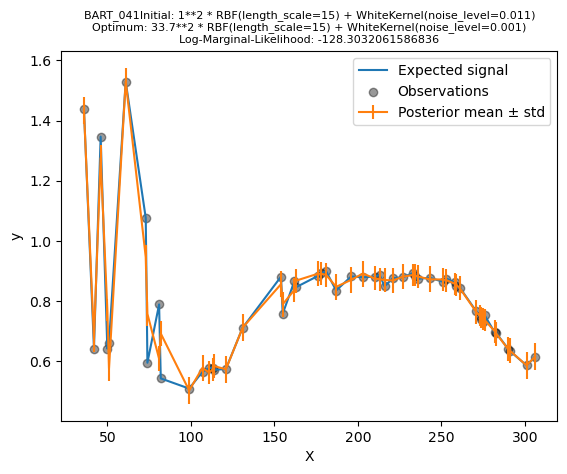

In [223]:
fitGPR('BART_041',30,330,15)

In [218]:
print(dfHLS['class'].unique())

['mixedForest' 'deciduousForest' 'shrubScrub' 'evergreenForest'
 'woodyWetlands' 'cultivatedCrops' 'grasslandHerbaceous' 'pastureHay'
 'emergentHerbaceousWetlands' 'sedgeHerbaceous' 'dwarfScrub']
